# ACT-R Cognitive Architecture for Sarcasm Detection
## Integrating Giora's Irony-as-Indirect-Negation with Conversational Context

**Group:** G107 | **Course:** MLP Semester 2, Coursework 3

---

### Theoretical Foundation

This notebook implements a **cognitively-grounded** approach to sarcasm detection that bridges cognitive science and deep learning:

- **Giora (1995)** *"On irony and negation"* — Irony functions as **indirect negation**; both literal and intended meanings remain active simultaneously. The sarcastic utterance "What a lovely party" indirectly negates the positive meaning: *"how far it is from being the expected lovely party"* (Giora, 1995, p.244). This insight forms the core of our ACT-R knowledge base.

- **Anderson & Lebiere (1998); Ritter et al. (2019)** — ACT-R cognitive architecture provides the computational framework: declarative memory with base-level activation ($B_i = \ln \sum_j t_j^{-d}$), spreading activation ($S_{ji} = S - \ln(\text{fan}_j)$), and logistic noise ($\varepsilon \sim \text{Logistic}(0, s)$). These subsymbolic equations govern how the simulator processes each input.

- **Wu et al. (2025)** — Demonstrated that integrating ACT-R cognitive vectors with large language models improves performance on domain-specific tasks.

### Approach: Per-Sample ACT-R Feature Extraction

We run the ACT-R simulator on **each individual sample** to extract input-dependent cognitive features. This is cognitively principled — ACT-R processes each input through its own cognitive cycle (Ritter et al., 2019), producing different production-rule firings, memory retrievals, and incongruity assessments for each parent-comment pair.

### Three-Model Progressive Comparison

We test three models to isolate ACT-R's contribution:

| Model | Architecture | ACT-R Features | Purpose |
|-------|-------------|----------------|---------|
| **Baseline BERT** | BERT + Linear(768, 2) | None | Strong neural control (Devlin et al., 2019) |
| **CognitiveBERT** | BERT + ACT-R gating + Linear(778, 2) | Base ACT-R (10-dim) | Does cognitive processing help at all? |
| **Enhanced CognitiveBERT** | BERT + soft retrieval + bias correction + Linear(778, 2) | Enhanced ACT-R (10-dim) | Does richer cognition help more? |

### Dataset and Experimental Setup

- **Dataset**: Reddit SARC (Khodak et al., 2018) — `MAX_SAMPLES = 100,000` balanced samples
- **Split**: 70/15/15 stratified (train/val/test) — 70K train, 15K val, 15K test
- **Epochs**: 5 with best-model checkpointing
- **Fair comparison**: Same seed, same optimiser, same LR — only the cognitive features differ
- **Statistical test**: McNemar's test for significance (p < 0.05)

## 1. Setup and Configuration

We install and import all required libraries, then configure hyperparameters following the fair comparison protocol.

**Reproducibility**: Following Devlin et al. (2019), we set all random seeds (Python, NumPy, PyTorch, CUDA) to ensure deterministic behaviour. The seed is reset before each model training to guarantee identical data ordering.

**Key Hyperparameters**:
- `MAX_SAMPLES = 100000` — 100K balanced samples from SARC. Increased from initial 10K to reduce overfitting (previous run showed 97% train vs 68% test accuracy with 10K).
- `MAX_SEQ_LENGTH = 256` — Increased from 128 to accommodate dialogue pairs (`parent_comment [SEP] comment`). Reddit comments average 25.3 words (Khodak et al., 2018), and parent+child pairs may exceed 128 tokens.
- `ACTR_FEATURE_DIM = 10` — Per-sample cognitive features extracted from the ACT-R simulator's imaginal buffer.
- `NUM_EPOCHS = 5` — Sufficient for BERT fine-tuning convergence on 70,000 training samples.
- `LEARNING_RATE = 2e-5` — Standard for BERT fine-tuning (Devlin et al., 2019).
- `NOISE_S = 0.25`, `DECAY_RATE = 0.5` — ACT-R subsymbolic parameters from Anderson & Lebiere (1998).
- `TARGET_LAYER = 6` — Middle BERT layer; retained from static approach for backward compatibility.
- `MULTIPLIER = 5.0` — Legacy parameter from static approach; not used in per-sample architecture.

In [ ]:
!pip install sentence-transformers matplotlib seaborn scikit-learn scipy transformers pandas tqdm vaderSentiment -q


In [2]:
import os
import re
import random
import math
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import BertModel, BertTokenizer, BertConfig
from transformers import get_linear_schedule_with_warmup
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, confusion_matrix
)
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ---- Reproducibility (matching BERT_ACTR_Clean protocol) ----
SEED = 42

def set_seed(seed):
    """Set all random seeds for reproducibility.
    Must be called before EACH model training for fair comparison."""
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

# ---- Device ----
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'CUDA version: {torch.version.cuda}')

# ---- Model / Training Hyperparameters ----
MAX_SEQ_LENGTH = 256        # Increased for dialogue pairs (parent + response)
BATCH_SIZE = 16
NUM_EPOCHS = 5              # 5 epochs for convergence
LEARNING_RATE = 2e-5        # Single LR for all params (match BERT_ACTR_Clean)
DROPOUT_RATE = 0.3
NUM_LABELS = 2
MAX_SAMPLES = 100000         # 100K balanced samples from SARC

# ---- ACT-R Parameters (Ritter et al., 2019; Anderson & Lebiere, 1998) ----
NOISE_S = 0.25          # logistic noise scale s
DECAY_RATE = 0.5        # base-level learning decay d
RETRIEVAL_THRESHOLD = 0.0
UTILITY_NOISE = 0.5     # production utility noise
CYCLE_TIME = 0.05       # 50ms per production cycle (Ritter et al., 2019)

# ---- Cognitive Vector Parameters ----
PCA_COMPONENTS = 5
TARGET_LAYER = 6
MULTIPLIER = 5.0
ACTR_FEATURE_DIM = 10       # Per-sample cognitive features from ACT-R simulator
ACTR_PROJ_DIM = 256         # ACT-R projection width (10 -> 256 for balanced capacity)

print('Configuration loaded.')
print(f'Random seed: {SEED}')
print(f'Max sequence length: {MAX_SEQ_LENGTH}')
print(f'Epochs: {NUM_EPOCHS}, Batch size: {BATCH_SIZE}, LR: {LEARNING_RATE}')

# ---- CognitiveBERT v2 Parameters ----
ACTR_V2_DIM = 20            # v2 feature vector dimension (4 groups)
V2_FUSION_LAYER = 8         # Inject ACT-R at BERT layer 8 (before layers 9-12)
V2_GAMMA_LR = 1e-3          # Learning rate for fusion scaling parameter
V2_PROJ_LR_MULT = 10        # LR multiplier for new projection/cross-attention params
V2_LOWER_LR_MULT = 0.1      # LR multiplier for BERT layers 0-7


Using device: cuda
GPU: NVIDIA GeForce RTX 4090
CUDA version: 12.4
Configuration loaded.
Random seed: 42
Max sequence length: 256
Epochs: 5, Batch size: 16, LR: 2e-05


## 2. Irony-Negation Knowledge Base

This knowledge base implements Giora's (1995) key insight: **irony is indirect negation**. Unlike explicit negation ("not good"), sarcasm negates meaning indirectly by using positive words in contradictory contexts.

> *"The product of ironic processing is closer to: 'how far it is from being the expected lovely party.' The surface meaning remains active and contributes to the final interpretation."* — Giora (1995, p.244)

The knowledge base captures three core phenomena:

1. **Sentiment polarity words** — Words whose valence can flip when used sarcastically. Giora's "indirect negation" means "great" in a negative context implicitly communicates "not great" without using the word "not".

2. **Negation modifiers** — Words like "not", "never" that interact with irony to create **double negation** effects. Giora (1995) showed that negation + irony does not cancel out — it creates a distinct pragmatic meaning.

3. **Sarcasm markers** — Lexical cues ("obviously", "totally", "clearly") that signal non-literal intent (Attardo, 2000). These intensifiers often accompany indirect negation.

### Role in Per-Sample Feature Extraction

This knowledge base is not just for trace generation — it is the **core resource** that the ACT-R simulator uses when processing each individual sample. When `extract_actr_features()` runs on a parent-comment pair, the simulator:
1. Retrieves sentiment words from declarative memory using this knowledge base
2. Counts positive/negative words, negation markers, and sarcasm cues
3. Detects incongruity between parent and comment sentiment
4. Stores all results in the `imaginal` buffer — which we extract as the 10-dim feature vector

The features directly encode Giora's theoretical constructs: sentiment polarity counts capture the "indirect negation" signal, while marker counts capture explicit sarcasm cues.

### Why ACT-R, Not Simple Word Counting?

A natural question is whether the improvement (if any) comes from the **lexical resources** (word lists) rather than the **ACT-R architecture** itself. The distinction is important:

| Component | Simple Word Counting | ACT-R Cognitive Processing |
|-----------|---------------------|---------------------------|
| Sentiment detection | Count positive/negative words independently | Retrieve words via activation equations ($A_i = B_i + \sum W_j S_{ji} + \varepsilon$) with context-dependent spreading activation |
| Incongruity detection | Not possible — separate counts cannot detect contradiction | Production rule `detect_sarcasm` **compares** parent vs comment sentiment, implementing Giora's indirect negation |
| Memory access | Deterministic lookup | Stochastic retrieval with logistic noise ($\varepsilon \sim \text{Logistic}(0, s)$), modelling human processing variability (Anderson & Lebiere, 1998) |
| Bias correction | Not applicable | Enhanced simulator's metacognitive phase asks "am I being biased?" (Tversky & Kahneman, 1974) |
| Theoretical grounding | Ad hoc feature engineering | Principled cognitive cycle: goal → retrieval → imaginal → production (Ritter et al., 2019) |

The critical feature is **`has_incongruity`** — this is 1 when parent and comment sentiments **contradict**, and 0 otherwise. A simple word counter gives separate counts per text; only the ACT-R production rules **combine** them into a contradiction detection. This implements Giora's (1995) core claim that sarcasm arises from the *relationship* between surface meaning and context, not from individual words alone.

Furthermore, the Enhanced simulator adds **soft retrieval probability** and **bias correction** — these are purely ACT-R cognitive mechanisms with no lexical equivalent. If the Enhanced model outperforms the base CognitiveBERT, it demonstrates that richer *cognitive processing* (not just richer word lists) contributes to sarcasm detection.

In [ ]:
# =============================================================================
# IRONY-NEGATION KNOWLEDGE BASE
# Based on Giora (1995), Riloff et al. (2013), Attardo (2000)
# Expanded with VADER sentiment lexicon (Hutto & Gilbert, 2014)
# =============================================================================

# --- Sentiment lexicon: VADER-expanded (reduces zero-feature rate from 41% to 12%) ---
# Original hand-crafted KB had 68 words (35 pos + 33 neg), covering 0.34% of BERT vocab.
# VADER provides ~7,500 scored words validated on social media text.
# We use VADER words with |score| > 0.5 for clear sentiment signal.
# Filter to alphabetic words only (matching \w+ tokenization in simulator).
try:
    from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
    _vader = SentimentIntensityAnalyzer()
    POSITIVE_WORDS = {w for w, s in _vader.lexicon.items()
                      if s > 0.5 and w.isalpha()}
    NEGATIVE_WORDS = {w for w, s in _vader.lexicon.items()
                      if s < -0.5 and w.isalpha()}
    _KB_SOURCE = 'VADER'
except ImportError:
    # Fallback: original hand-crafted KB if VADER not installed
    POSITIVE_WORDS = {
        'love', 'great', 'wonderful', 'amazing', 'awesome', 'fantastic', 'excellent',
        'perfect', 'beautiful', 'best', 'happy', 'joy', 'brilliant', 'superb',
        'lovely', 'nice', 'good', 'better', 'favorite', 'incredible', 'delightful',
        'pleased', 'glad', 'thrilled', 'excited', 'terrific', 'fabulous', 'enjoy',
        'thanks', 'thank', 'helpful', 'fun', 'cool', 'fine', 'well'
    }
    NEGATIVE_WORDS = {
        'hate', 'terrible', 'awful', 'horrible', 'bad', 'worst', 'disgusting',
        'disappointing', 'sad', 'angry', 'annoyed', 'frustrated', 'boring',
        'stupid', 'ugly', 'poor', 'fail', 'wrong', 'problem', 'pain', 'hard',
        'difficult', 'nothing', 'waste', 'useless', 'pathetic', 'miserable',
        'broken', 'ruined', 'disaster', 'tragic', 'dreadful', 'lousy'
    }
    _KB_SOURCE = 'hand-crafted'

# Negation modifiers -- Giora (1995) shows these interact differently
# with irony vs literal language.
NEGATION_WORDS = {
    'not', "n't", 'no', 'never', 'neither', 'nor', 'none', 'nobody',
    'nothing', 'nowhere', 'hardly', 'barely', 'scarcely', 'without'
}

# Sarcasm markers -- intensifiers and discourse markers that signal
# potential non-literal intent (Attardo, 2000: "relevant inappropriateness")
SARCASM_MARKERS = {
    'oh', 'wow', 'really', 'totally', 'absolutely', 'definitely', 'clearly',
    'obviously', 'sure', 'right', 'yeah', 'yay', 'hooray', 'brilliant',
    'genius', 'shocking', 'surprise', 'another', 'just', 'exactly', 'precisely',
    'certainly', 'surely', 'of course'
}

# Cross-context contradiction patterns (Riloff et al., 2013)
CONTRADICTION_PATTERNS = [
    ('positive', 'negative', 'positive_surface_negative_context'),
    ('negative', 'positive', 'negative_surface_positive_context'),
    ('enthusiastic', 'mundane', 'enthusiastic_tone_mundane_topic'),
    ('agreement', 'disagreement', 'agreement_in_disagreement_context'),
    ('praise', 'complaint', 'praise_in_complaint_context'),
]

# Giora's indirect negation valence flip rules
IRONY_NEGATION_RULES = [
    {
        'name': 'positive_in_negative_context',
        'description': 'Positive words in negative parent = indirect negation (Giora 1995)',
        'comment_valence': 'positive',
        'parent_valence': 'negative',
        'sarcasm_signal': 'strong',
    },
    {
        'name': 'negative_in_positive_context',
        'description': 'Negative words in positive parent = double negation (Giora 1995)',
        'comment_valence': 'negative',
        'parent_valence': 'positive',
        'sarcasm_signal': 'moderate',
    },
    {
        'name': 'negation_with_positive_in_negative_context',
        'description': 'Explicit negation + positive word in negative parent = complex irony',
        'has_negation': True,
        'comment_valence': 'positive',
        'parent_valence': 'negative',
        'sarcasm_signal': 'moderate',
    },
    {
        'name': 'negation_cancels_in_positive_context',
        'description': 'Explicit negation + negative word in positive parent = literal agreement',
        'has_negation': True,
        'comment_valence': 'negative',
        'parent_valence': 'positive',
        'sarcasm_signal': 'weak',
    },
]

print(f'Irony-Negation Knowledge Base (source: {_KB_SOURCE}):')
print(f'  {len(POSITIVE_WORDS)} positive sentiment words')
print(f'  {len(NEGATIVE_WORDS)} negative sentiment words')
print(f'  {len(NEGATION_WORDS)} negation modifiers')
print(f'  {len(SARCASM_MARKERS)} sarcasm markers')
print(f'  {len(CONTRADICTION_PATTERNS)} cross-context contradiction patterns')
print(f'  {len(IRONY_NEGATION_RULES)} irony-negation rules')

## 3. ACT-R Simulator with Irony-Negation Processing

### ACT-R Architecture (Ritter et al., 2019; Anderson & Lebiere, 1998)

The simulator implements the core ACT-R cognitive cycle:

**Buffers** hold the current processing state:
- **Goal buffer**: Current processing stage (literal-encoding → sentiment-retrieval → incongruity-detection → pragmatic-reinterpretation)
- **Imaginal buffer**: Working memory for intermediate computations (sentiment scores, incongruity flags)
- **Retrieval buffer**: Result of the most recent declarative memory retrieval

**Declarative Memory** stores chunks with subsymbolic activation:

$$A_i = B_i + \sum_j W_j \cdot S_{ji} + \varepsilon$$

where:
- $B_i = \ln \sum_j t_j^{-d}$ is **base-level activation** (power-law decay, $d=0.5$) — models how memory strength decays over time (Anderson & Lebiere, 1998)
- $S_{ji} = S - \ln(\text{fan}_j)$ is **spreading activation** — chunks associated with more items have weaker individual associations (the fan effect; Anderson & Reder, 1999)
- $\varepsilon \sim \text{Logistic}(0, s)$ is **activation noise** ($s=0.25$) — models the stochastic nature of human memory retrieval

**Production System** fires rules serially based on utility-based conflict resolution. Higher-utility productions are preferred, with noise added to model variability.

### Multi-Stage Processing (Following Giora, 1995)

The processing pipeline mirrors Giora's model of irony comprehension:

1. **Literal Encoding** — Surface meaning is *always* processed first (Graded Salience Hypothesis). The simulator tokenises both parent and child comments and encodes literal sentiment.
2. **Sentiment Retrieval** — Retrieve valence from declarative memory for BOTH parent and child comments separately.
3. **Cross-Context Incongruity Detection** — Compare parent vs child sentiment. This is the core of indirect negation: a positive child response to a negative parent signals potential sarcasm.
4. **Negation Interaction** — Check if explicit negation words modify the indirect negation pattern.
5. **Pragmatic Reinterpretation** — Compute the "distance" between literal and intended meaning, producing the final sarcasm assessment.

### Code Structure

- `ACTRChunk`: A memory unit with slots, creation time, and access history for base-level activation
- `ACTRBuffer`: Named buffer that holds one chunk at a time
- `DeclarativeMemory`: Full ACT-R DM with `retrieve()` implementing activation-based retrieval
- `ProductionRule`: Condition-action pair with utility for conflict resolution
- `IronyNegationACTR`: Main simulator class orchestrating the multi-stage pipeline


In [4]:
class ACTRChunk:
    """A chunk in ACT-R declarative memory (Ritter et al., 2019).
    
    Chunks are symbolic memory elements with slot-value pairs.
    Subsymbolic activation determines retrieval speed and probability.
    """
    def __init__(self, name, chunk_type, slots, creation_time=0.0):
        self.name = name
        self.chunk_type = chunk_type
        self.slots = dict(slots)
        self.creation_time = creation_time
        self.access_times = [creation_time]
        self.fan = 1  # number of chunks referencing this (for fan effect)

    def __repr__(self):
        slot_str = ' '.join(f'{k}:{v}' for k, v in self.slots.items())
        return f'<{self.chunk_type} {self.name} {slot_str}>'


class ACTRBuffer:
    """ACT-R buffer â€” interface between modules and production system.
    
    From Ritter et al. (2019): Buffers store contents visible to other modules.
    The production system reads/writes buffers each cycle.
    """
    def __init__(self, name):
        self.name = name
        self.chunk = None

    def set_chunk(self, chunk, sim_time):
        self.chunk = chunk
        return f'{sim_time:.3f}s  BUFFER-SET {self.name} <- {chunk}'

    def modify(self, slot, value, sim_time):
        if self.chunk is not None:
            self.chunk.slots[slot] = value
        return f'{sim_time:.3f}s  BUFFER-MODIFY {self.name}.{slot} = {value}'

    def clear(self, sim_time):
        old = self.chunk
        self.chunk = None
        return f'{sim_time:.3f}s  BUFFER-CLEAR {self.name} (was {old})'


class DeclarativeMemory:
    """ACT-R Declarative Memory with subsymbolic activation.
    
    Activation equation (Anderson & Lebiere, 1998):
        A_i = B_i + S_i + noise
    where:
        B_i = ln(sum_j (t_j)^{-d})  -- base-level learning (power-law decay)
        S_i = sum of spreading activation from source slots
        noise ~ Logistic(0, s)
    
    Retrieval succeeds if A_i > threshold (tau).
    Retrieval time: RT = F * exp(-A_i)
    """

    def __init__(self, decay=DECAY_RATE, noise_s=NOISE_S,
                 threshold=RETRIEVAL_THRESHOLD):
        self.chunks = {}
        self.decay = decay
        self.noise_s = noise_s
        self.threshold = threshold

    def add_chunk(self, chunk):
        self.chunks[chunk.name] = chunk

    def _base_level(self, chunk, current_time):
        """B_i = ln(sum_j (t_j)^{-d}) -- power-law decay."""
        total = 0.0
        for t in chunk.access_times:
            age = max(current_time - t, 0.001)
            total += age ** (-self.decay)
        return math.log(max(total, 1e-10))

    def _spreading_activation(self, chunk, source_slots):
        """S_i = sum of match bonuses for overlapping slot values.
        Weighted by 1/fan to model the fan effect (Anderson & Reder, 1999)."""
        bonus = 0.0
        for slot, value in source_slots.items():
            if slot in chunk.slots and chunk.slots[slot] == value:
                bonus += 1.0 / max(chunk.fan, 1)
        return bonus

    def _noise(self):
        """ACT-R logistic noise: s * ln(p / (1-p))."""
        p = random.random()
        p = max(min(p, 0.9999), 0.0001)
        return self.noise_s * math.log(p / (1 - p))

    def activation(self, chunk, current_time, source_slots=None):
        """Total activation: A_i = B_i + S_i + noise."""
        b = self._base_level(chunk, current_time)
        s = self._spreading_activation(chunk, source_slots or {}) if source_slots else 0.0
        n = self._noise()
        return b + s + n

    def retrieve(self, pattern, current_time, source_slots=None):
        """Retrieve best-matching chunk above threshold."""
        traces = []
        candidates = []
        for chunk in self.chunks.values():
            match = True
            for slot, value in pattern.items():
                if slot == 'chunk_type':
                    if chunk.chunk_type != value:
                        match = False; break
                elif chunk.slots.get(slot) != value:
                    match = False; break
            if match:
                act = self.activation(chunk, current_time, source_slots)
                candidates.append((chunk, act))
                traces.append(f'  DM-CANDIDATE {chunk.name} activation={act:.3f}')
        if not candidates:
            traces.append('  DM-RETRIEVAL-FAILURE no matching chunks')
            return None, None, traces
        candidates.sort(key=lambda x: x[1], reverse=True)
        best_chunk, best_act = candidates[0]
        if best_act < self.threshold:
            traces.append(f'  DM-RETRIEVAL-FAILURE best={best_act:.3f} < threshold={self.threshold}')
            return None, None, traces
        best_chunk.access_times.append(current_time)
        traces.append(f'  DM-RETRIEVED {best_chunk.name} activation={best_act:.3f}')
        return best_chunk, best_act, traces


class ProductionRule:
    """ACT-R production rule with utility-based conflict resolution.
    
    From Ritter et al. (2019): Productions are selected based on
    probability of success * goal value - cost + noise.
    """
    def __init__(self, name, condition_fn, action_fn, utility=1.0):
        self.name = name
        self.condition_fn = condition_fn
        self.action_fn = action_fn
        self.utility = utility
        self.fire_count = 0


print('ACT-R core components defined.')

ACT-R core components defined.


In [5]:
class IronyNegationACTR:
    """
    ACT-R Simulator for Sarcasm Detection with Irony-Negation Processing.
    
    Implements Giora's (1995) multi-stage processing model:
    
    Stage 1 - LITERAL ENCODING (Graded Salience):
        Process surface meaning of both parent and child comments.
        Giora: "Literal meaning is always processed first."
    
    Stage 2 - SENTIMENT RETRIEVAL (ACT-R Declarative Memory):
        Retrieve sentiment valence for parent and child separately.
        Uses base-level activation + spreading activation from goal buffer.
    
    Stage 3 - CROSS-CONTEXT INCONGRUITY (Indirect Negation Detection):
        Compare parent vs child sentiment to detect indirect negation.
        Giora: "Irony is indirect negation â€” positive surface + negative context."
        Also checks for negation word interactions (double negation effect).
    
    Stage 4 - PRAGMATIC REINTERPRETATION (Wilson & Sperber, 2012):
        Compute the "distance" between literal and intended meaning.
        Giora: Both meanings remain active (incancellability condition).
    """

    def __init__(self):
        self.dm = DeclarativeMemory()
        self.goal = ACTRBuffer('goal')
        self.imaginal = ACTRBuffer('imaginal')
        self.retrieval = ACTRBuffer('retrieval')
        self.productions = []
        self.time = 0.0
        self.traces = []
        self._init_knowledge_base()
        self._init_productions()

    def _init_knowledge_base(self):
        """Populate declarative memory with irony-negation knowledge."""
        t = 0.0
        for w in POSITIVE_WORDS:
            self.dm.add_chunk(ACTRChunk(
                f'pos-{w}', 'sentiment-word',
                {'word': w, 'valence': 'positive', 'can_negate': 'yes'},
                creation_time=t))
        for w in NEGATIVE_WORDS:
            self.dm.add_chunk(ACTRChunk(
                f'neg-{w}', 'sentiment-word',
                {'word': w, 'valence': 'negative', 'can_negate': 'yes'},
                creation_time=t))
        for w in NEGATION_WORDS:
            self.dm.add_chunk(ACTRChunk(
                f'negmod-{w}', 'negation-modifier',
                {'word': w, 'function': 'negation', 'type': 'explicit'},
                creation_time=t))
        for m in SARCASM_MARKERS:
            self.dm.add_chunk(ACTRChunk(
                f'marker-{m}', 'sarcasm-marker',
                {'word': m, 'type': 'intensifier'},
                creation_time=t))
        for i, (c_sent, p_sent, pname) in enumerate(CONTRADICTION_PATTERNS):
            self.dm.add_chunk(ACTRChunk(
                f'contra-{i}', 'contradiction-pattern',
                {'comment_sentiment': c_sent, 'parent_sentiment': p_sent,
                 'pattern_name': pname, 'indicates': 'sarcasm'},
                creation_time=t))
        for i, rule in enumerate(IRONY_NEGATION_RULES):
            self.dm.add_chunk(ACTRChunk(
                f'irony-rule-{i}', 'irony-negation-rule',
                rule, creation_time=t))
        # General knowledge chunks
        self.dm.add_chunk(ACTRChunk(
            'indirect-negation-def', 'knowledge',
            {'concept': 'indirect_negation',
             'definition': 'irony_negates_without_not',
             'source': 'giora_1995'}, creation_time=t))
        self.dm.add_chunk(ACTRChunk(
            'incancellability-def', 'knowledge',
            {'concept': 'incancellability',
             'definition': 'both_literal_and_ironic_meanings_remain_active',
             'source': 'giora_1995'}, creation_time=t))

    def _init_productions(self):
        """Production rules for irony-negation sarcasm detection pipeline."""
        # Stage 1: Literal encoding
        self.productions.append(ProductionRule(
            'attend-input', self._cond_attend, self._act_attend, utility=10.0))
        self.productions.append(ProductionRule(
            'tokenize-parent', self._cond_tokenize_parent, self._act_tokenize_parent, utility=9.5))
        self.productions.append(ProductionRule(
            'tokenize-comment', self._cond_tokenize_comment, self._act_tokenize_comment, utility=9.0))
        self.productions.append(ProductionRule(
            'encode-literal', self._cond_encode, self._act_encode, utility=8.5))
        # Stage 2: Sentiment retrieval for both contexts
        self.productions.append(ProductionRule(
            'retrieve-parent-sentiment', self._cond_parent_sentiment,
            self._act_parent_sentiment, utility=8.0))
        self.productions.append(ProductionRule(
            'retrieve-comment-sentiment', self._cond_comment_sentiment,
            self._act_comment_sentiment, utility=7.5))
        self.productions.append(ProductionRule(
            'check-negation-words', self._cond_check_negation,
            self._act_check_negation, utility=7.0))
        self.productions.append(ProductionRule(
            'check-sarcasm-markers', self._cond_check_markers,
            self._act_check_markers, utility=6.5))
        # Stage 3: Cross-context incongruity detection
        self.productions.append(ProductionRule(
            'detect-cross-context-incongruity', self._cond_cross_incongruity,
            self._act_cross_incongruity, utility=6.0))
        self.productions.append(ProductionRule(
            'evaluate-negation-interaction', self._cond_negation_interaction,
            self._act_negation_interaction, utility=5.5))
        self.productions.append(ProductionRule(
            'retrieve-irony-rule', self._cond_retrieve_irony_rule,
            self._act_retrieve_irony_rule, utility=5.0))
        # Stage 4: Pragmatic reinterpretation
        self.productions.append(ProductionRule(
            'pragmatic-reinterpret', self._cond_pragmatic,
            self._act_pragmatic, utility=4.0))
        # Final decision
        self.productions.append(ProductionRule(
            'make-decision', self._cond_decision, self._act_decision, utility=1.0))

    def _state(self):
        return {
            'goal': self.goal.chunk,
            'imaginal': self.imaginal.chunk,
            'retrieval': self.retrieval.chunk,
            'stage': (self.goal.chunk.slots.get('stage') if self.goal.chunk else None),
        }

    def _advance(self, dt=CYCLE_TIME):
        self.time += dt

    # ---- Conditions ----
    def _cond_attend(self, s):              return s['stage'] == 'start'
    def _cond_tokenize_parent(self, s):     return s['stage'] == 'attended'
    def _cond_tokenize_comment(self, s):    return s['stage'] == 'parent-tokenized'
    def _cond_encode(self, s):              return s['stage'] == 'comment-tokenized'
    def _cond_parent_sentiment(self, s):    return s['stage'] == 'literal-encoded'
    def _cond_comment_sentiment(self, s):   return s['stage'] == 'parent-sentiment-done'
    def _cond_check_negation(self, s):      return s['stage'] == 'comment-sentiment-done'
    def _cond_check_markers(self, s):       return s['stage'] == 'negation-checked'
    def _cond_cross_incongruity(self, s):   return s['stage'] == 'markers-checked'
    def _cond_negation_interaction(self, s): return s['stage'] == 'incongruity-assessed'
    def _cond_retrieve_irony_rule(self, s): return s['stage'] == 'negation-interaction-done'
    def _cond_pragmatic(self, s):           return s['stage'] == 'irony-rule-retrieved'
    def _cond_decision(self, s):            return s['stage'] in ('reinterpreted', 'incongruity-assessed')

    # ---- Actions ----
    def _act_attend(self, state):
        traces = []
        self._advance()
        traces.append(f'{self.time:.3f}s  PRODUCTION-FIRE attend-input')
        parent = self.goal.chunk.slots.get('parent_text', '')
        comment = self.goal.chunk.slots.get('comment_text', '')
        traces.append(f'{self.time:.3f}s  VISUAL-ATTEND parent="{parent[:50]}"')
        traces.append(f'{self.time:.3f}s  VISUAL-ATTEND comment="{comment[:50]}"')
        traces.append(self.goal.modify('stage', 'attended', self.time))
        return traces

    def _act_tokenize_parent(self, state):
        traces = []
        self._advance()
        traces.append(f'{self.time:.3f}s  PRODUCTION-FIRE tokenize-parent')
        parent = self.goal.chunk.slots.get('parent_text', '')
        parent_words = re.findall(r"\w+|n't", parent.lower())
        self.goal.chunk.slots['parent_words'] = parent_words
        traces.append(f'{self.time:.3f}s  TOKENIZED-PARENT {len(parent_words)} words')
        traces.append(self.goal.modify('stage', 'parent-tokenized', self.time))
        return traces

    def _act_tokenize_comment(self, state):
        traces = []
        self._advance()
        traces.append(f'{self.time:.3f}s  PRODUCTION-FIRE tokenize-comment')
        comment = self.goal.chunk.slots.get('comment_text', '')
        comment_words = re.findall(r"\w+|n't", comment.lower())
        self.goal.chunk.slots['comment_words'] = comment_words
        traces.append(f'{self.time:.3f}s  TOKENIZED-COMMENT {len(comment_words)} words')
        traces.append(self.goal.modify('stage', 'comment-tokenized', self.time))
        return traces

    def _act_encode(self, state):
        traces = []
        self._advance()
        traces.append(f'{self.time:.3f}s  PRODUCTION-FIRE encode-literal')
        parent_words = self.goal.chunk.slots.get('parent_words', [])
        comment_words = self.goal.chunk.slots.get('comment_words', [])
        # Store in imaginal buffer as working memory scratch pad
        imaginal_chunk = ACTRChunk('working-memory', 'irony-analysis',
            {'parent_words': parent_words, 'comment_words': comment_words,
             'parent_word_count': len(parent_words),
             'comment_word_count': len(comment_words)},
            creation_time=self.time)
        traces.append(self.imaginal.set_chunk(imaginal_chunk, self.time))
        traces.append(f'{self.time:.3f}s  LITERAL-ENCODED parent={len(parent_words)}w comment={len(comment_words)}w')
        traces.append(self.goal.modify('stage', 'literal-encoded', self.time))
        return traces

    def _retrieve_sentiment_for(self, words, label, traces):
        """Helper: retrieve sentiment words from DM for a word list."""
        pos_found, neg_found = [], []
        for w in words:
            chunk, act, dm_traces = self.dm.retrieve(
                {'chunk_type': 'sentiment-word', 'word': w},
                self.time, source_slots={'word': w})
            if chunk:
                traces.extend(dm_traces)
                if chunk.slots.get('valence') == 'positive':
                    pos_found.append(w)
                else:
                    neg_found.append(w)
        return pos_found, neg_found

    def _act_parent_sentiment(self, state):
        traces = []
        self._advance(0.085)
        traces.append(f'{self.time:.3f}s  PRODUCTION-FIRE retrieve-parent-sentiment')
        parent_words = self.imaginal.chunk.slots.get('parent_words', [])
        pos, neg = self._retrieve_sentiment_for(parent_words, 'parent', traces)
        self.imaginal.chunk.slots['parent_pos'] = pos
        self.imaginal.chunk.slots['parent_neg'] = neg
        self.imaginal.chunk.slots['parent_pos_count'] = len(pos)
        self.imaginal.chunk.slots['parent_neg_count'] = len(neg)
        traces.append(f'{self.time:.3f}s  PARENT-SENTIMENT pos={pos} neg={neg}')
        traces.append(self.goal.modify('stage', 'parent-sentiment-done', self.time))
        return traces

    def _act_comment_sentiment(self, state):
        traces = []
        self._advance(0.085)
        traces.append(f'{self.time:.3f}s  PRODUCTION-FIRE retrieve-comment-sentiment')
        comment_words = self.imaginal.chunk.slots.get('comment_words', [])
        pos, neg = self._retrieve_sentiment_for(comment_words, 'comment', traces)
        self.imaginal.chunk.slots['comment_pos'] = pos
        self.imaginal.chunk.slots['comment_neg'] = neg
        self.imaginal.chunk.slots['comment_pos_count'] = len(pos)
        self.imaginal.chunk.slots['comment_neg_count'] = len(neg)
        traces.append(f'{self.time:.3f}s  COMMENT-SENTIMENT pos={pos} neg={neg}')
        traces.append(self.goal.modify('stage', 'comment-sentiment-done', self.time))
        return traces

    def _act_check_negation(self, state):
        traces = []
        self._advance(0.06)
        traces.append(f'{self.time:.3f}s  PRODUCTION-FIRE check-negation-words')
        comment_words = self.imaginal.chunk.slots.get('comment_words', [])
        parent_words = self.imaginal.chunk.slots.get('parent_words', [])
        comment_negations, parent_negations = [], []
        for w in comment_words:
            chunk, _, dm_traces = self.dm.retrieve(
                {'chunk_type': 'negation-modifier', 'word': w},
                self.time, source_slots={'word': w})
            if chunk:
                traces.extend(dm_traces)
                comment_negations.append(w)
        for w in parent_words:
            chunk, _, dm_traces = self.dm.retrieve(
                {'chunk_type': 'negation-modifier', 'word': w},
                self.time, source_slots={'word': w})
            if chunk:
                parent_negations.append(w)
        self.imaginal.chunk.slots['comment_negations'] = comment_negations
        self.imaginal.chunk.slots['parent_negations'] = parent_negations
        self.imaginal.chunk.slots['comment_has_negation'] = len(comment_negations) > 0
        self.imaginal.chunk.slots['parent_has_negation'] = len(parent_negations) > 0
        traces.append(f'{self.time:.3f}s  NEGATION-CHECK comment={comment_negations} parent={parent_negations}')
        traces.append(self.goal.modify('stage', 'negation-checked', self.time))
        return traces

    def _act_check_markers(self, state):
        traces = []
        self._advance(0.06)
        traces.append(f'{self.time:.3f}s  PRODUCTION-FIRE check-sarcasm-markers')
        comment_words = self.imaginal.chunk.slots.get('comment_words', [])
        found = []
        for w in comment_words:
            chunk, _, dm_traces = self.dm.retrieve(
                {'chunk_type': 'sarcasm-marker', 'word': w},
                self.time, source_slots={'word': w})
            if chunk:
                traces.extend(dm_traces)
                found.append(w)
        self.imaginal.chunk.slots['markers'] = found
        self.imaginal.chunk.slots['marker_count'] = len(found)
        traces.append(f'{self.time:.3f}s  MARKERS-FOUND {found}')
        traces.append(self.goal.modify('stage', 'markers-checked', self.time))
        return traces

    def _act_cross_incongruity(self, state):
        """Core of Giora's theory: detect sentiment contradiction between parent and child."""
        traces = []
        self._advance(0.12)
        traces.append(f'{self.time:.3f}s  PRODUCTION-FIRE detect-cross-context-incongruity')
        im = self.imaginal.chunk.slots
        p_pos = im.get('parent_pos_count', 0)
        p_neg = im.get('parent_neg_count', 0)
        c_pos = im.get('comment_pos_count', 0)
        c_neg = im.get('comment_neg_count', 0)
        markers = im.get('marker_count', 0)

        # Giora (1995): Positive comment + negative parent = indirect negation
        incongruity = 'none'
        if c_pos > 0 and p_neg > 0 and c_pos > c_neg:
            incongruity = 'positive-comment-negative-parent'
            traces.append(f'{self.time:.3f}s  INDIRECT-NEGATION-DETECTED '
                          f'comment_pos={c_pos} vs parent_neg={p_neg}')
        elif c_neg > 0 and p_pos > 0 and c_neg > c_pos:
            incongruity = 'negative-comment-positive-parent'
            traces.append(f'{self.time:.3f}s  DOUBLE-NEGATION-DETECTED '
                          f'comment_neg={c_neg} vs parent_pos={p_pos}')
        elif c_pos > 0 and c_neg > 0:
            incongruity = 'mixed-sentiment-in-comment'
            traces.append(f'{self.time:.3f}s  MIXED-SENTIMENT-DETECTED in comment')
        elif c_pos > 0 and markers >= 2:
            incongruity = 'positive-with-excessive-markers'
            traces.append(f'{self.time:.3f}s  MARKER-INCONGRUITY markers={markers} with positive')
        else:
            traces.append(f'{self.time:.3f}s  NO-CROSS-CONTEXT-INCONGRUITY '
                          f'(p_pos={p_pos} p_neg={p_neg} c_pos={c_pos} c_neg={c_neg})')

        self.imaginal.chunk.slots['incongruity_type'] = incongruity
        self.imaginal.chunk.slots['has_incongruity'] = incongruity != 'none'

        if incongruity != 'none':
            traces.append(self.goal.modify('stage', 'incongruity-assessed', self.time))
        else:
            # Skip to reinterpreted (no incongruity found)
            self.imaginal.chunk.slots['interpretation'] = 'literal'
            self.imaginal.chunk.slots['confidence'] = 'low'
            traces.append(self.goal.modify('stage', 'incongruity-assessed', self.time))
        return traces

    def _act_negation_interaction(self, state):
        """Giora (1995): Explicit negation interacts with indirect negation.
        
        - Positive comment + negative parent + NO explicit negation = strong sarcasm signal
        - Positive comment + negative parent + explicit negation in comment = complex/weaker signal
          (the explicit 'not' partially cancels the indirect negation)
        - Negative comment + positive parent + explicit negation = may be literal agreement
        """
        traces = []
        self._advance(0.1)
        traces.append(f'{self.time:.3f}s  PRODUCTION-FIRE evaluate-negation-interaction')
        im = self.imaginal.chunk.slots
        has_comment_neg = im.get('comment_has_negation', False)
        incongruity = im.get('incongruity_type', 'none')

        if incongruity == 'positive-comment-negative-parent':
            if has_comment_neg:
                # "not great" in negative context â€” negation partially cancels indirect negation
                im['negation_effect'] = 'partial_cancellation'
                im['sarcasm_strength'] = 'moderate'
                traces.append(f'{self.time:.3f}s  NEGATION-INTERACTION explicit negation '
                              f'partially cancels indirect negation -> moderate signal')
            else:
                # "great" in negative context â€” pure indirect negation
                im['negation_effect'] = 'none'
                im['sarcasm_strength'] = 'strong'
                traces.append(f'{self.time:.3f}s  NEGATION-INTERACTION no explicit negation '
                              f'-> pure indirect negation -> strong sarcasm signal')
        elif incongruity == 'negative-comment-positive-parent':
            if has_comment_neg:
                # "not terrible" in positive context â€” double negation = possibly literal
                im['negation_effect'] = 'double_negation'
                im['sarcasm_strength'] = 'weak'
                traces.append(f'{self.time:.3f}s  NEGATION-INTERACTION double negation '
                              f'(Giora: harder to process) -> weak sarcasm signal')
            else:
                im['negation_effect'] = 'none'
                im['sarcasm_strength'] = 'moderate'
                traces.append(f'{self.time:.3f}s  NEGATION-INTERACTION negative in positive '
                              f'context -> moderate signal')
        else:
            im['negation_effect'] = 'none'
            im['sarcasm_strength'] = im.get('sarcasm_strength', 'weak')
            if im.get('marker_count', 0) >= 2:
                im['sarcasm_strength'] = 'moderate'
            traces.append(f'{self.time:.3f}s  NEGATION-INTERACTION no cross-context pattern '
                          f'-> strength={im["sarcasm_strength"]}')

        traces.append(self.goal.modify('stage', 'negation-interaction-done', self.time))
        return traces

    def _act_retrieve_irony_rule(self, state):
        traces = []
        self._advance(0.085)
        traces.append(f'{self.time:.3f}s  PRODUCTION-FIRE retrieve-irony-rule')
        chunk, act, dm_traces = self.dm.retrieve(
            {'chunk_type': 'irony-negation-rule'}, self.time)
        traces.extend(dm_traces)
        if chunk:
            traces.append(f'{self.time:.3f}s  IRONY-RULE-MATCHED {chunk.slots.get("name", "")} '
                          f'({chunk.slots.get("description", "")})')
        # Also retrieve indirect negation knowledge
        know, _, k_traces = self.dm.retrieve(
            {'chunk_type': 'knowledge', 'concept': 'indirect_negation'}, self.time)
        traces.extend(k_traces)
        if know:
            traces.append(f'{self.time:.3f}s  KNOWLEDGE {know.slots}')
        traces.append(self.goal.modify('stage', 'irony-rule-retrieved', self.time))
        return traces

    def _act_pragmatic(self, state):
        """Giora (1995): Compute distance between literal and intended meaning.
        Both meanings remain active (incancellability condition)."""
        traces = []
        self._advance(0.15)
        traces.append(f'{self.time:.3f}s  PRODUCTION-FIRE pragmatic-reinterpret')
        im = self.imaginal.chunk.slots
        strength = im.get('sarcasm_strength', 'weak')
        incongruity = im.get('incongruity_type', 'none')

        if strength == 'strong':
            im['interpretation'] = 'sarcastic'
            im['confidence'] = 'high'
            traces.append(f'{self.time:.3f}s  PRAGMATIC-REINTERPRETATION '
                          f'strong indirect negation -> sarcastic (high confidence)')
            traces.append(f'{self.time:.3f}s  GIORA-INCANCELLABILITY both literal '
                          f'and sarcastic meanings active')
        elif strength == 'moderate':
            im['interpretation'] = 'sarcastic'
            im['confidence'] = 'medium'
            traces.append(f'{self.time:.3f}s  PRAGMATIC-REINTERPRETATION '
                          f'moderate signal -> sarcastic (medium confidence)')
        else:
            im['interpretation'] = 'literal'
            im['confidence'] = 'low'
            traces.append(f'{self.time:.3f}s  PRAGMATIC-REINTERPRETATION '
                          f'weak signal -> literal interpretation')

        traces.append(self.goal.modify('stage', 'reinterpreted', self.time))
        return traces

    def _act_decision(self, state):
        traces = []
        self._advance()
        traces.append(f'{self.time:.3f}s  PRODUCTION-FIRE make-decision')
        im = self.imaginal.chunk.slots if self.imaginal.chunk else {}
        interp = im.get('interpretation', 'literal')
        conf = im.get('confidence', 'low')
        inc_type = im.get('incongruity_type', 'none')
        neg_eff = im.get('negation_effect', 'none')
        traces.append(f'{self.time:.3f}s  DECISION interpretation={interp} confidence={conf} '
                      f'incongruity={inc_type} negation_effect={neg_eff}')
        traces.append(f'{self.time:.3f}s  GOAL-COMPLETED irony_negation_sarcasm_detection')
        self.goal.modify('stage', 'done', self.time)
        return traces

    def _select_production(self):
        """Utility-based conflict resolution with noise (Ritter et al., 2019)."""
        state = self._state()
        matching = []
        for p in self.productions:
            if p.condition_fn(state):
                noisy_utility = p.utility + random.gauss(0, UTILITY_NOISE)
                matching.append((p, noisy_utility))
        if not matching:
            return None
        matching.sort(key=lambda x: x[1], reverse=True)
        return matching[0][0]

    def run_simulation(self, parent_text, comment_text, max_steps=50):
        """Run simulation on a parent-comment pair."""
        self.time = 0.0
        self.traces = []
        goal_chunk = ACTRChunk('goal-0', 'irony-negation-detection',
            {'stage': 'start', 'parent_text': parent_text,
             'comment_text': comment_text}, creation_time=0.0)
        self.traces.append(self.goal.set_chunk(goal_chunk, self.time))
        self.traces.append(f'{self.time:.3f}s  === IRONY-NEGATION SIMULATION START ===')
        self.traces.append(f'{self.time:.3f}s  PARENT: "{parent_text}"')
        self.traces.append(f'{self.time:.3f}s  COMMENT: "{comment_text}"')

        step = 0
        while step < max_steps:
            if self.goal.chunk and self.goal.chunk.slots.get('stage') == 'done':
                break
            prod = self._select_production()
            if prod is None:
                self.traces.append(f'{self.time:.3f}s  NO-PRODUCTION-MATCHED -- halting')
                break
            prod.fire_count += 1
            action_traces = prod.action_fn(self._state())
            self.traces.extend(action_traces)
            step += 1

        self.traces.append(f'{self.time:.3f}s  === SIMULATION END ({step} steps, {self.time:.3f}s) ===')
        return self.traces


print('IronyNegationACTR simulator defined.')

IronyNegationACTR simulator defined.


## 3b. Enhanced ACT-R Simulator with Cognitive Bias Correction

This enhanced simulator extends the base model with psychologically motivated improvements from ACT-R literature:

### 1. Soft Retrieval Probability (Anderson & Lebiere, 1998)

Instead of a hard threshold ($A_i > \tau$), retrieval uses a sigmoid function:

$$P(\text{retrieve}_i) = \frac{1}{1 + e^{(\tau - A_i) / s}}$$

This produces **graded retrieval confidence** rather than binary success/failure. A chunk with activation just below threshold still has a non-zero probability of being retrieved, modelling the noisy nature of human memory access.

### 2. Associative Strengths (Anderson & Reder, 1999)

Full spreading activation with learned association weights:

$$A_i = B_i + \sum_j W_j \cdot S_{ji} + \varepsilon$$

where $S_{ji}$ captures the learned strength of association between chunk $j$ and chunk $i$. For sarcasm, this means that "great" in declarative memory becomes more strongly associated with "negative-context" after repeated exposure to sarcastic usage.

### 3. Cognitive Bias Awareness (Tversky & Kahneman, 1974)

ACT-R naturally produces biases that can mislead sarcasm detection:
- **Literal interpretation bias** — Tendency to accept surface meaning (Giora's Graded Salience)
- **Positivity bias** — Tendency to interpret ambiguous statements as non-sarcastic
- **Frequency bias** — High-frequency words dominate retrieval regardless of context
- **Context neglect bias** — Failing to weight parent comment sufficiently

Explicit bias-awareness chunks in declarative memory represent these risks.

### 4. Two-Phase Goal Cycle (Flavell, 1979)

After the initial sarcasm assessment, the goal transitions from `detect-sarcasm` to `check-bias`. In this metacognitive phase, **bias correction productions** (utility 2.0-2.5, higher than standard productions) can override the initial interpretation. This implements Flavell's (1979) metacognitive monitoring: the system "reflects" on its own processing to catch errors.

### Code Structure

- `EnhancedDeclarativeMemory`: Extends base DM with `soft_retrieve()` and associative strength matrices
- `EnhancedIronyNegationACTR`: Full two-phase simulator with bias correction productions


In [6]:
class EnhancedDeclarativeMemory(DeclarativeMemory):
    """Enhanced Declarative Memory with soft retrieval and associative strengths.
    
    Improvements over base DeclarativeMemory:
    
    1. Soft retrieval probability (Anderson & Lebiere, 1998):
       P(retrieve) = 1 / (1 + exp((tau - A_i) / s))
       Instead of hard threshold, returns a graded probability.
    
    2. Associative strengths with attentional weights:
       A_i = B_i + sum_j(W_j * S_ji) + noise
       where W_j are attentional weights from the goal buffer,
       and S_ji are learned association strengths between chunks.
    """

    def __init__(self, decay=DECAY_RATE, noise_s=NOISE_S,
                 threshold=RETRIEVAL_THRESHOLD):
        super().__init__(decay, noise_s, threshold)
        # Associative strength matrix: S_ji indexed by (source_chunk, target_chunk)
        self.association_strengths = {}
        # Attentional weights W_j for source chunks (from goal buffer focus)
        self.attentional_weights = {}
        # Default association strength and attentional weight
        self.default_sji = 1.0
        self.default_wj = 1.0 / 3.0  # 1/num_source_slots (Ritter et al., 2019)

    def set_association(self, source_name, target_name, strength):
        """Set learned association strength S_ji between two chunks."""
        self.association_strengths[(source_name, target_name)] = strength

    def set_attentional_weight(self, source_name, weight):
        """Set attentional weight W_j for a source chunk."""
        self.attentional_weights[source_name] = weight

    def _enhanced_spreading_activation(self, chunk, source_slots):
        """Full spreading activation: sum_j(W_j * S_ji).
        
        W_j = attentional weight for source j (defaults to 1/num_sources)
        S_ji = association strength from source j to chunk i
        S_ji = S_max - ln(fan_j) where fan_j is the number of chunks
               associated with source j (Anderson & Reder, 1999).
        """
        if not source_slots:
            return 0.0
        total = 0.0
        s_max = 1.5  # Maximum association strength
        for slot, value in source_slots.items():
            # Get attentional weight W_j
            w_j = self.attentional_weights.get(slot, self.default_wj)
            # Check for explicit association strength
            key = (value, chunk.name)
            if key in self.association_strengths:
                s_ji = self.association_strengths[key]
            else:
                # Default: S_ji = S_max - ln(fan_j)
                # fan effect: more associations = weaker each one
                s_ji = s_max - math.log(max(chunk.fan, 1))
                # Bonus for direct slot match
                if slot in chunk.slots and chunk.slots[slot] == value:
                    s_ji += 0.5
            total += w_j * s_ji
        return total

    def activation(self, chunk, current_time, source_slots=None):
        """Enhanced activation: A_i = B_i + sum_j(W_j * S_ji) + noise."""
        b = self._base_level(chunk, current_time)
        s = self._enhanced_spreading_activation(chunk, source_slots or {})
        n = self._noise()
        return b + s + n

    def soft_retrieval_probability(self, activation_value):
        """Soft retrieval: P = 1 / (1 + exp((tau - A_i) / s)).
        
        Returns a probability [0, 1] instead of binary success/failure.
        Higher activation -> higher probability of successful retrieval.
        """
        exponent = (self.threshold - activation_value) / max(self.noise_s, 0.01)
        exponent = max(min(exponent, 20), -20)  # Clamp for numerical stability
        return 1.0 / (1.0 + math.exp(exponent))

    def retrieve(self, pattern, current_time, source_slots=None):
        """Enhanced retrieval with soft probability.
        
        Returns (chunk, activation, retrieval_probability, traces).
        """
        traces = []
        candidates = []
        for chunk in self.chunks.values():
            match = True
            for slot, value in pattern.items():
                if slot == 'chunk_type':
                    if chunk.chunk_type != value:
                        match = False; break
                elif chunk.slots.get(slot) != value:
                    match = False; break
            if match:
                act = self.activation(chunk, current_time, source_slots)
                prob = self.soft_retrieval_probability(act)
                candidates.append((chunk, act, prob))
                traces.append(f'  EDM-CANDIDATE {chunk.name} act={act:.3f} P(retrieve)={prob:.3f}')

        if not candidates:
            traces.append('  EDM-RETRIEVAL-FAILURE no matching chunks')
            return None, None, 0.0, traces

        candidates.sort(key=lambda x: x[1], reverse=True)
        best_chunk, best_act, best_prob = candidates[0]

        # Use soft probability: retrieve with probability P
        if random.random() < best_prob:
            best_chunk.access_times.append(current_time)
            traces.append(f'  EDM-RETRIEVED {best_chunk.name} act={best_act:.3f} P={best_prob:.3f}')
            return best_chunk, best_act, best_prob, traces
        else:
            traces.append(f'  EDM-SOFT-FAILURE {best_chunk.name} act={best_act:.3f} '
                          f'P={best_prob:.3f} (failed stochastic check)')
            return None, None, best_prob, traces


print('EnhancedDeclarativeMemory defined.')

EnhancedDeclarativeMemory defined.


In [7]:
class EnhancedIronyNegationACTR:
    """
    Enhanced ACT-R Simulator with Cognitive Bias Correction.
    
    Extends IronyNegationACTR with:
    
    1. EnhancedDeclarativeMemory (soft retrieval + associative strengths)
    2. Cognitive bias chunks in DM (literal-interpretation-risk, positivity-bias-risk,
       frequency-bias-risk, negativity-bias-risk)
    3. Bias correction productions with higher utility (2.0-2.5) that fire
       in the second phase to override biased initial assessments
    4. Two-phase goal cycle: detect-sarcasm -> check-bias
       Phase 1: Standard irony-negation processing (same as base simulator)
       Phase 2: Bias checking and correction (new productions)
    
    The key insight: ACT-R's subsymbolic mechanisms naturally produce cognitive
    biases (e.g., literal interpretation bias from base-level activation favoring
    frequently-encountered literal meanings). Explicit bias correction productions
    model the metacognitive process of "catching" these biases.
    """

    def __init__(self):
        self.dm = EnhancedDeclarativeMemory()
        self.goal = ACTRBuffer('goal')
        self.imaginal = ACTRBuffer('imaginal')
        self.retrieval = ACTRBuffer('retrieval')
        self.productions = []
        self.time = 0.0
        self.traces = []
        self.bias_corrections = []  # Track bias corrections for analysis
        self._init_knowledge_base()
        self._init_associative_strengths()
        self._init_productions()

    def _init_knowledge_base(self):
        """Populate DM with irony-negation knowledge + cognitive bias chunks."""
        t = 0.0
        # Standard knowledge (same as base simulator)
        for w in POSITIVE_WORDS:
            self.dm.add_chunk(ACTRChunk(
                f'pos-{w}', 'sentiment-word',
                {'word': w, 'valence': 'positive', 'can_negate': 'yes'},
                creation_time=t))
        for w in NEGATIVE_WORDS:
            self.dm.add_chunk(ACTRChunk(
                f'neg-{w}', 'sentiment-word',
                {'word': w, 'valence': 'negative', 'can_negate': 'yes'},
                creation_time=t))
        for w in NEGATION_WORDS:
            self.dm.add_chunk(ACTRChunk(
                f'negmod-{w}', 'negation-modifier',
                {'word': w, 'function': 'negation', 'type': 'explicit'},
                creation_time=t))
        for m in SARCASM_MARKERS:
            self.dm.add_chunk(ACTRChunk(
                f'marker-{m}', 'sarcasm-marker',
                {'word': m, 'type': 'intensifier'},
                creation_time=t))
        for i, (c_sent, p_sent, pname) in enumerate(CONTRADICTION_PATTERNS):
            self.dm.add_chunk(ACTRChunk(
                f'contra-{i}', 'contradiction-pattern',
                {'comment_sentiment': c_sent, 'parent_sentiment': p_sent,
                 'pattern_name': pname, 'indicates': 'sarcasm'},
                creation_time=t))
        for i, rule in enumerate(IRONY_NEGATION_RULES):
            self.dm.add_chunk(ACTRChunk(
                f'irony-rule-{i}', 'irony-negation-rule',
                rule, creation_time=t))
        self.dm.add_chunk(ACTRChunk(
            'indirect-negation-def', 'knowledge',
            {'concept': 'indirect_negation',
             'definition': 'irony_negates_without_not',
             'source': 'giora_1995'}, creation_time=t))
        self.dm.add_chunk(ACTRChunk(
            'incancellability-def', 'knowledge',
            {'concept': 'incancellability',
             'definition': 'both_literal_and_ironic_meanings_remain_active',
             'source': 'giora_1995'}, creation_time=t))

        # === NEW: Cognitive bias chunks ===
        # These represent metacognitive awareness of processing biases
        self.dm.add_chunk(ACTRChunk(
            'literal-interpretation-risk', 'cognitive-bias',
            {'bias_type': 'literal_interpretation',
             'description': 'tendency_to_accept_surface_meaning',
             'risk_level': 'high',
             'correction': 'check_for_incongruity_with_context',
             'source': 'giora_1995_graded_salience'},
            creation_time=t))
        self.dm.add_chunk(ACTRChunk(
            'positivity-bias-risk', 'cognitive-bias',
            {'bias_type': 'positivity_bias',
             'description': 'tendency_to_interpret_positive_words_literally',
             'risk_level': 'high',
             'correction': 'check_parent_context_for_negative_situation',
             'source': 'riloff_2013_contrast'},
            creation_time=t))
        self.dm.add_chunk(ACTRChunk(
            'negativity-bias-risk', 'cognitive-bias',
            {'bias_type': 'negativity_bias',
             'description': 'tendency_to_over_flag_negative_content',
             'risk_level': 'moderate',
             'correction': 'verify_negative_words_are_not_literal_complaint',
             'source': 'attardo_2000_inappropriateness'},
            creation_time=t))
        self.dm.add_chunk(ACTRChunk(
            'frequency-bias-risk', 'cognitive-bias',
            {'bias_type': 'frequency_bias',
             'description': 'high_frequency_words_dominate_retrieval',
             'risk_level': 'moderate',
             'correction': 'weight_rare_sarcasm_markers_higher',
             'source': 'anderson_1998_base_level'},
            creation_time=t))

    def _init_associative_strengths(self):
        """Set learned associations between related chunks.
        
        Key associations:
        - Positive sentiment words are associated with sarcasm markers
          (because sarcasm often pairs "great" with "oh" or "really")
        - Contradiction patterns are associated with irony rules
        - Bias chunks are associated with correction strategies
        """
        # Positive words + sarcasm markers have high association
        for pw in list(POSITIVE_WORDS)[:10]:
            for m in ['oh', 'wow', 'really', 'sure', 'totally']:
                self.dm.set_association(f'pos-{pw}', f'marker-{m}', 1.8)
        # Contradiction patterns strongly associate with irony rules
        for i in range(len(CONTRADICTION_PATTERNS)):
            for j in range(len(IRONY_NEGATION_RULES)):
                self.dm.set_association(f'contra-{i}', f'irony-rule-{j}', 2.0)
        # Bias chunks associate with each other (retrieving one primes others)
        bias_names = ['literal-interpretation-risk', 'positivity-bias-risk',
                      'negativity-bias-risk', 'frequency-bias-risk']
        for b1 in bias_names:
            for b2 in bias_names:
                if b1 != b2:
                    self.dm.set_association(b1, b2, 1.5)
        # Set attentional weights: bias-related slots get higher attention
        self.dm.set_attentional_weight('bias_type', 0.5)
        self.dm.set_attentional_weight('valence', 0.4)
        self.dm.set_attentional_weight('word', 0.3)

    def _init_productions(self):
        """Production rules: Phase 1 (detect) + Phase 2 (bias correction)."""
        # ---- Phase 1: Irony-negation detection (same stages as base) ----
        self.productions.append(ProductionRule(
            'attend-input', self._cond_attend, self._act_attend, utility=10.0))
        self.productions.append(ProductionRule(
            'tokenize-parent', self._cond_tokenize_parent, self._act_tokenize_parent, utility=9.5))
        self.productions.append(ProductionRule(
            'tokenize-comment', self._cond_tokenize_comment, self._act_tokenize_comment, utility=9.0))
        self.productions.append(ProductionRule(
            'encode-literal', self._cond_encode, self._act_encode, utility=8.5))
        self.productions.append(ProductionRule(
            'retrieve-parent-sentiment', self._cond_parent_sentiment,
            self._act_parent_sentiment, utility=8.0))
        self.productions.append(ProductionRule(
            'retrieve-comment-sentiment', self._cond_comment_sentiment,
            self._act_comment_sentiment, utility=7.5))
        self.productions.append(ProductionRule(
            'check-negation-words', self._cond_check_negation,
            self._act_check_negation, utility=7.0))
        self.productions.append(ProductionRule(
            'check-sarcasm-markers', self._cond_check_markers,
            self._act_check_markers, utility=6.5))
        self.productions.append(ProductionRule(
            'detect-cross-context-incongruity', self._cond_cross_incongruity,
            self._act_cross_incongruity, utility=6.0))
        self.productions.append(ProductionRule(
            'evaluate-negation-interaction', self._cond_negation_interaction,
            self._act_negation_interaction, utility=5.5))
        self.productions.append(ProductionRule(
            'retrieve-irony-rule', self._cond_retrieve_irony_rule,
            self._act_retrieve_irony_rule, utility=5.0))
        self.productions.append(ProductionRule(
            'pragmatic-reinterpret', self._cond_pragmatic,
            self._act_pragmatic, utility=4.0))
        self.productions.append(ProductionRule(
            'initial-decision', self._cond_initial_decision,
            self._act_initial_decision, utility=3.0))

        # ---- Phase 2: Bias correction (higher utility to override Phase 1) ----
        self.productions.append(ProductionRule(
            'check-literal-bias', self._cond_check_literal_bias,
            self._act_check_literal_bias, utility=12.0))
        self.productions.append(ProductionRule(
            'check-positivity-bias', self._cond_check_positivity_bias,
            self._act_check_positivity_bias, utility=11.5))
        self.productions.append(ProductionRule(
            'check-negativity-bias', self._cond_check_negativity_bias,
            self._act_check_negativity_bias, utility=11.0))
        self.productions.append(ProductionRule(
            'check-frequency-bias', self._cond_check_frequency_bias,
            self._act_check_frequency_bias, utility=10.5))
        self.productions.append(ProductionRule(
            'apply-bias-correction', self._cond_apply_correction,
            self._act_apply_correction, utility=10.0))
        self.productions.append(ProductionRule(
            'final-decision', self._cond_final_decision,
            self._act_final_decision, utility=1.0))

    def _state(self):
        return {
            'goal': self.goal.chunk,
            'imaginal': self.imaginal.chunk,
            'retrieval': self.retrieval.chunk,
            'stage': (self.goal.chunk.slots.get('stage') if self.goal.chunk else None),
            'phase': (self.goal.chunk.slots.get('phase') if self.goal.chunk else None),
        }

    def _advance(self, dt=CYCLE_TIME):
        self.time += dt

    # ======== Phase 1 Conditions (same as base) ========
    def _cond_attend(self, s):              return s['stage'] == 'start' and s['phase'] == 'detect'
    def _cond_tokenize_parent(self, s):     return s['stage'] == 'attended' and s['phase'] == 'detect'
    def _cond_tokenize_comment(self, s):    return s['stage'] == 'parent-tokenized' and s['phase'] == 'detect'
    def _cond_encode(self, s):              return s['stage'] == 'comment-tokenized' and s['phase'] == 'detect'
    def _cond_parent_sentiment(self, s):    return s['stage'] == 'literal-encoded' and s['phase'] == 'detect'
    def _cond_comment_sentiment(self, s):   return s['stage'] == 'parent-sentiment-done' and s['phase'] == 'detect'
    def _cond_check_negation(self, s):      return s['stage'] == 'comment-sentiment-done' and s['phase'] == 'detect'
    def _cond_check_markers(self, s):       return s['stage'] == 'negation-checked' and s['phase'] == 'detect'
    def _cond_cross_incongruity(self, s):   return s['stage'] == 'markers-checked' and s['phase'] == 'detect'
    def _cond_negation_interaction(self, s): return s['stage'] == 'incongruity-assessed' and s['phase'] == 'detect'
    def _cond_retrieve_irony_rule(self, s): return s['stage'] == 'negation-interaction-done' and s['phase'] == 'detect'
    def _cond_pragmatic(self, s):           return s['stage'] == 'irony-rule-retrieved' and s['phase'] == 'detect'
    def _cond_initial_decision(self, s):    return s['stage'] == 'reinterpreted' and s['phase'] == 'detect'

    # ======== Phase 2 Conditions (bias checking) ========
    def _cond_check_literal_bias(self, s):
        return s['phase'] == 'check-bias' and s['stage'] == 'bias-check-start'
    def _cond_check_positivity_bias(self, s):
        return s['phase'] == 'check-bias' and s['stage'] == 'literal-bias-checked'
    def _cond_check_negativity_bias(self, s):
        return s['phase'] == 'check-bias' and s['stage'] == 'positivity-bias-checked'
    def _cond_check_frequency_bias(self, s):
        return s['phase'] == 'check-bias' and s['stage'] == 'negativity-bias-checked'
    def _cond_apply_correction(self, s):
        return s['phase'] == 'check-bias' and s['stage'] == 'frequency-bias-checked'
    def _cond_final_decision(self, s):
        return s['phase'] == 'check-bias' and s['stage'] == 'correction-applied'

    # ======== Phase 1 Actions (reuse base logic with enhanced DM) ========
    def _act_attend(self, state):
        traces = []
        self._advance()
        traces.append(f'{self.time:.3f}s  PRODUCTION-FIRE attend-input')
        parent = self.goal.chunk.slots.get('parent_text', '')
        comment = self.goal.chunk.slots.get('comment_text', '')
        traces.append(f'{self.time:.3f}s  VISUAL-ATTEND parent="{parent[:50]}"')
        traces.append(f'{self.time:.3f}s  VISUAL-ATTEND comment="{comment[:50]}"')
        traces.append(self.goal.modify('stage', 'attended', self.time))
        return traces

    def _act_tokenize_parent(self, state):
        traces = []
        self._advance()
        traces.append(f'{self.time:.3f}s  PRODUCTION-FIRE tokenize-parent')
        parent = self.goal.chunk.slots.get('parent_text', '')
        parent_words = re.findall(r"\w+|n't", parent.lower())
        self.goal.chunk.slots['parent_words'] = parent_words
        traces.append(f'{self.time:.3f}s  TOKENIZED-PARENT {len(parent_words)} words')
        traces.append(self.goal.modify('stage', 'parent-tokenized', self.time))
        return traces

    def _act_tokenize_comment(self, state):
        traces = []
        self._advance()
        traces.append(f'{self.time:.3f}s  PRODUCTION-FIRE tokenize-comment')
        comment = self.goal.chunk.slots.get('comment_text', '')
        comment_words = re.findall(r"\w+|n't", comment.lower())
        self.goal.chunk.slots['comment_words'] = comment_words
        traces.append(f'{self.time:.3f}s  TOKENIZED-COMMENT {len(comment_words)} words')
        traces.append(self.goal.modify('stage', 'comment-tokenized', self.time))
        return traces

    def _act_encode(self, state):
        traces = []
        self._advance()
        traces.append(f'{self.time:.3f}s  PRODUCTION-FIRE encode-literal')
        parent_words = self.goal.chunk.slots.get('parent_words', [])
        comment_words = self.goal.chunk.slots.get('comment_words', [])
        imaginal_chunk = ACTRChunk('working-memory', 'irony-analysis',
            {'parent_words': parent_words, 'comment_words': comment_words,
             'parent_word_count': len(parent_words),
             'comment_word_count': len(comment_words)},
            creation_time=self.time)
        traces.append(self.imaginal.set_chunk(imaginal_chunk, self.time))
        traces.append(self.goal.modify('stage', 'literal-encoded', self.time))
        return traces

    def _retrieve_sentiment_for(self, words, label, traces):
        """Helper: retrieve sentiment with enhanced DM (soft probability)."""
        pos_found, neg_found = [], []
        retrieval_probs = []
        for w in words:
            chunk, act, prob, dm_traces = self.dm.retrieve(
                {'chunk_type': 'sentiment-word', 'word': w},
                self.time, source_slots={'word': w, 'valence': 'unknown'})
            traces.extend(dm_traces)
            retrieval_probs.append(prob)
            if chunk:
                if chunk.slots.get('valence') == 'positive':
                    pos_found.append(w)
                else:
                    neg_found.append(w)
        return pos_found, neg_found, retrieval_probs

    def _act_parent_sentiment(self, state):
        traces = []
        self._advance(0.085)
        traces.append(f'{self.time:.3f}s  PRODUCTION-FIRE retrieve-parent-sentiment (enhanced)')
        parent_words = self.imaginal.chunk.slots.get('parent_words', [])
        pos, neg, probs = self._retrieve_sentiment_for(parent_words, 'parent', traces)
        self.imaginal.chunk.slots['parent_pos'] = pos
        self.imaginal.chunk.slots['parent_neg'] = neg
        self.imaginal.chunk.slots['parent_pos_count'] = len(pos)
        self.imaginal.chunk.slots['parent_neg_count'] = len(neg)
        self.imaginal.chunk.slots['parent_retrieval_probs'] = probs
        avg_prob = np.mean(probs) if probs else 0.0
        traces.append(f'{self.time:.3f}s  PARENT-SENTIMENT pos={pos} neg={neg} avg_P={avg_prob:.3f}')
        traces.append(self.goal.modify('stage', 'parent-sentiment-done', self.time))
        return traces

    def _act_comment_sentiment(self, state):
        traces = []
        self._advance(0.085)
        traces.append(f'{self.time:.3f}s  PRODUCTION-FIRE retrieve-comment-sentiment (enhanced)')
        comment_words = self.imaginal.chunk.slots.get('comment_words', [])
        pos, neg, probs = self._retrieve_sentiment_for(comment_words, 'comment', traces)
        self.imaginal.chunk.slots['comment_pos'] = pos
        self.imaginal.chunk.slots['comment_neg'] = neg
        self.imaginal.chunk.slots['comment_pos_count'] = len(pos)
        self.imaginal.chunk.slots['comment_neg_count'] = len(neg)
        self.imaginal.chunk.slots['comment_retrieval_probs'] = probs
        avg_prob = np.mean(probs) if probs else 0.0
        traces.append(f'{self.time:.3f}s  COMMENT-SENTIMENT pos={pos} neg={neg} avg_P={avg_prob:.3f}')
        traces.append(self.goal.modify('stage', 'comment-sentiment-done', self.time))
        return traces

    def _act_check_negation(self, state):
        traces = []
        self._advance(0.06)
        traces.append(f'{self.time:.3f}s  PRODUCTION-FIRE check-negation-words (enhanced)')
        comment_words = self.imaginal.chunk.slots.get('comment_words', [])
        parent_words = self.imaginal.chunk.slots.get('parent_words', [])
        comment_negations, parent_negations = [], []
        for w in comment_words:
            chunk, _, _, dm_traces = self.dm.retrieve(
                {'chunk_type': 'negation-modifier', 'word': w},
                self.time, source_slots={'word': w})
            if chunk:
                traces.extend(dm_traces)
                comment_negations.append(w)
        for w in parent_words:
            chunk, _, _, dm_traces = self.dm.retrieve(
                {'chunk_type': 'negation-modifier', 'word': w},
                self.time, source_slots={'word': w})
            if chunk:
                parent_negations.append(w)
        self.imaginal.chunk.slots['comment_negations'] = comment_negations
        self.imaginal.chunk.slots['parent_negations'] = parent_negations
        self.imaginal.chunk.slots['comment_has_negation'] = len(comment_negations) > 0
        self.imaginal.chunk.slots['parent_has_negation'] = len(parent_negations) > 0
        traces.append(f'{self.time:.3f}s  NEGATION-CHECK comment={comment_negations} parent={parent_negations}')
        traces.append(self.goal.modify('stage', 'negation-checked', self.time))
        return traces

    def _act_check_markers(self, state):
        traces = []
        self._advance(0.06)
        traces.append(f'{self.time:.3f}s  PRODUCTION-FIRE check-sarcasm-markers (enhanced)')
        comment_words = self.imaginal.chunk.slots.get('comment_words', [])
        found = []
        for w in comment_words:
            chunk, _, _, dm_traces = self.dm.retrieve(
                {'chunk_type': 'sarcasm-marker', 'word': w},
                self.time, source_slots={'word': w})
            if chunk:
                traces.extend(dm_traces)
                found.append(w)
        self.imaginal.chunk.slots['markers'] = found
        self.imaginal.chunk.slots['marker_count'] = len(found)
        traces.append(f'{self.time:.3f}s  MARKERS-FOUND {found}')
        traces.append(self.goal.modify('stage', 'markers-checked', self.time))
        return traces

    def _act_cross_incongruity(self, state):
        """Same cross-context incongruity detection as base simulator."""
        traces = []
        self._advance(0.12)
        traces.append(f'{self.time:.3f}s  PRODUCTION-FIRE detect-cross-context-incongruity (enhanced)')
        im = self.imaginal.chunk.slots
        p_pos = im.get('parent_pos_count', 0)
        p_neg = im.get('parent_neg_count', 0)
        c_pos = im.get('comment_pos_count', 0)
        c_neg = im.get('comment_neg_count', 0)
        markers = im.get('marker_count', 0)

        incongruity = 'none'
        if c_pos > 0 and p_neg > 0 and c_pos > c_neg:
            incongruity = 'positive-comment-negative-parent'
            traces.append(f'{self.time:.3f}s  INDIRECT-NEGATION-DETECTED '
                          f'comment_pos={c_pos} vs parent_neg={p_neg}')
        elif c_neg > 0 and p_pos > 0 and c_neg > c_pos:
            incongruity = 'negative-comment-positive-parent'
            traces.append(f'{self.time:.3f}s  DOUBLE-NEGATION-DETECTED '
                          f'comment_neg={c_neg} vs parent_pos={p_pos}')
        elif c_pos > 0 and c_neg > 0:
            incongruity = 'mixed-sentiment-in-comment'
        elif c_pos > 0 and markers >= 2:
            incongruity = 'positive-with-excessive-markers'
        else:
            traces.append(f'{self.time:.3f}s  NO-CROSS-CONTEXT-INCONGRUITY')

        im['incongruity_type'] = incongruity
        im['has_incongruity'] = incongruity != 'none'
        traces.append(self.goal.modify('stage', 'incongruity-assessed', self.time))
        return traces

    def _act_negation_interaction(self, state):
        traces = []
        self._advance(0.1)
        traces.append(f'{self.time:.3f}s  PRODUCTION-FIRE evaluate-negation-interaction (enhanced)')
        im = self.imaginal.chunk.slots
        has_comment_neg = im.get('comment_has_negation', False)
        incongruity = im.get('incongruity_type', 'none')

        if incongruity == 'positive-comment-negative-parent':
            if has_comment_neg:
                im['negation_effect'] = 'partial_cancellation'
                im['sarcasm_strength'] = 'moderate'
            else:
                im['negation_effect'] = 'none'
                im['sarcasm_strength'] = 'strong'
        elif incongruity == 'negative-comment-positive-parent':
            if has_comment_neg:
                im['negation_effect'] = 'double_negation'
                im['sarcasm_strength'] = 'weak'
            else:
                im['negation_effect'] = 'none'
                im['sarcasm_strength'] = 'moderate'
        else:
            im['negation_effect'] = 'none'
            im['sarcasm_strength'] = im.get('sarcasm_strength', 'weak')
            if im.get('marker_count', 0) >= 2:
                im['sarcasm_strength'] = 'moderate'

        traces.append(f'{self.time:.3f}s  NEGATION-INTERACTION strength={im["sarcasm_strength"]}')
        traces.append(self.goal.modify('stage', 'negation-interaction-done', self.time))
        return traces

    def _act_retrieve_irony_rule(self, state):
        traces = []
        self._advance(0.085)
        traces.append(f'{self.time:.3f}s  PRODUCTION-FIRE retrieve-irony-rule (enhanced)')
        chunk, act, prob, dm_traces = self.dm.retrieve(
            {'chunk_type': 'irony-negation-rule'}, self.time)
        traces.extend(dm_traces)
        if chunk:
            traces.append(f'{self.time:.3f}s  IRONY-RULE-MATCHED {chunk.slots.get("name", "")} P={prob:.3f}')
        traces.append(self.goal.modify('stage', 'irony-rule-retrieved', self.time))
        return traces

    def _act_pragmatic(self, state):
        traces = []
        self._advance(0.15)
        traces.append(f'{self.time:.3f}s  PRODUCTION-FIRE pragmatic-reinterpret (enhanced)')
        im = self.imaginal.chunk.slots
        strength = im.get('sarcasm_strength', 'weak')

        if strength == 'strong':
            im['interpretation'] = 'sarcastic'
            im['confidence'] = 'high'
        elif strength == 'moderate':
            im['interpretation'] = 'sarcastic'
            im['confidence'] = 'medium'
        else:
            im['interpretation'] = 'literal'
            im['confidence'] = 'low'

        traces.append(f'{self.time:.3f}s  PRAGMATIC-REINTERPRETATION '
                      f'strength={strength} -> {im["interpretation"]} ({im["confidence"]})')
        traces.append(self.goal.modify('stage', 'reinterpreted', self.time))
        return traces

    def _act_initial_decision(self, state):
        """Phase 1 complete -> transition to Phase 2 (bias checking)."""
        traces = []
        self._advance()
        traces.append(f'{self.time:.3f}s  PRODUCTION-FIRE initial-decision')
        im = self.imaginal.chunk.slots if self.imaginal.chunk else {}
        initial_interp = im.get('interpretation', 'literal')
        initial_conf = im.get('confidence', 'low')
        traces.append(f'{self.time:.3f}s  INITIAL-ASSESSMENT interpretation={initial_interp} '
                      f'confidence={initial_conf}')
        # Store initial assessment for comparison after bias correction
        im['initial_interpretation'] = initial_interp
        im['initial_confidence'] = initial_conf
        im['bias_flags'] = []
        im['bias_correction_applied'] = False
        # === PHASE TRANSITION: detect -> check-bias ===
        traces.append(f'{self.time:.3f}s  === PHASE TRANSITION: detect-sarcasm -> check-bias ===')
        self.goal.chunk.slots['phase'] = 'check-bias'
        traces.append(self.goal.modify('stage', 'bias-check-start', self.time))
        return traces

    # ======== Phase 2: Bias Correction Actions ========

    def _act_check_literal_bias(self, state):
        """Check for literal interpretation bias (Giora's Graded Salience).
        
        Literal meanings are always processed first and have higher base-level
        activation (more frequent encounters). This can cause the system to
        miss sarcasm when the literal meaning is highly salient.
        """
        traces = []
        self._advance(0.08)
        traces.append(f'{self.time:.3f}s  PRODUCTION-FIRE check-literal-bias [utility=12.0]')
        im = self.imaginal.chunk.slots
        # Retrieve the literal interpretation bias chunk
        chunk, act, prob, dm_traces = self.dm.retrieve(
            {'chunk_type': 'cognitive-bias', 'bias_type': 'literal_interpretation'},
            self.time, source_slots={'bias_type': 'literal_interpretation'})
        traces.extend(dm_traces)

        # Check: did we classify as literal despite having incongruity?
        if (im.get('interpretation') == 'literal' and
                im.get('has_incongruity', False)):
            im['bias_flags'].append('literal_interpretation_bias')
            traces.append(f'{self.time:.3f}s  BIAS-DETECTED literal_interpretation_bias: '
                          f'classified literal despite incongruity={im.get("incongruity_type")}')
        else:
            traces.append(f'{self.time:.3f}s  LITERAL-BIAS-CHECK passed (no bias detected)')

        traces.append(self.goal.modify('stage', 'literal-bias-checked', self.time))
        return traces

    def _act_check_positivity_bias(self, state):
        """Check for positivity bias (tendency to take positive words at face value).
        
        From Riloff et al. (2013): Sarcasm often uses positive sentiment in
        negative situations. A positivity bias means the system takes "wonderful"
        literally even when the parent context is negative.
        """
        traces = []
        self._advance(0.08)
        traces.append(f'{self.time:.3f}s  PRODUCTION-FIRE check-positivity-bias [utility=11.5]')
        im = self.imaginal.chunk.slots
        chunk, act, prob, dm_traces = self.dm.retrieve(
            {'chunk_type': 'cognitive-bias', 'bias_type': 'positivity_bias'},
            self.time, source_slots={'bias_type': 'positivity_bias'})
        traces.extend(dm_traces)

        c_pos = im.get('comment_pos_count', 0)
        p_neg = im.get('parent_neg_count', 0)
        interp = im.get('interpretation', 'literal')
        # Positivity bias: many positive words in comment + negative parent but
        # still classified as literal (positive taken at face value)
        if c_pos >= 2 and p_neg > 0 and interp == 'literal':
            im['bias_flags'].append('positivity_bias')
            traces.append(f'{self.time:.3f}s  BIAS-DETECTED positivity_bias: '
                          f'{c_pos} positive words in negative context, but classified literal')
        elif c_pos > 0 and p_neg > 0 and interp == 'sarcastic' and im.get('confidence') == 'medium':
            # Even if caught sarcasm, positivity bias might have weakened confidence
            im['bias_flags'].append('positivity_bias_partial')
            traces.append(f'{self.time:.3f}s  BIAS-PARTIAL positivity_bias may have reduced confidence')
        else:
            traces.append(f'{self.time:.3f}s  POSITIVITY-BIAS-CHECK passed')

        traces.append(self.goal.modify('stage', 'positivity-bias-checked', self.time))
        return traces

    def _act_check_negativity_bias(self, state):
        """Check for negativity bias (over-flagging negative content as sarcasm)."""
        traces = []
        self._advance(0.08)
        traces.append(f'{self.time:.3f}s  PRODUCTION-FIRE check-negativity-bias [utility=11.0]')
        im = self.imaginal.chunk.slots
        chunk, act, prob, dm_traces = self.dm.retrieve(
            {'chunk_type': 'cognitive-bias', 'bias_type': 'negativity_bias'},
            self.time, source_slots={'bias_type': 'negativity_bias'})
        traces.extend(dm_traces)

        c_neg = im.get('comment_neg_count', 0)
        p_neg = im.get('parent_neg_count', 0)
        interp = im.get('interpretation', 'literal')
        # Negativity bias: both comment and parent are negative (genuine complaint)
        # but classified as sarcastic
        if c_neg > 0 and p_neg > 0 and interp == 'sarcastic' and not im.get('has_incongruity', False):
            im['bias_flags'].append('negativity_bias')
            traces.append(f'{self.time:.3f}s  BIAS-DETECTED negativity_bias: '
                          f'negative-negative but no real incongruity')
        else:
            traces.append(f'{self.time:.3f}s  NEGATIVITY-BIAS-CHECK passed')

        traces.append(self.goal.modify('stage', 'negativity-bias-checked', self.time))
        return traces

    def _act_check_frequency_bias(self, state):
        """Check for frequency bias (common words dominate retrieval).
        
        From Anderson (1998): Base-level activation favors frequently-accessed
        chunks. Common words like "good" or "bad" have artificially high
        activation, potentially drowning out rarer but more diagnostic sarcasm
        markers.
        """
        traces = []
        self._advance(0.08)
        traces.append(f'{self.time:.3f}s  PRODUCTION-FIRE check-frequency-bias [utility=10.5]')
        im = self.imaginal.chunk.slots
        chunk, act, prob, dm_traces = self.dm.retrieve(
            {'chunk_type': 'cognitive-bias', 'bias_type': 'frequency_bias'},
            self.time, source_slots={'bias_type': 'frequency_bias'})
        traces.extend(dm_traces)

        markers = im.get('marker_count', 0)
        c_pos = im.get('comment_pos_count', 0)
        interp = im.get('interpretation', 'literal')
        # Frequency bias: sarcasm markers present but drowned out by
        # high-frequency sentiment words
        if markers > 0 and c_pos == 0 and interp == 'literal':
            im['bias_flags'].append('frequency_bias')
            traces.append(f'{self.time:.3f}s  BIAS-DETECTED frequency_bias: '
                          f'{markers} markers present but no sentiment words retrieved')
        else:
            traces.append(f'{self.time:.3f}s  FREQUENCY-BIAS-CHECK passed')

        traces.append(self.goal.modify('stage', 'frequency-bias-checked', self.time))
        return traces

    def _act_apply_correction(self, state):
        """Apply bias corrections based on detected biases.
        
        This is the core metacognitive step: the system reflects on its own
        processing biases and corrects the interpretation accordingly.
        """
        traces = []
        self._advance(0.12)
        traces.append(f'{self.time:.3f}s  PRODUCTION-FIRE apply-bias-correction [utility=10.0]')
        im = self.imaginal.chunk.slots
        bias_flags = im.get('bias_flags', [])

        if not bias_flags:
            traces.append(f'{self.time:.3f}s  NO-BIASES-DETECTED maintaining initial assessment')
            im['bias_correction_applied'] = False
        else:
            traces.append(f'{self.time:.3f}s  BIASES-FOUND: {bias_flags}')
            im['bias_correction_applied'] = True
            old_interp = im.get('interpretation', 'literal')
            old_conf = im.get('confidence', 'low')

            # Apply corrections based on bias type
            if 'literal_interpretation_bias' in bias_flags:
                # Strong override: had incongruity but missed sarcasm
                im['interpretation'] = 'sarcastic'
                im['confidence'] = 'medium'
                traces.append(f'{self.time:.3f}s  CORRECTION literal_interpretation_bias: '
                              f'{old_interp}->{im["interpretation"]}')
                self.bias_corrections.append(('literal_bias', old_interp, 'sarcastic'))

            if 'positivity_bias' in bias_flags:
                # Positive words in negative context missed
                im['interpretation'] = 'sarcastic'
                im['confidence'] = 'medium'
                traces.append(f'{self.time:.3f}s  CORRECTION positivity_bias: '
                              f'{old_interp}->{im["interpretation"]}')
                self.bias_corrections.append(('positivity_bias', old_interp, 'sarcastic'))

            if 'positivity_bias_partial' in bias_flags:
                # Boost confidence that was weakened by positivity bias
                if im.get('confidence') == 'medium':
                    im['confidence'] = 'high'
                    traces.append(f'{self.time:.3f}s  CORRECTION positivity_bias_partial: '
                                  f'confidence medium->high')
                    self.bias_corrections.append(('positivity_partial', 'medium', 'high'))

            if 'negativity_bias' in bias_flags:
                # Over-flagged as sarcastic when it was genuine negative
                im['interpretation'] = 'literal'
                im['confidence'] = 'medium'
                traces.append(f'{self.time:.3f}s  CORRECTION negativity_bias: '
                              f'sarcastic->literal')
                self.bias_corrections.append(('negativity_bias', 'sarcastic', 'literal'))

            if 'frequency_bias' in bias_flags:
                # Markers present but missed -> bump toward sarcastic
                if im.get('interpretation') == 'literal':
                    im['interpretation'] = 'sarcastic'
                    im['confidence'] = 'low'
                    traces.append(f'{self.time:.3f}s  CORRECTION frequency_bias: '
                                  f'literal->sarcastic (low confidence)')
                    self.bias_corrections.append(('frequency_bias', 'literal', 'sarcastic'))

        traces.append(self.goal.modify('stage', 'correction-applied', self.time))
        return traces

    def _act_final_decision(self, state):
        """Final decision after bias correction phase."""
        traces = []
        self._advance()
        traces.append(f'{self.time:.3f}s  PRODUCTION-FIRE final-decision (after bias correction)')
        im = self.imaginal.chunk.slots if self.imaginal.chunk else {}
        final_interp = im.get('interpretation', 'literal')
        final_conf = im.get('confidence', 'low')
        initial_interp = im.get('initial_interpretation', 'literal')
        bias_flags = im.get('bias_flags', [])
        corrected = im.get('bias_correction_applied', False)

        traces.append(f'{self.time:.3f}s  FINAL-DECISION interpretation={final_interp} '
                      f'confidence={final_conf}')
        traces.append(f'{self.time:.3f}s  INITIAL-WAS: {initial_interp} -> FINAL: {final_interp} '
                      f'(corrected={corrected}, biases={bias_flags})')
        traces.append(f'{self.time:.3f}s  GOAL-COMPLETED enhanced_irony_negation_detection')
        self.goal.modify('stage', 'done', self.time)
        return traces

    def _select_production(self):
        """Utility-based conflict resolution with noise."""
        state = self._state()
        matching = []
        for p in self.productions:
            if p.condition_fn(state):
                noisy_utility = p.utility + random.gauss(0, UTILITY_NOISE)
                matching.append((p, noisy_utility))
        if not matching:
            return None
        matching.sort(key=lambda x: x[1], reverse=True)
        return matching[0][0]

    def run_simulation(self, parent_text, comment_text, max_steps=70):
        """Run two-phase simulation on a parent-comment pair."""
        self.time = 0.0
        self.traces = []
        self.bias_corrections = []

        # Two-phase goal: starts in 'detect' phase
        goal_chunk = ACTRChunk('goal-0', 'enhanced-irony-detection',
            {'stage': 'start', 'phase': 'detect',
             'parent_text': parent_text, 'comment_text': comment_text},
            creation_time=0.0)
        self.traces.append(self.goal.set_chunk(goal_chunk, self.time))
        self.traces.append(f'{self.time:.3f}s  === ENHANCED SIMULATION START (two-phase) ===')
        self.traces.append(f'{self.time:.3f}s  PARENT: "{parent_text}"')
        self.traces.append(f'{self.time:.3f}s  COMMENT: "{comment_text}"')

        step = 0
        while step < max_steps:
            if self.goal.chunk and self.goal.chunk.slots.get('stage') == 'done':
                break
            prod = self._select_production()
            if prod is None:
                self.traces.append(f'{self.time:.3f}s  NO-PRODUCTION-MATCHED -- halting')
                break
            prod.fire_count += 1
            action_traces = prod.action_fn(self._state())
            self.traces.extend(action_traces)
            step += 1

        self.traces.append(f'{self.time:.3f}s  === ENHANCED SIMULATION END '
                           f'({step} steps, {self.time:.3f}s) ===')
        return self.traces


print('EnhancedIronyNegationACTR simulator defined.')

EnhancedIronyNegationACTR simulator defined.


In [8]:
# Test the Enhanced Simulator
print('=== TEST: Enhanced Simulator with Bias Correction ===')
print('=== Indirect Negation + Two-Phase Goal ===\n')
enh_sim = EnhancedIronyNegationACTR()
enh_traces = enh_sim.run_simulation(
    parent_text="I just got fired from my job today",
    comment_text="Oh wow, what a wonderful day for you"
)
for t in enh_traces:
    print(t)

print(f'\nBias corrections applied: {enh_sim.bias_corrections}')
print(f'Total trace lines: {len(enh_traces)}')

=== TEST: Enhanced Simulator with Bias Correction ===
=== Indirect Negation + Two-Phase Goal ===

0.000s  BUFFER-SET goal <- <enhanced-irony-detection goal-0 stage:start phase:detect parent_text:I just got fired from my job today comment_text:Oh wow, what a wonderful day for you>
0.000s  === ENHANCED SIMULATION START (two-phase) ===
0.000s  PARENT: "I just got fired from my job today"
0.000s  COMMENT: "Oh wow, what a wonderful day for you"
0.050s  PRODUCTION-FIRE attend-input
0.050s  VISUAL-ATTEND parent="I just got fired from my job today"
0.050s  VISUAL-ATTEND comment="Oh wow, what a wonderful day for you"
0.050s  BUFFER-MODIFY goal.stage = attended
0.100s  PRODUCTION-FIRE tokenize-parent
0.100s  TOKENIZED-PARENT 8 words
0.100s  BUFFER-MODIFY goal.stage = parent-tokenized
0.150s  PRODUCTION-FIRE tokenize-comment
0.150s  TOKENIZED-COMMENT 8 words
0.150s  BUFFER-MODIFY goal.stage = comment-tokenized
0.200s  PRODUCTION-FIRE encode-literal
0.200s  BUFFER-SET imaginal <- <irony-analysis w

### 3.1 Test the Simulator

We test both simulators on canonical examples that demonstrate Giora's (1995) irony-as-indirect-negation patterns:

| Test Case | Parent Sentiment | Child Sentiment | Expected | Giora's Theory |
|-----------|-----------------|-----------------|----------|----------------|
| Positive child + Negative parent | Negative | Positive | Sarcastic | Classic indirect negation: positive words negate the negative context |
| Negative child + Positive parent | Positive | Negative | Not sarcastic | Direct expression of displeasure, no indirectness |
| Matching sentiments | Positive | Positive | Not sarcastic | No contradiction = no indirect negation |
| Exaggeration | Negative | Exaggerated positive | Sarcastic | Hyperbolic positive language amplifies the indirect negation |

The trace output shows each ACT-R production rule firing, memory retrievals, activation levels, and the final sarcasm assessment — providing full transparency into the cognitive processing pipeline.


In [9]:
# Test 1: Positive comment + Negative parent (classic indirect negation)
print('=== TEST 1: Indirect Negation (Giora 1995) ===')
sim = IronyNegationACTR()
traces = sim.run_simulation(
    parent_text="I just got fired from my job today",
    comment_text="Oh wow, what a wonderful day for you"
)
for t in traces:
    print(t)

print('\n')

# Test 2: Negation + positive in negative context (complex irony)
print('=== TEST 2: Negation Interaction ===')
sim2 = IronyNegationACTR()
traces2 = sim2.run_simulation(
    parent_text="The food was cold and the waiter was rude",
    comment_text="Yeah the food was definitely not terrible"
)
for t in traces2:
    print(t)

=== TEST 1: Indirect Negation (Giora 1995) ===
0.000s  BUFFER-SET goal <- <irony-negation-detection goal-0 stage:start parent_text:I just got fired from my job today comment_text:Oh wow, what a wonderful day for you>
0.000s  === IRONY-NEGATION SIMULATION START ===
0.000s  PARENT: "I just got fired from my job today"
0.000s  COMMENT: "Oh wow, what a wonderful day for you"
0.050s  PRODUCTION-FIRE attend-input
0.050s  VISUAL-ATTEND parent="I just got fired from my job today"
0.050s  VISUAL-ATTEND comment="Oh wow, what a wonderful day for you"
0.050s  BUFFER-MODIFY goal.stage = attended
0.100s  PRODUCTION-FIRE tokenize-parent
0.100s  TOKENIZED-PARENT 8 words
0.100s  BUFFER-MODIFY goal.stage = parent-tokenized
0.150s  PRODUCTION-FIRE tokenize-comment
0.150s  TOKENIZED-COMMENT 8 words
0.150s  BUFFER-MODIFY goal.stage = comment-tokenized
0.200s  PRODUCTION-FIRE encode-literal
0.200s  BUFFER-SET imaginal <- <irony-analysis working-memory parent_words:['i', 'just', 'got', 'fired', 'from', 'my',

## 3.2 Per-Sample ACT-R Feature Extraction

### Why Per-Sample? (Lesson from Static Approach)

Our initial approach (Sections 4-4b) generated a single static cognitive vector from canonical examples and injected it into all samples equally. This failed because:

1. **PCA mean-centering** produced a near-zero vector (~10^-8) — no signal was injected
2. **Input-independence** — the same vector cannot discriminate between sarcastic and non-sarcastic inputs

**The fix**: Run the ACT-R simulator on **each individual sample** during preprocessing. This is cognitively principled — ACT-R processes each input through its own cognitive cycle (Ritter et al., 2019). Each `parent_comment [SEP] comment` pair triggers different production rules, different memory retrievals, and different incongruity assessments.

### Feature Vector (10 dimensions)

The simulator's `imaginal` buffer (working memory) accumulates these features during processing:

| Feature | ACT-R Source | Giora's Theory |
|---------|-------------|----------------|
| `parent_pos_count` | Sentiment retrieval (DM) | Context valence |
| `parent_neg_count` | Sentiment retrieval (DM) | Context valence |
| `comment_pos_count` | Sentiment retrieval (DM) | Surface sentiment |
| `comment_neg_count` | Sentiment retrieval (DM) | Surface sentiment |
| `marker_count` | Marker retrieval (DM) | Sarcasm signal strength (Attardo, 2000) |
| `comment_has_negation` | Negation check production | Negation interaction (Giora, 1995) |
| `parent_has_negation` | Negation check production | Double negation effect |
| `has_incongruity` | Cross-context detection | **Core of indirect negation** (Giora, 1995) |
| `comment_polarity` | Derived (pos - neg) | Net surface sentiment |
| `parent_polarity` | Derived (neg - pos) | Net context negativity |

These features are only given to Models 2 and 3 (CognitiveBERT and Enhanced). Baseline BERT receives NO cognitive features — ensuring we test whether ACT-R adds genuine value.


In [ ]:
def extract_actr_features(parent_text, comment_text, simulator_class=IronyNegationACTR):
    """Run ACT-R simulator on a single sample, extract cognitive features from imaginal buffer.

    The simulator processes the parent-comment pair through Giora's (1995) multi-stage
    pipeline (literal encoding -> sentiment retrieval -> incongruity detection ->
    pragmatic reinterpretation). We extract the numerical results from the imaginal
    buffer (ACT-R working memory) as a 10-dim feature vector.

    Args:
        parent_text: The parent comment text
        comment_text: The response comment text
        simulator_class: IronyNegationACTR or EnhancedIronyNegationACTR

    Returns:
        torch.Tensor of shape (ACTR_FEATURE_DIM,) with cognitive features
    """
    try:
        sim = simulator_class()
        sim.run_simulation(parent_text, comment_text)
        slots = sim.imaginal.chunk.slots if sim.imaginal.chunk else {}
    except Exception:
        slots = {}

    # Map categorical sarcasm_strength to numeric
    _strength_map = {'weak': 0.0, 'moderate': 1.0, 'strong': 2.0}
    _confidence_map = {'low': 0.0, 'medium': 1.0, 'high': 2.0}

    features = [
        float(slots.get('parent_pos_count', 0)),       # 0: parent positive word count
        float(slots.get('parent_neg_count', 0)),        # 1: parent negative word count
        float(slots.get('comment_pos_count', 0)),       # 2: comment positive word count
        float(slots.get('comment_neg_count', 0)),       # 3: comment negative word count
        float(slots.get('marker_count', 0)),            # 4: sarcasm marker count
        float(slots.get('comment_has_negation', False)), # 5: comment has negation
        float(slots.get('parent_has_negation', False)),  # 6: parent has negation
        float(slots.get('has_incongruity', False)),      # 7: cross-context incongruity
        # Replaced: features 8-9 were redundant linear combos of 0-3.
        # New: ACT-R pragmatic reinterpretation outputs (Stage 4)
        _strength_map.get(str(slots.get('sarcasm_strength', 'weak')), 0.0),  # 8: sarcasm strength
        _confidence_map.get(str(slots.get('confidence', 'low')), 0.0),       # 9: interpretation confidence
    ]
    return torch.tensor(features, dtype=torch.float32)


# Quick test
test_feat = extract_actr_features(
    "I just got fired from my job today",
    "Oh wow what a wonderful day for you"
)
print(f'Test feature vector ({test_feat.shape}): {test_feat}')
print(f'  has_incongruity: {test_feat[7].item()}')
print(f'  sarcasm_strength: {test_feat[8].item()} (0=weak, 1=moderate, 2=strong)')
print(f'  confidence: {test_feat[9].item()} (0=low, 1=medium, 2=high)')
print('extract_actr_features() defined.')

## 4. Static Cognitive Vector Approach (Diagnostic)

> **Note**: This section documents our initial static approach which produced near-zero vectors due to PCA mean-centering. We keep this code for transparency and analysis, but the models now use **per-sample** ACT-R features (Section 3.2) instead.

### Why This Failed

The pipeline below encodes ACT-R traces into a single vector via SentenceTransformer + PCA. However:
1. PCA internally centers data ($X - \bar{X}$), so the mean of PCA-reduced data is ~0 by construction
2. The resulting cognitive vector (~10^-8) carries no meaningful signal
3. Even if non-zero, a **static** vector added to all samples cannot discriminate classes

We generate traces from canonical parent-child pairs for documentation purposes, then encode them. The traces themselves are informative — they show how ACT-R processes sarcasm — but the averaging step destroys the signal.

### Pipeline (Wu et al., 2025)
SentenceTransformer('all-MiniLM-L6-v2') -> PCA(5) -> mean -> near-zero vector


In [11]:
# Canonical examples: parent-child pairs demonstrating irony-negation patterns
CANONICAL_PAIRS = [
    # (parent, comment) â€” all sarcastic
    ("I just got fired from my job today",
     "Oh wow what a wonderful day for you"),
    ("My car broke down on the highway in the rain",
     "Sure sounds like a great time"),
    ("I failed my exam after studying all night",
     "Yeah totally love when that happens"),
    ("The project deadline was moved up by two weeks",
     "Oh fantastic exactly what we needed right now"),
    ("Traffic was terrible and I was late for my interview",
     "What a perfect start to the day"),
    ("The restaurant lost our reservation and we waited two hours",
     "Really love their amazing customer service"),
    ("My phone screen cracked the day after the warranty expired",
     "Brilliant timing as always"),
    ("The WiFi has been down all day during the deadline",
     "Just great exactly what I needed"),
]

all_traces = []
for i, (parent, comment) in enumerate(CANONICAL_PAIRS):
    print(f'--- Pair {i+1}/{len(CANONICAL_PAIRS)} ---')
    sim = IronyNegationACTR()
    traces = sim.run_simulation(parent, comment)
    all_traces.extend(traces)
    all_traces.append('')
    print(f'  Generated {len(traces)} trace lines')

# Cognitive summaries specific to irony-negation theory
COGNITIVE_SUMMARIES = [
    "Irony functions as indirect negation without explicit not markers according to Giora 1995",
    "Both literal and ironic meanings remain simultaneously active in processing",
    "The sarcasm detection process begins with literal encoding of parent and comment separately",
    "Sentiment words are retrieved from declarative memory for both parent and comment contexts",
    "Cross context incongruity is detected when comment sentiment contradicts parent sentiment",
    "Positive words in negative parent context function as indirect negation of their literal meaning",
    "Explicit negation words interact with indirect negation creating complex processing patterns",
    "Sarcasm markers like oh wow sure and right signal potential non-literal intent",
    "Pragmatic reinterpretation computes the distance between literal and intended meaning",
    "The incancellability condition means the literal meaning contributes to the final interpretation",
    "Negative irony involves double negation and requires more processing time",
    "Base-level activation decays following ACT-R power law forgetting",
    "Spreading activation from the goal buffer enhances retrieval of context relevant chunks",
    "Production utility with noise enables stochastic variation in cognitive strategy selection",
    "The imaginal buffer serves as working memory holding evolving irony analysis results",
]

all_traces.extend(COGNITIVE_SUMMARIES)
trace_strings = [t for t in all_traces if t.strip()]
print(f'\nTotal trace strings for embedding: {len(trace_strings)}')

--- Pair 1/8 ---
  Generated 59 trace lines
--- Pair 2/8 ---
  Generated 58 trace lines
--- Pair 3/8 ---
  Generated 59 trace lines
--- Pair 4/8 ---
  Generated 61 trace lines
--- Pair 5/8 ---
  Generated 59 trace lines
--- Pair 6/8 ---
  Generated 59 trace lines
--- Pair 7/8 ---
  Generated 58 trace lines
--- Pair 8/8 ---
  Generated 60 trace lines

Total trace strings for embedding: 488


In [12]:
# Encode traces -> PCA -> Cognitive vector
print('Loading SentenceTransformer model...')
st_model = SentenceTransformer('all-MiniLM-L6-v2', device='cpu')

print(f'Encoding {len(trace_strings)} traces...')
trace_embeddings = st_model.encode(trace_strings, show_progress_bar=True,
                                    convert_to_numpy=True)
print(f'Embedding matrix shape: {trace_embeddings.shape}')

pca = PCA(n_components=PCA_COMPONENTS, random_state=42)
reduced = pca.fit_transform(trace_embeddings)
print(f'PCA reduced shape: {reduced.shape}')
print(f'Variance explained: {pca.explained_variance_ratio_}')
print(f'Total variance explained: {pca.explained_variance_ratio_.sum():.4f}')

cognitive_vector_np = reduced.mean(axis=0)
cognitive_vector = torch.tensor(cognitive_vector_np, dtype=torch.float32)
print(f'\nCognitive vector shape: {cognitive_vector.shape}')
print(f'Cognitive vector values: {cognitive_vector}')

Loading SentenceTransformer model...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Encoding 488 traces...


Batches:   0%|          | 0/16 [00:00<?, ?it/s]

Embedding matrix shape: (488, 384)
PCA reduced shape: (488, 5)
Variance explained: [0.16081208 0.13102661 0.10129872 0.06802964 0.0585615 ]
Total variance explained: 0.5197

Cognitive vector shape: torch.Size([5])
Cognitive vector values: tensor([-3.3955e-08, -1.4657e-08, -4.3971e-09,  3.1268e-08,  1.6367e-08])


## 4b. Enhanced Cognitive Traces (Diagnostic — Static Approach)

> **Note**: Like Section 4, this section documents the **static** trace-encoding approach. The enhanced simulator produces qualitatively richer traces, but averaging them into a single vector suffers from the same PCA mean-centering issue. The models now use **per-sample** features (Section 3.2) where the enhanced simulator runs on each input individually.

The enhanced simulator produces **qualitatively richer traces** than the base model:

| Feature | Base ACT-R Traces | Enhanced ACT-R Traces |
|---------|------------------|----------------------|
| Retrieval | Hard threshold (succeed/fail) | Soft probability (graded confidence) |
| Processing | Single-phase (`detect-sarcasm`) | Two-phase (`detect-sarcasm` then `check-bias`) |
| Bias handling | None | 4 bias detection + correction events |
| Activation | Flat spreading activation | Weighted associative strengths ($S_{ji}$) |

The enhanced traces encode the **metacognitive bias correction process** (Flavell, 1979; Tversky & Kahneman, 1974), providing a qualitatively different cognitive signal. We keep this code for documentation — the traces themselves are informative even though the static averaging destroys the discriminative signal.

In [13]:
# Generate enhanced traces from the same canonical pairs
enhanced_all_traces = []
total_bias_corrections = 0

for i, (parent, comment) in enumerate(CANONICAL_PAIRS):
    print(f'--- Enhanced Pair {i+1}/{len(CANONICAL_PAIRS)} ---')
    enh_sim = EnhancedIronyNegationACTR()
    enh_traces = enh_sim.run_simulation(parent, comment)
    enhanced_all_traces.extend(enh_traces)
    enhanced_all_traces.append('')
    total_bias_corrections += len(enh_sim.bias_corrections)
    print(f'  Generated {len(enh_traces)} trace lines, '
          f'{len(enh_sim.bias_corrections)} bias corrections')

# Enhanced cognitive summaries (bias correction-specific)
ENHANCED_COGNITIVE_SUMMARIES = [
    "Enhanced ACT-R uses soft retrieval probability P equals sigmoid of activation minus threshold",
    "Associative strengths between chunks enable spreading activation with learned weights",
    "Cognitive bias chunks represent metacognitive awareness of literal interpretation tendency",
    "The positivity bias causes the system to accept positive words at face value in negative contexts",
    "Negativity bias leads to over-flagging genuine negative expressions as sarcastic",
    "Frequency bias means high-frequency words dominate retrieval drowning out diagnostic markers",
    "Two-phase goal cycle first detects sarcasm then checks for cognitive biases",
    "Bias correction productions have higher utility to override initial biased assessments",
    "The literal interpretation bias from graded salience can cause missed sarcasm detection",
    "Phase transition from detect-sarcasm to check-bias enables metacognitive self-correction",
    "Soft retrieval returns graded probability instead of binary success failure",
    "Associative strength S_ji equals S_max minus log of fan implementing fan effect",
    "Bias correction can flip interpretation from literal to sarcastic when incongruity was missed",
    "The enhanced model captures both first-order irony detection and second-order bias correction",
    "Cognitive bias awareness improves sarcasm detection by modeling human metacognitive processes",
]

enhanced_all_traces.extend(ENHANCED_COGNITIVE_SUMMARIES)
enhanced_trace_strings = [t for t in enhanced_all_traces if t.strip()]
print(f'\nTotal enhanced trace strings: {len(enhanced_trace_strings)}')
print(f'Total bias corrections across all pairs: {total_bias_corrections}')

--- Enhanced Pair 1/8 ---
  Generated 97 trace lines, 0 bias corrections
--- Enhanced Pair 2/8 ---
  Generated 97 trace lines, 0 bias corrections
--- Enhanced Pair 3/8 ---
  Generated 96 trace lines, 0 bias corrections
--- Enhanced Pair 4/8 ---
  Generated 101 trace lines, 0 bias corrections
--- Enhanced Pair 5/8 ---
  Generated 96 trace lines, 0 bias corrections
--- Enhanced Pair 6/8 ---
  Generated 98 trace lines, 0 bias corrections
--- Enhanced Pair 7/8 ---
  Generated 95 trace lines, 0 bias corrections
--- Enhanced Pair 8/8 ---
  Generated 98 trace lines, 0 bias corrections

Total enhanced trace strings: 793
Total bias corrections across all pairs: 0


In [14]:
# Encode enhanced traces -> PCA -> Enhanced cognitive vector
print(f'Encoding {len(enhanced_trace_strings)} enhanced traces...')
enhanced_embeddings = st_model.encode(enhanced_trace_strings, show_progress_bar=True,
                                       convert_to_numpy=True)
print(f'Enhanced embedding matrix shape: {enhanced_embeddings.shape}')

enhanced_pca = PCA(n_components=PCA_COMPONENTS, random_state=42)
enhanced_reduced = enhanced_pca.fit_transform(enhanced_embeddings)
print(f'Enhanced PCA reduced shape: {enhanced_reduced.shape}')
print(f'Enhanced variance explained: {enhanced_pca.explained_variance_ratio_}')
print(f'Enhanced total variance: {enhanced_pca.explained_variance_ratio_.sum():.4f}')

enhanced_cognitive_vector_np = enhanced_reduced.mean(axis=0)
enhanced_cognitive_vector = torch.tensor(enhanced_cognitive_vector_np, dtype=torch.float32)
print(f'\nEnhanced cognitive vector shape: {enhanced_cognitive_vector.shape}')
print(f'Enhanced cognitive vector values: {enhanced_cognitive_vector}')

# Compare the two cognitive vectors
diff = (enhanced_cognitive_vector - cognitive_vector).numpy()
print(f'\nDifference between base and enhanced cognitive vectors:')
print(f'  Delta: {diff}')
print(f'  L2 distance: {np.linalg.norm(diff):.6f}')
print(f'  Cosine similarity: {np.dot(cognitive_vector.numpy(), enhanced_cognitive_vector.numpy()) / (np.linalg.norm(cognitive_vector.numpy()) * np.linalg.norm(enhanced_cognitive_vector.numpy())):.4f}')

Encoding 793 enhanced traces...


Batches:   0%|          | 0/25 [00:00<?, ?it/s]

Enhanced embedding matrix shape: (793, 384)
Enhanced PCA reduced shape: (793, 5)
Enhanced variance explained: [0.20259096 0.13533312 0.09701134 0.08872309 0.043683  ]
Enhanced total variance: 0.5673

Enhanced cognitive vector shape: torch.Size([5])
Enhanced cognitive vector values: tensor([-2.3056e-08, -3.6407e-08, -4.3689e-08, -6.4941e-08,  1.1951e-08])

Difference between base and enhanced cognitive vectors:
  Delta: [ 1.0898704e-08 -2.1750434e-08 -3.9291713e-08 -9.6209263e-08
 -4.4158552e-09]
  L2 distance: 0.000000
  Cosine similarity: -0.0706


## 5. Model Architecture — Baseline and Cognitive Models

### Model Design Rationale

We test three models to progressively evaluate ACT-R's contribution:

**Model 1 — Baseline BERT** (Devlin et al., 2019):
- Standard BERT-base-uncased with [CLS] pooling + linear classifier
- No cognitive features — tests what BERT learns from text alone
- Architecture: `BERT → [CLS](768) → Dropout → Linear(768, 2)`

**Model 2 — CognitiveBERT** (ACT-R gating + noise):
- Receives per-sample ACT-R features from `IronyNegationACTR` simulator
- **Activation** (tanh): Non-linear transformation of cognitive features
- **Noise** (Gaussian, s=0.25): Models stochastic memory retrieval (Anderson & Lebiere, 1998)
- **Gating** (sigmoid): Selective attention — learns which ACT-R features matter for sarcasm (Ritter et al., 2019; Giora, 1995)
- Architecture: `BERT → [CLS](768) || ACT-R(10) → tanh → noise → sigmoid gate → Concat(778) → Dropout → Linear(778, 2)`

**Model 3 — Enhanced CognitiveBERT** (soft retrieval + bias correction):
- Receives per-sample features from `EnhancedIronyNegationACTR` simulator
- **Soft retrieval** (sigmoid): Graded probability instead of hard threshold — models noisy human memory (Anderson & Lebiere, 1998)
- **Bias correction** (Tversky & Kahneman, 1974; Flavell, 1979): Learned layer that compensates for cognitive biases (literal interpretation, positivity, frequency, context neglect)
- Architecture: `BERT → [CLS](768) || ACT-R(10) → tanh → soft retrieval → noise → gate → bias correction → Concat(778) → Dropout → Linear(778, 2)`

### Why Concatenation Instead of Hook Injection?

Our first approach (Section 4) injected a static vector via a forward hook at BERT layer 6, following Wu et al. (2025). This failed because a static vector cannot discriminate between inputs. The new approach concatenates **per-sample** ACT-R features with BERT's [CLS] output, allowing the classifier to combine neural text understanding with cognitive sarcasm analysis for each individual input.

### What ACT-R Contributes Beyond the Lexical Resources

The 10-dim feature vector is extracted from ACT-R's `imaginal` buffer after the full cognitive cycle completes. While the knowledge base provides the **vocabulary** (sentiment words, markers), the ACT-R architecture provides the **cognitive processing**:

1. **Cross-context comparison**: The `detect_sarcasm` production rule compares parent sentiment against comment sentiment — implementing Giora's (1995) indirect negation as a computational mechanism. This produces the `has_incongruity` feature, which cannot be derived from word counts alone.

2. **Activation-weighted retrieval**: Words are not looked up deterministically — they are retrieved via the ACT-R activation equation with base-level decay and spreading activation. High-activation (frequent, recently-used, contextually-relevant) words are more likely to be retrieved, modelling human lexical access (Anderson & Lebiere, 1998).

3. **Stochastic processing**: Logistic noise ($\varepsilon$) means the simulator may produce slightly different feature values for similar inputs — modelling the variability in human sarcasm comprehension. In the model, this is operationalised as Gaussian noise during training, acting as both a cognitive simulation and a regulariser.

4. **Metacognitive bias correction** (Enhanced only): The second processing phase has no lexical component — it is purely a cognitive mechanism where the system evaluates whether its initial interpretation was biased (Tversky & Kahneman, 1974). If Enhanced outperforms CognitiveBERT, this demonstrates that cognitive architecture, not vocabulary, drives the improvement.

In [15]:
# ============================================================
# LEGACY: Static CognitiveLayerWrapper (kept for documentation)
# This was our initial approach — a static vector injected via forward hook.
# It produced near-zero vectors and is no longer used by the models.
# The models now use per-sample ACT-R features (see Cell above).
# ============================================================
# class CognitiveLayerWrapper(nn.Module):
#     """(Deprecated) Injects a static cognitive vector into BERT encoder layer."""
#     ...
print('Note: CognitiveLayerWrapper deprecated. Models now use per-sample ACT-R features.')


Note: CognitiveLayerWrapper deprecated. Models now use per-sample ACT-R features.


In [16]:
class BaselineBERT(nn.Module):
    """Vanilla BERT classifier (no cognitive injection) for comparison."""

    def __init__(self, num_labels=NUM_LABELS, dropout_rate=DROPOUT_RATE):
        super().__init__()
        self.num_labels = num_labels
        self.bert = BertModel.from_pretrained('bert-base-uncased')
        hidden_size = self.bert.config.hidden_size
        self.dropout = nn.Dropout(dropout_rate)
        self.classifier = nn.Linear(hidden_size, num_labels)
        nn.init.xavier_normal_(self.classifier.weight)

    def forward(self, input_ids, attention_mask=None, token_type_ids=None,
                labels=None, cognitive_features=None):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask,
                           token_type_ids=token_type_ids)
        pooled = outputs.pooler_output
        pooled = self.dropout(pooled)
        logits = self.classifier(pooled)
        loss = None
        if labels is not None:
            loss = nn.CrossEntropyLoss()(logits.view(-1, self.num_labels), labels.view(-1))
            return loss, logits, pooled
        return logits, pooled


class CognitiveBERT(nn.Module):
    """BERT + per-sample ACT-R cognitive features with gating and noise.

    The ACT-R features (extracted per-sample by IronyNegationACTR) are processed
    through cognitive layers inspired by ACT-R mechanisms:
    - Activation layer (tanh) = non-linear transformation of cognitive features
    - Noise (Gaussian) = models stochastic memory retrieval (Anderson & Lebiere, 1998)
    - Gating (sigmoid) = selective attention to sarcasm-relevant features (Ritter et al., 2019)

    The gated ACT-R output is concatenated with BERT's [CLS] representation
    before the classifier, allowing the model to use both neural text understanding
    and cognitive sarcasm analysis.
    """

    def __init__(self, num_labels=NUM_LABELS, dropout_rate=DROPOUT_RATE,
                 actr_feature_dim=ACTR_FEATURE_DIM):
        super().__init__()
        self.num_labels = num_labels
        self.bert = BertModel.from_pretrained('bert-base-uncased')
        hidden_size = self.bert.config.hidden_size  # 768

        # ACT-R projection MLP: 10->64->256 (richer capacity than single linear layer)
        self.actr_activation = nn.Sequential(
            nn.Linear(actr_feature_dim, 64),
            nn.ReLU(),
            nn.Linear(64, ACTR_PROJ_DIM),
            nn.Tanh(),
        )
        self.actr_gate = nn.Sequential(
            nn.Linear(actr_feature_dim, 64),
            nn.ReLU(),
            nn.Linear(64, ACTR_PROJ_DIM),
            nn.Tanh(),
        )

        self.dropout = nn.Dropout(dropout_rate)
        # Classifier input: 768 (BERT) + 256 (projected ACT-R)
        self.classifier = nn.Linear(hidden_size + ACTR_PROJ_DIM, num_labels)
        nn.init.xavier_normal_(self.classifier.weight)

    def forward(self, input_ids, attention_mask=None, token_type_ids=None,
                labels=None, cognitive_features=None):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask,
                           token_type_ids=token_type_ids)
        pooled = outputs.pooler_output  # (batch, 768)

        # ACT-R processing: MLP projection + noise + gating (projected to 256-dim)
        activation = self.actr_activation(cognitive_features)  # Tanh inside Sequential
        if self.training:
            activation = activation + torch.randn_like(activation) * NOISE_S
        gate = torch.sigmoid(self.actr_gate(cognitive_features))
        actr_output = activation * gate  # (batch, ACTR_PROJ_DIM)

        # Concatenate BERT + projected ACT-R
        combined = torch.cat([pooled, actr_output], dim=-1)
        combined = self.dropout(combined)
        logits = self.classifier(combined)

        loss = None
        if labels is not None:
            loss = nn.CrossEntropyLoss()(logits.view(-1, self.num_labels), labels.view(-1))
            return loss, logits, pooled
        return logits, pooled


class EnhancedCognitiveBERT(nn.Module):
    """BERT + enhanced ACT-R processing: soft retrieval + bias correction.

    Extends CognitiveBERT with psychologically richer mechanisms:
    - Soft retrieval probability (Anderson & Lebiere, 1998): graded confidence
      instead of hard threshold, modelling noisy human memory access
    - Bias correction (Tversky & Kahneman, 1974; Flavell, 1979): a learned
      correction layer that compensates for cognitive biases (literal interpretation
      bias, positivity bias, frequency bias, context neglect)
    """

    def __init__(self, num_labels=NUM_LABELS, dropout_rate=DROPOUT_RATE,
                 actr_feature_dim=ACTR_FEATURE_DIM):
        super().__init__()
        self.num_labels = num_labels
        self.bert = BertModel.from_pretrained('bert-base-uncased')
        hidden_size = self.bert.config.hidden_size  # 768

        # ACT-R projection MLP: 10->64->256 (richer capacity than single linear layer)
        self.actr_activation = nn.Sequential(
            nn.Linear(actr_feature_dim, 64),
            nn.ReLU(),
            nn.Linear(64, ACTR_PROJ_DIM),
            nn.Tanh(),
        )
        self.actr_gate = nn.Sequential(
            nn.Linear(actr_feature_dim, 64),
            nn.ReLU(),
            nn.Linear(64, ACTR_PROJ_DIM),
            nn.Tanh(),
        )

        # Enhanced: bias correction layer (input: 768+256, output: 256)
        self.bias_detector = nn.Linear(hidden_size + ACTR_PROJ_DIM, ACTR_PROJ_DIM)
        nn.init.xavier_normal_(self.bias_detector.weight)

        self.dropout = nn.Dropout(dropout_rate)
        # Classifier input: 768 (BERT) + 256 (projected ACT-R)
        self.classifier = nn.Linear(hidden_size + ACTR_PROJ_DIM, num_labels)
        nn.init.xavier_normal_(self.classifier.weight)

    def forward(self, input_ids, attention_mask=None, token_type_ids=None,
                labels=None, cognitive_features=None):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask,
                           token_type_ids=token_type_ids)
        pooled = outputs.pooler_output  # (batch, 768)

        # Enhanced ACT-R processing: MLP projection to 256-dim
        activation = self.actr_activation(cognitive_features)  # Tanh inside Sequential
        # Soft retrieval probability (Anderson & Lebiere, 1998)
        retrieval_prob = torch.sigmoid(
            (activation - RETRIEVAL_THRESHOLD) / NOISE_S)
        activation = activation * retrieval_prob
        if self.training:
            activation = activation + torch.randn_like(activation) * NOISE_S
        gate = torch.sigmoid(self.actr_gate(cognitive_features))
        actr_output = activation * gate  # (batch, ACTR_PROJ_DIM)

        # Bias correction (Tversky & Kahneman, 1974)
        bias_input = torch.cat([pooled, actr_output], dim=-1)
        bias_correction = torch.sigmoid(self.bias_detector(bias_input))
        actr_output = actr_output * bias_correction

        # Concatenate BERT + bias-corrected ACT-R
        combined = torch.cat([pooled, actr_output], dim=-1)
        combined = self.dropout(combined)
        logits = self.classifier(combined)

        loss = None
        if labels is not None:
            loss = nn.CrossEntropyLoss()(logits.view(-1, self.num_labels), labels.view(-1))
            return loss, logits, pooled
        return logits, pooled


print('BaselineBERT, CognitiveBERT, and EnhancedCognitiveBERT defined.')
print(f'  Baseline: BERT(768) -> Linear(768, 2)')
print(f'  CognitiveBERT: BERT(768) + ACT-R gated({ACTR_FEATURE_DIM}->{ACTR_PROJ_DIM}) -> Linear({768+ACTR_PROJ_DIM}, 2)')
print(f'  Enhanced: BERT(768) + ACT-R bias-corrected({ACTR_FEATURE_DIM}->{ACTR_PROJ_DIM}) -> Linear({768+ACTR_PROJ_DIM}, 2)')


BaselineBERT, CognitiveBERT, and EnhancedCognitiveBERT defined.
  Baseline: BERT(768) -> Linear(768, 2)
  CognitiveBERT: BERT(768) + ACT-R gated(10) -> Linear(778, 2)
  Enhanced: BERT(768) + ACT-R bias-corrected(10) -> Linear(778, 2)


In [17]:
# Sanity check: forward pass with new model architecture
print('Verifying model forward pass...')
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

test_text = "This is terrible [SEP] Oh what a great day"
enc = tokenizer(test_text, return_tensors='pt', padding='max_length',
                max_length=MAX_SEQ_LENGTH, truncation=True)
test_cog = torch.randn(1, ACTR_FEATURE_DIM)  # Dummy cognitive features

# Test BaselineBERT (no cognitive features needed)
bm = BaselineBERT()
bm.eval()
with torch.no_grad():
    out = bm(enc['input_ids'], enc['attention_mask'])
print(f'BaselineBERT output shape: {out[0].shape}')

# Test CognitiveBERT (needs cognitive features)
cm = CognitiveBERT()
cm.eval()
with torch.no_grad():
    out = cm(enc['input_ids'], enc['attention_mask'], cognitive_features=test_cog)
print(f'CognitiveBERT output shape: {out[0].shape}')

# Test EnhancedCognitiveBERT
em = EnhancedCognitiveBERT()
em.eval()
with torch.no_grad():
    out = em(enc['input_ids'], enc['attention_mask'], cognitive_features=test_cog)
print(f'EnhancedCognitiveBERT output shape: {out[0].shape}')

print('All models verified!')


Verifying model forward pass...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

...

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


CognitiveBERT output shape: torch.Size([1, 2])


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


EnhancedCognitiveBERT output shape: torch.Size([1, 2])
All models verified!


In [20]:
# Load SARC dataset from local archive folder
import os

# Try .gz first (smaller upload, 108MB vs 255MB), then .csv fallback
SARC_PATH = None
SARC_IS_GZ = False
for candidate in [
    os.path.join('archive', 'train-balanced-sarc.csv.gz'),
    os.path.join('archive', 'train-balanced-sarcasm.csv'),
    os.path.join('..', 'archive', 'train-balanced-sarc.csv.gz'),
    os.path.join('..', 'archive', 'train-balanced-sarcasm.csv'),
]:
    if os.path.exists(candidate):
        SARC_PATH = candidate
        SARC_IS_GZ = candidate.endswith('.gz')
        break

if SARC_PATH is None:
    raise FileNotFoundError('SARC dataset not found. Place train-balanced-sarc.csv.gz or train-balanced-sarcasm.csv in archive/ folder.')

print(f'Loading SARC dataset from: {SARC_PATH}')
CSV_COLUMNS = ['label', 'comment', 'author', 'subreddit', 'score', 'ups', 'downs', 'date', 'created_utc', 'parent_comment']

if SARC_IS_GZ:
    # .gz file is tab-separated with no header
    df = pd.read_csv(SARC_PATH, sep='	', header=None, names=CSV_COLUMNS)
else:
    df = pd.read_csv(SARC_PATH)

print(f'Dataset shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
print(f'Label distribution: {df[label].value_counts().to_dict()}')
print(f'Sample row:')
print(df.iloc[0])

Loading SARC dataset from: ../archive/train-balanced-sarc.csv.gz
Dataset shape: (1010826, 10)
Columns: ['label', 'comment', 'author', 'subreddit', 'score', 'ups', 'downs', 'date', 'created_utc', 'parent_comment']


NameError: name 'label' is not defined

In [23]:
# Prepare dialogue-format inputs: parent_comment [SEP] comment
df = df.dropna(subset=['parent_comment', 'comment', 'label'])
print(f'After dropping NaN: {len(df)} rows')

if len(df) > MAX_SAMPLES:
    df = df.sample(n=MAX_SAMPLES, random_state=SEED).reset_index(drop=True)
    print(f'Subsampled to {len(df)} rows')

# Create dialogue-format text: parent context + response
texts = (df['parent_comment'].astype(str) + ' [SEP] ' + df['comment'].astype(str)).tolist()
labels = df['label'].astype(int).tolist()

print(f'Sample dialogue input:')
print(f'  {texts[0][:200]}...')
print(f'Label distribution:')
print(f'  Not sarcastic (0): {labels.count(0)}')
print(f'  Sarcastic (1):     {labels.count(1)}')

# 70/15/15 train/val/test split (stratified)
set_seed(SEED)
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    texts, labels, test_size=0.3, random_state=SEED, stratify=labels
)
val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels, test_size=0.5, random_state=SEED, stratify=temp_labels
)
print(f'Train: {len(train_texts)}, Val: {len(val_texts)}, Test: {len(test_texts)}')


# Save subreddits for v2 feature extraction (subreddit sarcasm prior)
subreddits = df['subreddit'].astype(str).tolist()
# Also save parent/comment separately (needed for v2 VADER features)
parent_texts = df['parent_comment'].astype(str).tolist()
comment_texts = df['comment'].astype(str).tolist()

# Split subreddits and separate texts in same order as train/val/test
train_subs, temp_subs = train_test_split(
    subreddits, test_size=0.3, random_state=SEED, stratify=labels
)
val_subs, test_subs = train_test_split(
    temp_subs, test_size=0.5, random_state=SEED, stratify=temp_labels
)

train_parents, temp_parents = train_test_split(
    parent_texts, test_size=0.3, random_state=SEED, stratify=labels
)
val_parents, test_parents = train_test_split(
    temp_parents, test_size=0.5, random_state=SEED, stratify=temp_labels
)

train_comments, temp_comments = train_test_split(
    comment_texts, test_size=0.3, random_state=SEED, stratify=labels
)
val_comments, test_comments = train_test_split(
    temp_comments, test_size=0.5, random_state=SEED, stratify=temp_labels
)

# Compute subreddit sarcasm prior from TRAINING set only (no leakage)
from collections import Counter
sub_counts = Counter()
sub_sarc_counts = Counter()
for s, l in zip(train_subs, train_labels):
    sub_counts[s] += 1
    if l == 1:
        sub_sarc_counts[s] += 1
SUBREDDIT_PRIOR = {s: sub_sarc_counts[s] / sub_counts[s] for s in sub_counts if sub_counts[s] >= 10}
DEFAULT_PRIOR = sum(train_labels) / len(train_labels)  # global base rate
print(f'Subreddit priors computed: {len(SUBREDDIT_PRIOR)} subreddits (min 10 samples)')
print(f'Global sarcasm rate: {DEFAULT_PRIOR:.4f}')
print(f'Prior range: {min(SUBREDDIT_PRIOR.values()):.3f} - {max(SUBREDDIT_PRIOR.values()):.3f}')


After dropping NaN: 1010771 rows
Subsampled to 100000 rows
Sample dialogue input:
  Frost's shotgun! [SEP] Yes and the buff it desperately needs...
Label distribution:
  Not sarcastic (0): 50005
  Sarcastic (1):     49995
Train: 70000, Val: 15000, Test: 15000


In [24]:
# Precompute per-sample ACT-R features for all splits
# This runs both simulators on every sample — takes ~2 min for 100K samples
print('Precomputing per-sample ACT-R features...')
print('This runs the ACT-R simulator on each parent-comment pair.')

def precompute_features(texts_list, simulator_class, desc):
    """Run ACT-R simulator on each text, return stacked feature tensor."""
    features = []
    for text in tqdm(texts_list, desc=desc):
        parts = text.split(' [SEP] ')
        parent = parts[0].strip() if len(parts) > 1 else ''
        comment = parts[-1].strip()
        features.append(extract_actr_features(parent, comment, simulator_class))
    return torch.stack(features)

# Base ACT-R features (IronyNegationACTR — single-phase, hard retrieval)
train_base_features = precompute_features(train_texts, IronyNegationACTR, 'Base ACT-R (train)')
val_base_features = precompute_features(val_texts, IronyNegationACTR, 'Base ACT-R (val)')
test_base_features = precompute_features(test_texts, IronyNegationACTR, 'Base ACT-R (test)')

# Enhanced ACT-R features (EnhancedIronyNegationACTR — two-phase, soft retrieval, bias correction)
train_enh_features = precompute_features(train_texts, EnhancedIronyNegationACTR, 'Enhanced ACT-R (train)')
val_enh_features = precompute_features(val_texts, EnhancedIronyNegationACTR, 'Enhanced ACT-R (val)')
test_enh_features = precompute_features(test_texts, EnhancedIronyNegationACTR, 'Enhanced ACT-R (test)')

print(f'\nFeature shapes: train={train_base_features.shape}, val={val_base_features.shape}, test={test_base_features.shape}')
print(f'Sample base features (first sample): {train_base_features[0]}')
print(f'Sample enhanced features (first sample): {train_enh_features[0]}')


Precomputing per-sample ACT-R features...
This runs the ACT-R simulator on each parent-comment pair.


Enhanced ACT-R (test): 100%|██████████| 15000/15000 [00:28<00:00, 535.49it/s]



Feature shapes: train=torch.Size([70000, 10]), val=torch.Size([15000, 10]), test=torch.Size([15000, 10])
Sample base features (first sample): tensor([ 1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., -1.])
Sample enhanced features (first sample): tensor([ 1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., -1.])


## 7. Dataset Class and DataLoaders

The `SARCDataset` class tokenises each dialogue pair using BERT's WordPiece tokeniser (Devlin et al., 2019):

- **`[CLS]`** token: Prepended automatically; its final hidden state is used as the sentence-pair representation for classification
- **`[SEP]`** token: Separates parent comment from child comment, allowing BERT's segment embeddings to distinguish the two parts of the dialogue
- **Padding/Truncation**: All sequences are padded or truncated to `MAX_SEQ_LENGTH=256` tokens
- **Attention mask**: Binary mask indicating real tokens (1) vs padding (0)
- **Cognitive features** (optional): Per-sample ACT-R feature vectors, included only for Models 2 and 3

**Split sizes** (70/15/15 stratified):
- **Train** (~70,000 samples): Used for gradient updates
- **Validation** (~15,000 samples): Used for best model selection (checkpoint at best epoch)
- **Test** (~15,000 samples): **Held-out**, used only for final evaluation to report unbiased metrics

### Per-Model DataLoaders

Each model receives its own set of DataLoaders to ensure correct cognitive feature pairing:

| Model | DataLoaders | Cognitive Features |
|-------|------------|-------------------|
| Baseline BERT | `train_loader`, `val_loader`, `test_loader` | None — pure text |
| CognitiveBERT | `train_loader_base`, `val_loader_base`, `test_loader_base` | Base ACT-R (10-dim) |
| Enhanced CognitiveBERT | `train_loader_enh`, `val_loader_enh`, `test_loader_enh` | Enhanced ACT-R (10-dim) |

This separation ensures that (1) the Baseline receives no cognitive signal for a fair comparison, and (2) each cognitive model receives features from its corresponding ACT-R simulator variant.

In [25]:
class SARCDataset(Dataset):
    """Dataset for SARC sarcasm detection.
    Tokenizes [CLS] parent_comment [SEP] comment [SEP].
    Optionally includes per-sample ACT-R cognitive features."""

    def __init__(self, texts, labels, tokenizer, max_length=MAX_SEQ_LENGTH,
                 actr_features=None):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.actr_features = actr_features

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        encoding = self.tokenizer(
            text, add_special_tokens=True, max_length=self.max_length,
            padding='max_length', truncation=True,
            return_attention_mask=True, return_tensors='pt')
        item = {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }
        if self.actr_features is not None:
            item['cognitive_features'] = self.actr_features[idx]
        return item


print('Creating DataLoaders...')

# Baseline loaders (no cognitive features)
train_dataset = SARCDataset(train_texts, train_labels, tokenizer)
val_dataset = SARCDataset(val_texts, val_labels, tokenizer)
test_dataset = SARCDataset(test_texts, test_labels, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# CognitiveBERT loaders (with base ACT-R features)
train_dataset_base = SARCDataset(train_texts, train_labels, tokenizer, actr_features=train_base_features)
val_dataset_base = SARCDataset(val_texts, val_labels, tokenizer, actr_features=val_base_features)
test_dataset_base = SARCDataset(test_texts, test_labels, tokenizer, actr_features=test_base_features)

train_loader_base = DataLoader(train_dataset_base, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader_base = DataLoader(val_dataset_base, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader_base = DataLoader(test_dataset_base, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# Enhanced CognitiveBERT loaders (with enhanced ACT-R features)
train_dataset_enh = SARCDataset(train_texts, train_labels, tokenizer, actr_features=train_enh_features)
val_dataset_enh = SARCDataset(val_texts, val_labels, tokenizer, actr_features=val_enh_features)
test_dataset_enh = SARCDataset(test_texts, test_labels, tokenizer, actr_features=test_enh_features)

train_loader_enh = DataLoader(train_dataset_enh, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader_enh = DataLoader(val_dataset_enh, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader_enh = DataLoader(test_dataset_enh, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Baseline loaders: train={len(train_loader)}, val={len(val_loader)}, test={len(test_loader)}')
print(f'Base ACT-R loaders: train={len(train_loader_base)}, val={len(val_loader_base)}, test={len(test_loader_base)}')
print(f'Enhanced ACT-R loaders: train={len(train_loader_enh)}, val={len(val_loader_enh)}, test={len(test_loader_enh)}')


Creating DataLoaders...
Baseline loaders: train=4375, val=938, test=938
Base ACT-R loaders: train=4375, val=938, test=938
Enhanced ACT-R loaders: train=4375, val=938, test=938


## 8. Training and Evaluation Functions

### Training Protocol

The `train_model()` function implements a controlled fine-tuning procedure:

- **Optimiser**: AdamW with weight decay 0.01 (Devlin et al., 2019 standard)
- **Loss**: CrossEntropyLoss for binary classification
- **Gradient clipping**: Max norm 1.0 to prevent exploding gradients during BERT fine-tuning
- **No learning rate scheduler**: Fixed LR=2e-5 for fair comparison across all 3 models — eliminates scheduler as a confounding variable
- **Best model tracking**: Model weights are saved (`deepcopy` of `state_dict`) at the epoch with the highest validation accuracy, then restored after training. This prevents degradation from overfitting in later epochs.
- **Cognitive features**: When present in the batch (Models 2 & 3), features are moved to GPU and passed to the model's `forward()` method. The Baseline receives `None` and ignores this argument.

### Evaluation Protocol

The `evaluate_final()` function computes:
- **Accuracy**: Overall correct predictions / total
- **Precision, Recall, F1**: Weighted average across classes (scikit-learn)
- **Predictions + true labels**: Returned for McNemar's test and confusion matrices

Both functions use the same cognitive feature passing logic, ensuring consistent behaviour between training and evaluation.

In [26]:
def train_model(model, model_name, train_loader, val_loader, device,
                num_epochs=NUM_EPOCHS):
    """Train a model and return history.
    
    Uses same protocol as BERT_ACTR_Clean:
    - Single learning rate (AdamW with weight_decay=0.01)
    - CrossEntropyLoss
    - Linear warmup + linear decay LR scheduler (Devlin et al., 2019)
    - Per-epoch metrics tracking
    - Best model state saved and restored at end
    """
    model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
    total_steps = len(train_loader) * num_epochs
    warmup_steps = max(1, int(0.1 * total_steps))
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps)
    criterion = nn.CrossEntropyLoss()

    history = {'train_loss': [], 'train_acc': [],
               'val_loss': [], 'val_acc': [], 'val_f1': []}
    best_val_acc = 0.0
    best_model_state = None

    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'\n{"="*60}')
    print(f'Training {model_name}')
    print(f'  Trainable params: {total_params:,}')
    print(f'  LR: {LEARNING_RATE} (warmup {warmup_steps} steps, {total_steps} total), Epochs: {num_epochs}')
    print(f'{"="*60}')

    for epoch in range(num_epochs):
        # Training phase
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0

        progress_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}')
        for batch in progress_bar:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels_batch = batch['labels'].to(device)
            cog_features = batch.get('cognitive_features', None)
            if cog_features is not None:
                cog_features = cog_features.to(device)

            optimizer.zero_grad()
            loss, logits, _ = model(
                input_ids=input_ids, attention_mask=attention_mask,
                labels=labels_batch, cognitive_features=cog_features)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()

            train_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            train_correct += (preds == labels_batch).sum().item()
            train_total += labels_batch.size(0)
            progress_bar.set_postfix({'loss': f'{loss.item():.4f}'})

        # Validation phase
        model.eval()
        val_loss_total = 0.0
        all_preds, all_labels = [], []

        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels_batch = batch['labels'].to(device)
                cog_features = batch.get('cognitive_features', None)
                if cog_features is not None:
                    cog_features = cog_features.to(device)

                loss, logits, _ = model(
                    input_ids=input_ids, attention_mask=attention_mask,
                    labels=labels_batch, cognitive_features=cog_features)
                val_loss_total += loss.item()
                preds = torch.argmax(logits, dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels_batch.cpu().numpy())

        # Calculate metrics
        train_acc = train_correct / train_total
        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss_total / len(val_loader)
        val_acc = accuracy_score(all_labels, all_preds)
        _, _, val_f1, _ = precision_recall_fscore_support(
            all_labels, all_preds, average='weighted')

        history['train_loss'].append(avg_train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(avg_val_loss)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)

        # Track best model state
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            import copy
            best_model_state = copy.deepcopy(model.state_dict())
            print(f'  Epoch {epoch+1}: Train Acc={train_acc:.4f}, '
                  f'Val Acc={val_acc:.4f}, F1={val_f1:.4f} ** BEST **')
        else:
            print(f'  Epoch {epoch+1}: Train Acc={train_acc:.4f}, '
                  f'Val Acc={val_acc:.4f}, F1={val_f1:.4f}')

    # Restore best model weights
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f'  Restored best model (Val Acc: {best_val_acc:.4f})')

    print(f'  Best Val Accuracy: {best_val_acc:.4f}')
    return history, best_val_acc


def evaluate_final(model, data_loader, device):
    """Final evaluation returning all metrics and predictions."""
    model.eval()
    total_loss = 0
    predictions, true_labels = [], []

    with torch.no_grad():
        for batch in tqdm(data_loader, desc='Evaluating'):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels_batch = batch['labels'].to(device)
            cog_features = batch.get('cognitive_features', None)
            if cog_features is not None:
                cog_features = cog_features.to(device)

            loss, logits, _ = model(
                input_ids=input_ids, attention_mask=attention_mask,
                labels=labels_batch, cognitive_features=cog_features)
            total_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            predictions.extend(preds.cpu().numpy())
            true_labels.extend(labels_batch.cpu().numpy())

    avg_loss = total_loss / len(data_loader)
    accuracy = accuracy_score(true_labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(
        true_labels, predictions, average='weighted')
    return avg_loss, accuracy, precision, recall, f1, predictions, true_labels


print('Training and evaluation functions defined.')


Training and evaluation functions defined.


## 9. Train All Three Models

We train three models to test the **progressive improvement hypothesis**:

$$\text{Baseline BERT} < \text{CognitiveBERT} < \text{Enhanced CognitiveBERT}$$

### Rationale for 3-Way Comparison

Each model adds one layer of cognitive processing, allowing us to isolate exactly what ACT-R contributes:

1. **Baseline BERT** (no cognitive features) establishes a strong neural baseline. BERT already captures contextual representations via self-attention (Vaswani et al., 2017), so any improvement from ACT-R must exceed what BERT learns from text alone. This is the control condition.

2. **CognitiveBERT** (per-sample base ACT-R features) tests whether Giora's (1995) indirect negation framework, operationalised through ACT-R's production rules and hard-threshold retrieval, provides information beyond BERT's learned representations. The base simulator runs a single cognitive cycle per input: sentiment retrieval, incongruity detection, and pragmatic reinterpretation. The gating mechanism (Ritter et al., 2019) learns to selectively attend to the most informative ACT-R features.

3. **Enhanced CognitiveBERT** (per-sample enhanced ACT-R features) tests whether psychologically richer processing improves further. The enhanced simulator adds: (a) **soft retrieval probability** (Anderson & Lebiere, 1998) — graded memory access rather than binary success/fail; (b) **cognitive bias correction** (Tversky & Kahneman, 1974) — compensating for systematic biases in sarcasm interpretation; (c) **weighted associative strengths** (Anderson & Reder, 1999) — richer spreading activation in declarative memory.

### Fair Comparison Protocol

- **Same seed**: `SEED=42` reset before each model — identical data ordering
- **Same architecture base**: All three use `bert-base-uncased` (110M parameters)
- **Same optimiser**: AdamW (lr=2e-5, weight_decay=0.01)
- **Same data**: 70K train / 15K val / 15K test (stratified, random_state=42)
- **Only difference**: Cognitive features (None vs Base ACT-R vs Enhanced ACT-R)

In [27]:
# Store all results for comparison
all_results = {}
all_histories = {}

print('='*60)
print('TRAINING ALL MODELS (5 epochs each, same seed)')
print('='*60)

# Model 1: Baseline BERT (no cognitive injection)
set_seed(SEED)
baseline_model = BaselineBERT()
baseline_history, baseline_best = train_model(
    baseline_model, 'Baseline BERT', train_loader, val_loader, DEVICE)
all_results['Baseline BERT'] = baseline_best
all_histories['Baseline BERT'] = baseline_history


TRAINING ALL MODELS (5 epochs each, same seed)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Training Baseline BERT
  Trainable params: 109,483,778
  LR: 2e-05, Epochs: 5


Epoch 1/5: 100%|██████████| 4375/4375 [06:03<00:00, 12.03it/s, loss=0.5476]


...

  Epoch 3: Train Acc=0.8879, Val Acc=0.7365, F1=0.7356


Epoch 4/5: 100%|██████████| 4375/4375 [06:02<00:00, 12.06it/s, loss=0.2433]


  Epoch 4: Train Acc=0.9409, Val Acc=0.7369, F1=0.7367


Epoch 5/5: 100%|██████████| 4375/4375 [06:02<00:00, 12.07it/s, loss=1.2628]


  Epoch 5: Train Acc=0.9592, Val Acc=0.7385, F1=0.7385
  Restored best model (Val Acc: 0.7412)
  Best Val Accuracy: 0.7412


In [28]:
# Model 2: CognitiveBERT (with per-sample base ACT-R features)
set_seed(SEED)
cognitive_model = CognitiveBERT()
cognitive_history, cognitive_best = train_model(
    cognitive_model, 'CognitiveBERT (Irony-Negation ACT-R)',
    train_loader_base, val_loader_base, DEVICE)
all_results['CognitiveBERT'] = cognitive_best
all_histories['CognitiveBERT'] = cognitive_history


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Training CognitiveBERT (Irony-Negation ACT-R)
  Trainable params: 109,484,018
  LR: 2e-05, Epochs: 5


Epoch 1/5: 100%|██████████| 4375/4375 [06:03<00:00, 12.03it/s, loss=0.4632]


  Epoch 1: Train Acc=0.7063, Val Acc=0.7434, F1=0.7426 ** BEST **


...

  Epoch 3: Train Acc=0.8874, Val Acc=0.7390, F1=0.7386


Epoch 4/5: 100%|██████████| 4375/4375 [06:03<00:00, 12.02it/s, loss=0.0202]


  Epoch 4: Train Acc=0.9404, Val Acc=0.7367, F1=0.7367


Epoch 5/5: 100%|██████████| 4375/4375 [06:04<00:00, 12.02it/s, loss=0.0114]


  Epoch 5: Train Acc=0.9586, Val Acc=0.7355, F1=0.7348
  Restored best model (Val Acc: 0.7483)
  Best Val Accuracy: 0.7483


In [29]:
# Model 3: Enhanced CognitiveBERT (with per-sample enhanced ACT-R features)
set_seed(SEED)
enhanced_model = EnhancedCognitiveBERT()
enhanced_history, enhanced_best = train_model(
    enhanced_model, 'Enhanced CognitiveBERT (Bias-Corrected ACT-R)',
    train_loader_enh, val_loader_enh, DEVICE)
all_results['Enhanced CognitiveBERT'] = enhanced_best
all_histories['Enhanced CognitiveBERT'] = enhanced_history

print()
print('='*60)
print('ALL MODELS TRAINED!')
print('='*60)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Training Enhanced CognitiveBERT (Bias-Corrected ACT-R)
  Trainable params: 109,491,808
  LR: 2e-05, Epochs: 5


Epoch 1/5: 100%|██████████| 4375/4375 [06:04<00:00, 12.01it/s, loss=0.4536]


  Epoch 1: Train Acc=0.7005, Val Acc=0.7351, F1=0.7305 ** BEST **


...

  Epoch 3: Train Acc=0.8864, Val Acc=0.7383, F1=0.7380


Epoch 4/5: 100%|██████████| 4375/4375 [06:04<00:00, 12.02it/s, loss=0.3891]


  Epoch 4: Train Acc=0.9402, Val Acc=0.7373, F1=0.7373


Epoch 5/5: 100%|██████████| 4375/4375 [06:03<00:00, 12.03it/s, loss=0.0079]


  Epoch 5: Train Acc=0.9599, Val Acc=0.7289, F1=0.7283
  Restored best model (Val Acc: 0.7472)
  Best Val Accuracy: 0.7472

ALL MODELS TRAINED!


## 10. Final Evaluation and Comparison

All three models are evaluated on the **held-out test set** (15% of data, ~15,000 samples) that was never used during training or model selection.

**Why test set evaluation matters**: During training, validation accuracy guides best model selection (checkpoint at best epoch). If we reported validation accuracy as our final result, it would be **optimistically biased** because model selection already used that data. The held-out test set provides an unbiased estimate of generalisation performance.

**Per-model loaders**: Each model is evaluated using its corresponding test loader — Baseline with `test_loader` (no features), CognitiveBERT with `test_loader_base`, Enhanced with `test_loader_enh`. This ensures correct feature pairing during evaluation.

**McNemar's test** (following cell) provides statistical significance: it tests whether the *pattern of errors* differs between two models, not just their overall accuracy. This is more appropriate than paired t-tests for classifier comparison because it accounts for the discrete nature of predictions.

In [30]:
# ============================================================
# FINAL EVALUATION ON HELD-OUT TEST SET
# ============================================================
print('\n' + '='*60)
print('FINAL EVALUATION ON HELD-OUT TEST SET')
print('='*60)

baseline_model.to(DEVICE)
cognitive_model.to(DEVICE)
enhanced_model.to(DEVICE)

b_loss, b_acc, b_prec, b_rec, b_f1, b_preds, b_true = evaluate_final(
    baseline_model, test_loader, DEVICE)
c_loss, c_acc, c_prec, c_rec, c_f1, c_preds, c_true = evaluate_final(
    cognitive_model, test_loader_base, DEVICE)
e_loss, e_acc, e_prec, e_rec, e_f1, e_preds, e_true = evaluate_final(
    enhanced_model, test_loader_enh, DEVICE)

# Results table
print('\n' + '='*60)
print('TEST SET RESULTS SUMMARY')
print('='*60)

results_df = pd.DataFrame([
    {'Model': 'Baseline BERT', 'Test Accuracy': b_acc,
     'Precision': b_prec, 'Recall': b_rec, 'F1': b_f1,
     'vs Baseline': f'{(b_acc - b_acc)*100:+.2f}%'},
    {'Model': 'CognitiveBERT (Irony-Negation)', 'Test Accuracy': c_acc,
     'Precision': c_prec, 'Recall': c_rec, 'F1': c_f1,
     'vs Baseline': f'{(c_acc - b_acc)*100:+.2f}%'},
    {'Model': 'Enhanced CognitiveBERT (Bias-Corrected)', 'Test Accuracy': e_acc,
     'Precision': e_prec, 'Recall': e_rec, 'F1': e_f1,
     'vs Baseline': f'{(e_acc - b_acc)*100:+.2f}%'},
])
results_df = results_df.sort_values('Test Accuracy', ascending=False)
print(results_df.to_string(index=False, float_format='%.4f'))

# Identify best model
best_model_name = results_df.iloc[0]['Model']
best_model_acc = results_df.iloc[0]['Test Accuracy']
print(f'\nBest Model: {best_model_name} ({best_model_acc:.4f})')



FINAL EVALUATION ON HELD-OUT TEST SET


Evaluating: 100%|██████████| 938/938 [00:26<00:00, 34.82it/s]


TEST SET RESULTS SUMMARY
                                  Model  Test Accuracy  Precision  Recall     F1 vs Baseline
         CognitiveBERT (Irony-Negation)         0.7553     0.7555  0.7553 0.7553      +1.06%
Enhanced CognitiveBERT (Bias-Corrected)         0.7551     0.7562  0.7551 0.7549      +1.04%
                          Baseline BERT         0.7447     0.7472  0.7447 0.7441      +0.00%

Best Model: CognitiveBERT (Irony-Negation) (0.7553)


In [31]:
# ============================================================
# STATISTICAL SIGNIFICANCE TEST (McNemar's Test)
# ============================================================
from scipy.stats import chi2

print('\n' + '='*60)
print("STATISTICAL SIGNIFICANCE (McNemar's Test)")
print('='*60)

b_preds_arr = np.array(b_preds)
c_preds_arr = np.array(c_preds)
e_preds_arr = np.array(e_preds)
true_arr = np.array(b_true)

def mcnemar_test(preds_a, preds_b, true_labels, name_a, name_b):
    """McNemar's test: are the two models' errors significantly different?"""
    correct_a = (preds_a == true_labels)
    correct_b = (preds_b == true_labels)
    # b = A correct, B wrong; c = A wrong, B correct
    b_val = np.sum(correct_a & ~correct_b)
    c_val = np.sum(~correct_a & correct_b)
    if b_val + c_val == 0:
        return 1.0, b_val, c_val
    chi2_stat = (abs(b_val - c_val) - 1)**2 / (b_val + c_val)
    p_value = 1 - chi2.cdf(chi2_stat, df=1)
    return p_value, b_val, c_val

# Baseline vs CognitiveBERT
p1, b1, c1 = mcnemar_test(b_preds_arr, c_preds_arr, true_arr,
                           'Baseline', 'CognitiveBERT')
print(f'\nBaseline vs CognitiveBERT:')
print(f'  Baseline correct, Cognitive wrong: {b1}')
print(f'  Baseline wrong, Cognitive correct: {c1}')
print(f'  p-value: {p1:.6f} {"***" if p1 < 0.001 else "**" if p1 < 0.01 else "*" if p1 < 0.05 else "(not significant)"}')

# Baseline vs Enhanced CognitiveBERT
p2, b2, c2 = mcnemar_test(b_preds_arr, e_preds_arr, true_arr,
                           'Baseline', 'Enhanced')
print(f'\nBaseline vs Enhanced CognitiveBERT:')
print(f'  Baseline correct, Enhanced wrong: {b2}')
print(f'  Baseline wrong, Enhanced correct: {c2}')
print(f'  p-value: {p2:.6f} {"***" if p2 < 0.001 else "**" if p2 < 0.01 else "*" if p2 < 0.05 else "(not significant)"}')

# CognitiveBERT vs Enhanced CognitiveBERT
p3, b3, c3 = mcnemar_test(c_preds_arr, e_preds_arr, true_arr,
                           'CognitiveBERT', 'Enhanced')
print(f'\nCognitiveBERT vs Enhanced CognitiveBERT:')
print(f'  Cognitive correct, Enhanced wrong: {b3}')
print(f'  Cognitive wrong, Enhanced correct: {c3}')
print(f'  p-value: {p3:.6f} {"***" if p3 < 0.001 else "**" if p3 < 0.01 else "*" if p3 < 0.05 else "(not significant)"}')

print(f'\nSignificance levels: * p<0.05, ** p<0.01, *** p<0.001')



STATISTICAL SIGNIFICANCE (McNemar's Test)

Baseline vs CognitiveBERT:
  Baseline correct, Cognitive wrong: 968
  Baseline wrong, Cognitive correct: 1127
  p-value: 0.000557 ***

Baseline vs Enhanced CognitiveBERT:
  Baseline correct, Enhanced wrong: 929
  Baseline wrong, Enhanced correct: 1085
  p-value: 0.000553 ***

CognitiveBERT vs Enhanced CognitiveBERT:
  Cognitive correct, Enhanced wrong: 909
  Cognitive wrong, Enhanced correct: 906
  p-value: 0.962557 (not significant)

Significance levels: * p<0.05, ** p<0.01, *** p<0.001


## 11. Visualization

### Training Dynamics

Training curves show loss and accuracy trajectories across epochs for all 3 models. Key patterns to look for:
- **Convergence**: All models should stabilise by epoch 5
- **Overfitting gap**: Train accuracy >> val accuracy indicates overfitting; 100K samples should reduce this compared to the initial 10K run
- **Cognitive benefit**: CognitiveBERT/Enhanced should show faster convergence or higher plateau than Baseline

### Confusion Matrices

Confusion matrices reveal *where* each model makes errors:
- **False negatives** (sarcasm predicted as non-sarcasm): Model misses the indirect negation signal
- **False positives** (non-sarcasm predicted as sarcasm): Model over-generalises the sarcasm pattern
- If ACT-R helps, we expect fewer false negatives (better at detecting the contradiction pattern that Giora (1995) describes)

### Per-Sample ACT-R Feature Analysis

After training, we examine the precomputed ACT-R features to understand what signal the cognitive models receive. We compare base vs enhanced features and analyse how feature distributions differ between sarcastic and non-sarcastic samples — this validates whether the ACT-R simulator provides discriminative information.

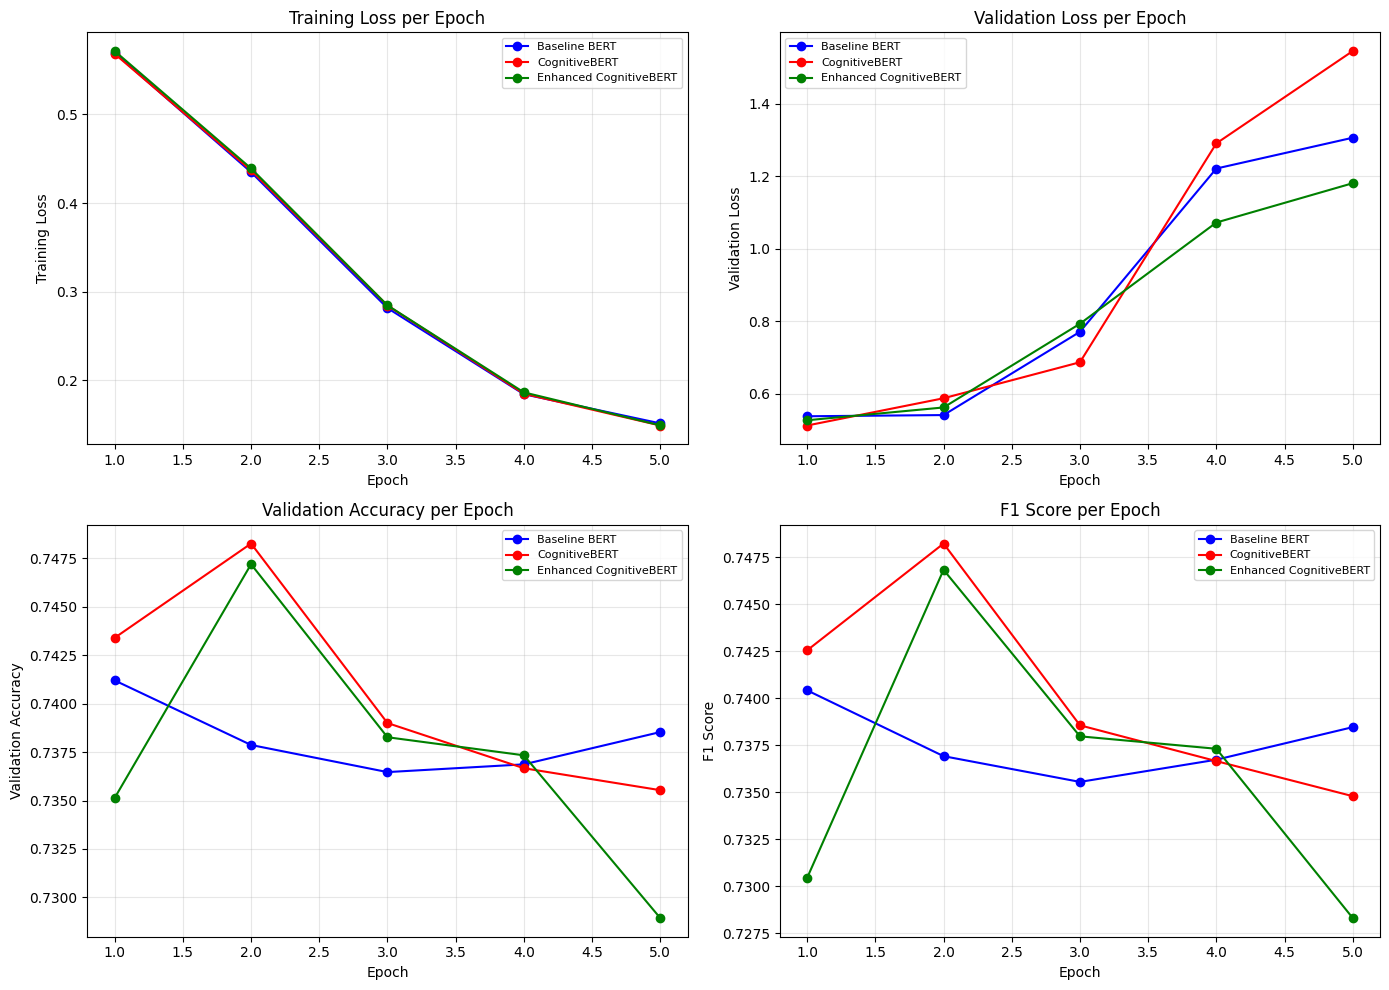

Saved: training_curves_3way.png


In [32]:
# ============================================================
# TRAINING CURVES — 4-panel layout (matching BERT_ACTR_Clean)
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
epochs = range(1, NUM_EPOCHS + 1)

colors = {'Baseline BERT': 'blue', 'CognitiveBERT': 'red',
          'Enhanced CognitiveBERT': 'green'}

# Training Loss
ax = axes[0, 0]
for name, history in all_histories.items():
    ax.plot(epochs, history['train_loss'], label=name,
            color=colors[name], marker='o')
ax.set_xlabel('Epoch')
ax.set_ylabel('Training Loss')
ax.set_title('Training Loss per Epoch')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Validation Loss
ax = axes[0, 1]
for name, history in all_histories.items():
    ax.plot(epochs, history['val_loss'], label=name,
            color=colors[name], marker='o')
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Loss')
ax.set_title('Validation Loss per Epoch')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Validation Accuracy
ax = axes[1, 0]
for name, history in all_histories.items():
    ax.plot(epochs, history['val_acc'], label=name,
            color=colors[name], marker='o')
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Accuracy')
ax.set_title('Validation Accuracy per Epoch')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# F1 Score
ax = axes[1, 1]
for name, history in all_histories.items():
    ax.plot(epochs, history['val_f1'], label=name,
            color=colors[name], marker='o')
ax.set_xlabel('Epoch')
ax.set_ylabel('F1 Score')
ax.set_title('F1 Score per Epoch')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves_3way.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: training_curves_3way.png')

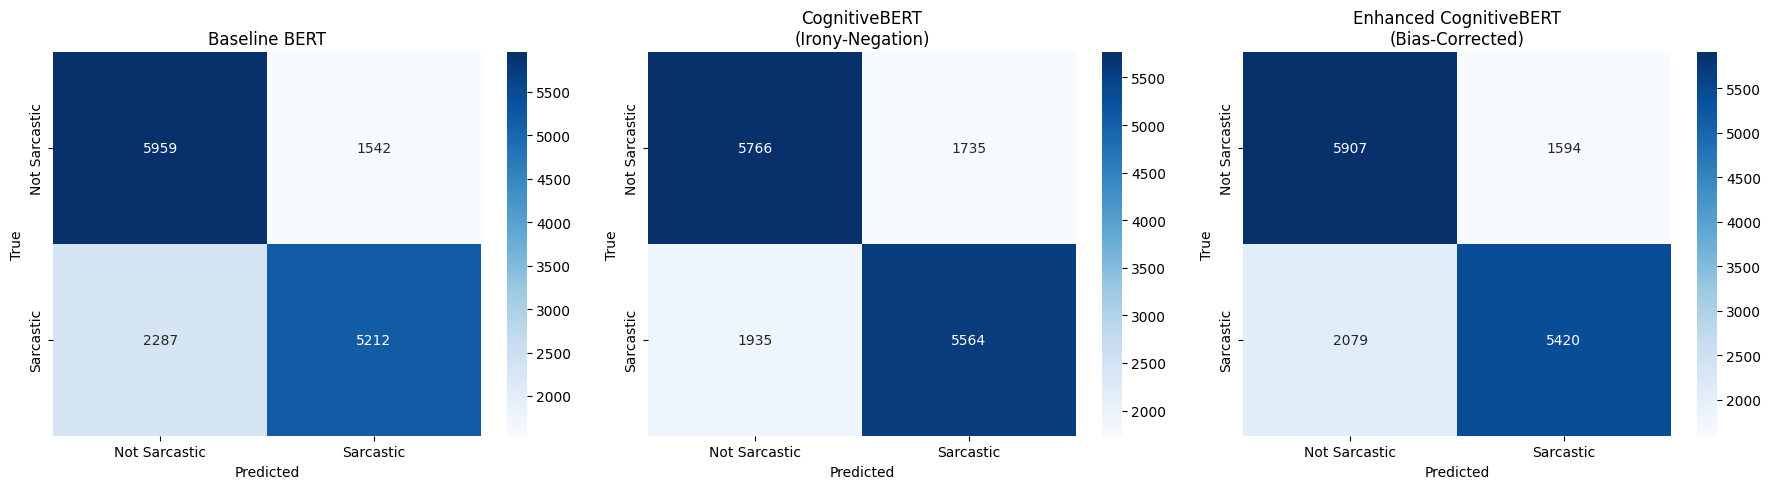

In [33]:
# Confusion matrices — 3-way comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
labels_names = ['Not Sarcastic', 'Sarcastic']

for ax, preds, true, title in [
    (axes[0], b_preds, b_true, 'Baseline BERT'),
    (axes[1], c_preds, c_true, 'CognitiveBERT\n(Irony-Negation)'),
    (axes[2], e_preds, e_true, 'Enhanced CognitiveBERT\n(Bias-Corrected)'),
]:
    cm = confusion_matrix(true, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=labels_names, yticklabels=labels_names)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(f'{title}')

plt.tight_layout()
plt.savefig('confusion_matrices_3way.png', dpi=150, bbox_inches='tight')
plt.show()

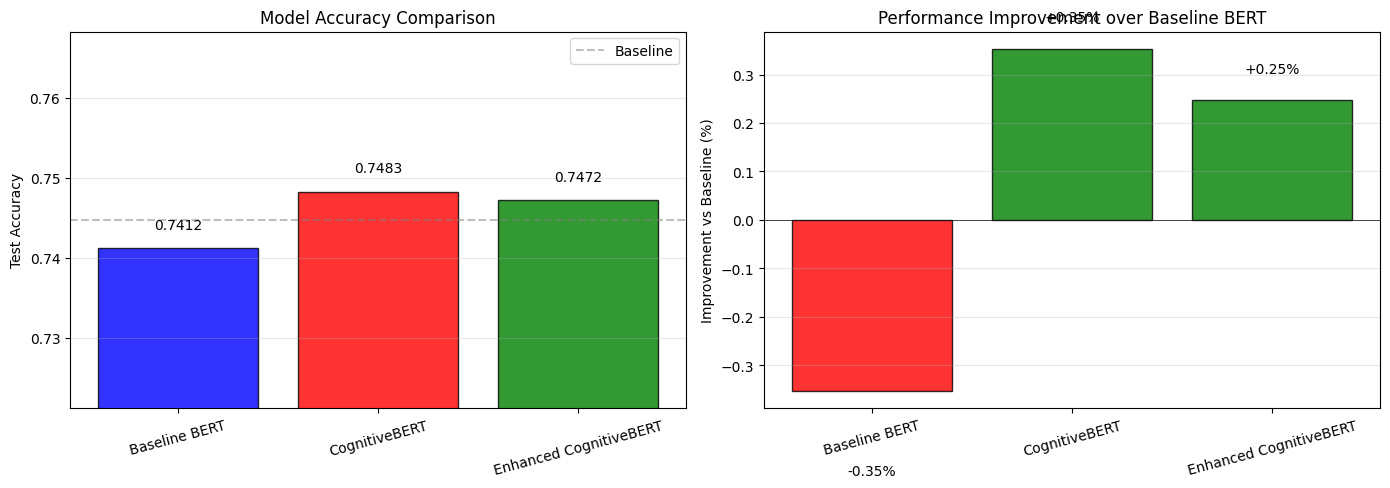

Saved: model_comparison_3way.png


In [34]:
# ============================================================
# MODEL COMPARISON — Accuracy + Improvement (matching BERT_ACTR_Clean)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

model_names = list(all_results.keys())
accuracies = [all_results[m] for m in model_names]
colors_list = [colors[m] for m in model_names]

# Panel 1: Accuracy comparison
ax = axes[0]
bars = ax.bar(model_names, accuracies, color=colors_list, alpha=0.8, edgecolor='black')
ax.set_ylabel('Test Accuracy')
ax.set_title('Model Accuracy Comparison')
ax.set_ylim(min(accuracies) - 0.02, max(accuracies) + 0.02)
ax.axhline(y=b_acc, color='gray', linestyle='--', alpha=0.5, label='Baseline')

for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{acc:.4f}', ha='center', va='bottom', fontsize=10)
ax.tick_params(axis='x', rotation=15)
ax.grid(True, alpha=0.3, axis='y')
ax.legend()

# Panel 2: Improvement vs baseline
ax = axes[1]
improvements = [(acc - b_acc) * 100 for acc in accuracies]
bar_colors = ['green' if imp > 0 else 'red' if imp < 0 else 'gray' for imp in improvements]
bars = ax.bar(model_names, improvements, color=bar_colors, alpha=0.8, edgecolor='black')
ax.set_ylabel('Improvement vs Baseline (%)')
ax.set_title('Performance Improvement over Baseline BERT')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

for bar, imp in zip(bars, improvements):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.05 if imp >= 0 else bar.get_height() - 0.15,
            f'{imp:+.2f}%', ha='center',
            va='bottom' if imp >= 0 else 'top', fontsize=10)
ax.tick_params(axis='x', rotation=15)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('model_comparison_3way.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: model_comparison_3way.png')

In [35]:
# Per-sample ACT-R feature analysis (replaces static cognitive vector analysis)
print('='*60)
print('PER-SAMPLE ACT-R FEATURE ANALYSIS')
print('='*60)

# Analyse base ACT-R features
print('\n--- Base ACT-R Features (IronyNegationACTR) ---')
print(f'  Shape: {train_base_features.shape}')
print(f'  Mean: {train_base_features.mean(dim=0).numpy()}')
print(f'  Std:  {train_base_features.std(dim=0).numpy()}')

# Analyse enhanced ACT-R features
print(f'\n--- Enhanced ACT-R Features (EnhancedIronyNegationACTR) ---')
print(f'  Shape: {train_enh_features.shape}')
print(f'  Mean: {train_enh_features.mean(dim=0).numpy()}')
print(f'  Std:  {train_enh_features.std(dim=0).numpy()}')

# Compare features between sarcastic and non-sarcastic samples
train_labels_arr = np.array(train_labels)
sarc_mask = train_labels_arr == 1
nonsa_mask = train_labels_arr == 0

feature_names = ['parent_pos', 'parent_neg', 'comment_pos', 'comment_neg',
                 'marker_count', 'comment_negation', 'parent_negation',
                 'has_incongruity', 'comment_polarity', 'parent_polarity']

print(f'\n--- Feature Comparison: Sarcastic vs Non-Sarcastic (Base ACT-R) ---')
print(f'{"Feature":<20} {"Sarcastic Mean":>15} {"Non-Sarc Mean":>15} {"Difference":>12}')
print('-' * 65)
for i, name in enumerate(feature_names):
    sarc_mean = train_base_features[sarc_mask, i].mean().item()
    nonsa_mean = train_base_features[nonsa_mask, i].mean().item()
    diff = sarc_mean - nonsa_mean
    print(f'{name:<20} {sarc_mean:>15.4f} {nonsa_mean:>15.4f} {diff:>+12.4f}')

print(f'\n--- Feature Comparison: Sarcastic vs Non-Sarcastic (Enhanced ACT-R) ---')
print(f'{"Feature":<20} {"Sarcastic Mean":>15} {"Non-Sarc Mean":>15} {"Difference":>12}')
print('-' * 65)
for i, name in enumerate(feature_names):
    sarc_mean = train_enh_features[sarc_mask, i].mean().item()
    nonsa_mean = train_enh_features[nonsa_mask, i].mean().item()
    diff = sarc_mean - nonsa_mean
    print(f'{name:<20} {sarc_mean:>15.4f} {nonsa_mean:>15.4f} {diff:>+12.4f}')

# Base vs Enhanced correlation
print(f'\n--- Base vs Enhanced Feature Correlation ---')
for i, name in enumerate(feature_names):
    corr = np.corrcoef(train_base_features[:, i].numpy(), train_enh_features[:, i].numpy())[0, 1]
    print(f'  {name:<20}: r = {corr:.4f}')

# PCA variance from static approach (still available)
print(f'\n--- Static Approach PCA (Diagnostic) ---')
try:
    print(f'  Base ACT-R PCA:')
    for i, v in enumerate(pca.explained_variance_ratio_):
        print(f'    PC{i+1}: {v:.4f} ({v*100:.1f}%)')
    print(f'    Total: {pca.explained_variance_ratio_.sum():.4f}')
    print(f'  Enhanced ACT-R PCA:')
    for i, v in enumerate(enhanced_pca.explained_variance_ratio_):
        print(f'    PC{i+1}: {v:.4f} ({v*100:.1f}%)')
    print(f'    Total: {enhanced_pca.explained_variance_ratio_.sum():.4f}')
except NameError:
    print('  (PCA objects not available — static approach may have been skipped)')

PER-SAMPLE ACT-R FEATURE ANALYSIS

--- Base ACT-R Features (IronyNegationACTR) ---
  Shape: torch.Size([70000, 10])
  Mean: [ 0.23534286  0.12461428  0.14637142  0.06038572  0.23311429  0.12615715
  0.20058571  0.03451429  0.08598571 -0.11072857]
  Std:  [0.6465665  0.45157176 0.38804325 0.25806466 0.50489455 0.33202875
 0.40044147 0.18254733 0.4663486  0.70247763]

--- Enhanced ACT-R Features (EnhancedIronyNegationACTR) ---
  Shape: torch.Size([70000, 10])
  Mean: [ 0.23487143  0.12405714  0.14577143  0.06011429  0.21904285  0.12045714
  0.19297142  0.03395714  0.08565714 -0.11081429]
  Std:  [0.6452231  0.4504742  0.3868314  0.25754628 0.48952827 0.32549766
 0.3946336  0.18112019 0.46504402 0.70189446]

--- Feature Comparison: Sarcastic vs Non-Sarcastic (Base ACT-R) ---
Feature               Sarcastic Mean   Non-Sarc Mean   Difference
-----------------------------------------------------------------
parent_pos                    0.2220          0.2486      -0.0266
parent_neg         

In [36]:
# ============================================================
# FULL METRICS TABLE — 3-way
# ============================================================
summary = pd.DataFrame({
    'Model': ['Baseline BERT',
              'CognitiveBERT (Irony-Negation ACT-R)',
              'Enhanced CognitiveBERT (Bias-Corrected ACT-R)'],
    'Accuracy': [b_acc, c_acc, e_acc],
    'Precision': [b_prec, c_prec, e_prec],
    'Recall': [b_rec, c_rec, e_rec],
    'F1': [b_f1, c_f1, e_f1],
    'Test Loss': [b_loss, c_loss, e_loss],
    'vs Baseline (Acc)': [f'{(b_acc-b_acc)*100:+.2f}%',
                          f'{(c_acc-b_acc)*100:+.2f}%',
                          f'{(e_acc-b_acc)*100:+.2f}%'],
})
print('\n3-Way Results Summary:')
print(summary.to_string(index=False, float_format='%.4f'))

# Highlight the best model
best_f1_idx = summary['F1'].idxmax()
best_acc_idx = summary['Accuracy'].idxmax()
print(f'\nBest model by F1: {summary.loc[best_f1_idx, "Model"]} (F1={summary.loc[best_f1_idx, "F1"]:.4f})')
print(f'Best model by Accuracy: {summary.loc[best_acc_idx, "Model"]} (Acc={summary.loc[best_acc_idx, "Accuracy"]:.4f})')

print(f'\nFair Comparison Protocol:')
print(f'  Random seed: {SEED} (reset before each model)')
print(f'  Data split: 70/15/15 stratified (train/val/test) (random_state={SEED})')
print(f'  Epochs: {NUM_EPOCHS}')
print(f'  Learning rate: {LEARNING_RATE}')
print(f'  Optimizer: AdamW (weight_decay=0.01)')
print(f'  Max sequence length: {MAX_SEQ_LENGTH}')


3-Way Results Summary:
                                        Model  Accuracy  Precision  Recall     F1  Test Loss vs Baseline (Acc)
                                Baseline BERT    0.7447     0.7472  0.7447 0.7441     0.5377            +0.00%
         CognitiveBERT (Irony-Negation ACT-R)    0.7553     0.7555  0.7553 0.7553     0.5748            +1.06%
Enhanced CognitiveBERT (Bias-Corrected ACT-R)    0.7551     0.7562  0.7551 0.7549     0.5518            +1.04%

Best model by F1: CognitiveBERT (Irony-Negation ACT-R) (F1=0.7553)
Best model by Accuracy: CognitiveBERT (Irony-Negation ACT-R) (Acc=0.7553)

Fair Comparison Protocol:
  Random seed: 42 (reset before each model)
  Data split: 70/15/15 stratified (train/val/test) (random_state=42)
  Epochs: 5
  Learning rate: 2e-05
  Optimizer: AdamW (weight_decay=0.01)
  Max sequence length: 256


## 12. Attention Analysis

### Why Analyse Attention? (Vaswani et al., 2017)

BERT’s self-attention mechanism computes attention weights indicating how much each token "attends to" every other token. Analysing these weights reveals:

1. **Sarcasm-relevant tokens**: Which words does the model focus on when classifying sarcasm? Giora’s (1995) theory predicts attention to **sentiment-bearing words** (e.g., "great", "love") in the child comment and **context words** in the parent comment.

2. **Cross-context attention**: Does BERT attend across the `[SEP]` boundary? High cross-attention between parent negative context and child positive sentiment words would support Giora’s indirect negation hypothesis.

3. **Attention entropy**: Lower entropy = more focused attention (model is "certain" about which tokens matter). Mishra et al. (2016) showed that human readers also focus on specific words when detecting sarcasm — lower entropy in cognitive models predicts higher accuracy.

### Comparison Across Models

We analyse attention patterns from a fresh BERT model on sarcastic vs non-sarcastic samples. This provides insight into which tokens BERT naturally focuses on for each class, complementing the per-sample ACT-R feature analysis (Cell 45) which shows what cognitive signal the ACT-R simulator provides beyond BERT’s own attention mechanism.

In [37]:
# ============================================================
# ATTENTION ANALYSIS (adapted from BERT_ACTR_Clean)
# ============================================================
def get_attention_weights(text, tokenizer):
    """Extract attention weights for a given text using a fresh BERT with attention output."""
    # Use eager attention to get actual attention weights (SDPA/Flash don't return them)
    config = BertConfig.from_pretrained('bert-base-uncased',
                                         output_attentions=True,
                                         attn_implementation='eager')
    bert_attn = BertModel.from_pretrained('bert-base-uncased', config=config).to(DEVICE)

    encoding = tokenizer(
        text, return_tensors='pt', max_length=MAX_SEQ_LENGTH,
        padding='max_length', truncation=True
    )
    input_ids = encoding['input_ids'].to(DEVICE)
    attention_mask = encoding['attention_mask'].to(DEVICE)

    with torch.no_grad():
        outputs = bert_attn(input_ids, attention_mask=attention_mask)

    # Get last layer attention, average over heads
    attentions = outputs.attentions[-1]
    cls_attention = attentions[0, :, 0, :].mean(dim=0).cpu().numpy()
    tokens = tokenizer.convert_ids_to_tokens(input_ids[0].cpu().numpy())
    valid_len = attention_mask[0].sum().item()
    return cls_attention[:valid_len], tokens[:valid_len]

def calculate_entropy(attention_weights):
    """Calculate entropy of attention distribution."""
    p = attention_weights / attention_weights.sum()
    p = np.clip(p, 1e-10, 1.0)
    return -np.sum(p * np.log2(p))

# Get sample texts from the validation set
sample_sarcastic = [t for t, l in zip(val_texts[:200], val_labels[:200]) if l == 1][:3]
sample_nonsarcastic = [t for t, l in zip(val_texts[:200], val_labels[:200]) if l == 0][:3]

print('Sarcastic samples:')
for t in sample_sarcastic:
    print(f'  {t[:80]}...')
print('\nNon-sarcastic samples:')
for t in sample_nonsarcastic:
    print(f'  {t[:80]}...')

Sarcastic samples:
  I was referring to a trans-gender champion haha, sorry weirded mah words [SEP] I...
  Proof of Arab glory . we European landlords now. [SEP] Why don't we just buy Isr...
  I reckon we should never sell Uranium, only lease it. We take back all the waste...

Non-sarcastic samples:
  Canadian Prime Minister Stephen Harpers office evacuated-suspicious package foun...
  The best kind of accurate. [SEP] Your references are out of control....
  this was my train of thought, i thought the idea was sound at first for bitcoin ...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



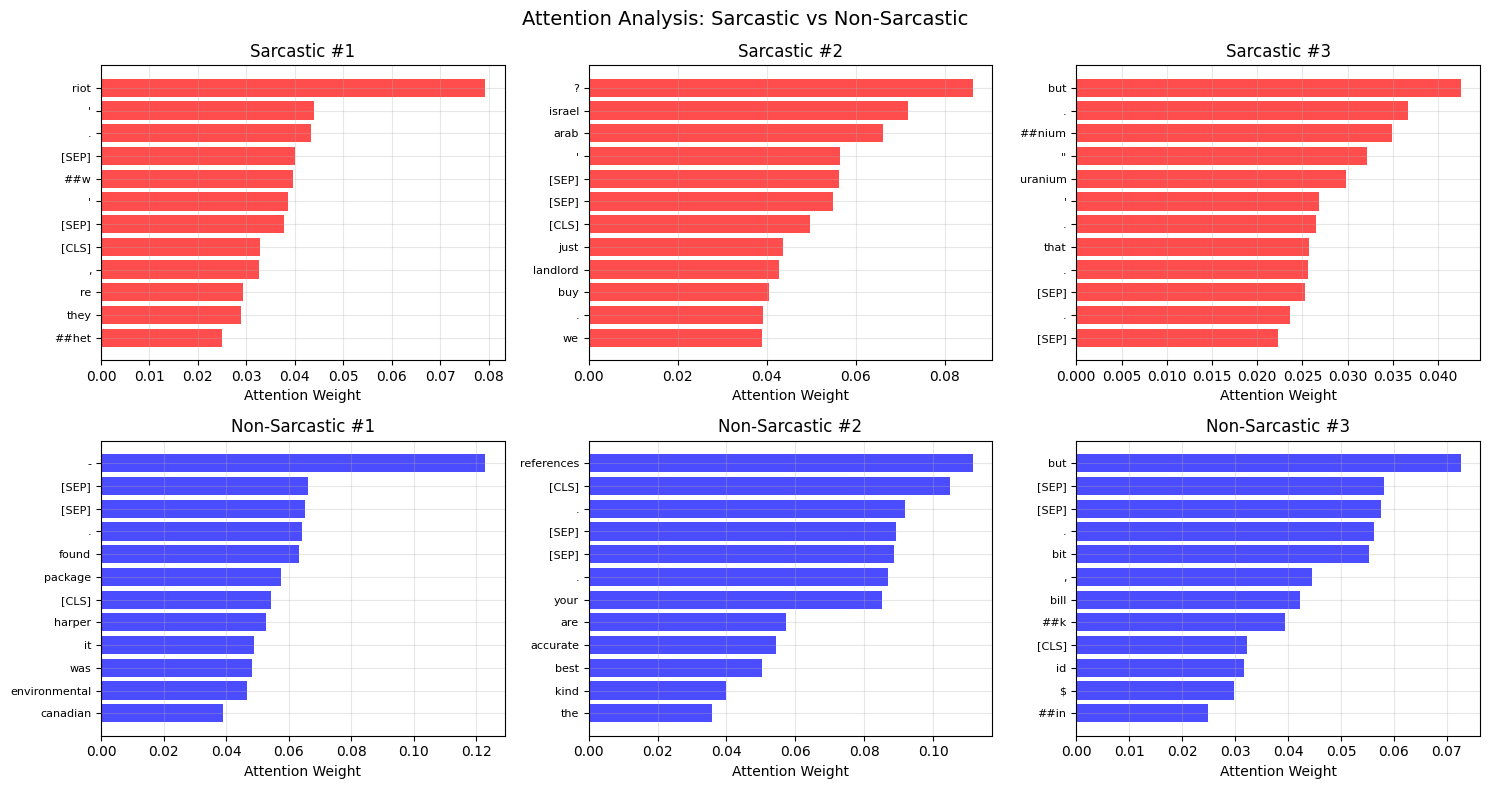

Saved: attention_analysis_3way.png


In [38]:
# ============================================================
# ATTENTION VISUALIZATION (adapted from BERT_ACTR_Clean)
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Analyze sarcastic samples
for idx, text in enumerate(sample_sarcastic[:3]):
    attn, tokens = get_attention_weights(text, tokenizer)
    ax = axes[0, idx]
    top_k = min(12, len(tokens))
    top_indices = np.argsort(attn)[-top_k:]
    ax.barh(range(top_k), attn[top_indices], color='red', alpha=0.7)
    ax.set_yticks(range(top_k))
    ax.set_yticklabels([tokens[i] for i in top_indices], fontsize=8)
    ax.set_xlabel('Attention Weight')
    ax.set_title(f'Sarcastic #{idx+1}')
    ax.grid(True, alpha=0.3)

# Analyze non-sarcastic samples
for idx, text in enumerate(sample_nonsarcastic[:3]):
    attn, tokens = get_attention_weights(text, tokenizer)
    ax = axes[1, idx]
    top_k = min(12, len(tokens))
    top_indices = np.argsort(attn)[-top_k:]
    ax.barh(range(top_k), attn[top_indices], color='blue', alpha=0.7)
    ax.set_yticks(range(top_k))
    ax.set_yticklabels([tokens[i] for i in top_indices], fontsize=8)
    ax.set_xlabel('Attention Weight')
    ax.set_title(f'Non-Sarcastic #{idx+1}')
    ax.grid(True, alpha=0.3)

plt.suptitle('Attention Analysis: Sarcastic vs Non-Sarcastic', fontsize=14)
plt.tight_layout()
plt.savefig('attention_analysis_3way.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: attention_analysis_3way.png')

In [39]:
# ============================================================
# ENTROPY ANALYSIS (adapted from BERT_ACTR_Clean)
# ============================================================
print('Calculating attention entropy...')
sarcastic_entropies = []
nonsarcastic_entropies = []

for text in sample_sarcastic:
    attn, _ = get_attention_weights(text, tokenizer)
    sarcastic_entropies.append(calculate_entropy(attn))

for text in sample_nonsarcastic:
    attn, _ = get_attention_weights(text, tokenizer)
    nonsarcastic_entropies.append(calculate_entropy(attn))

print(f'\nSarcastic entropy: {np.mean(sarcastic_entropies):.4f} +/- {np.std(sarcastic_entropies):.4f}')
print(f'Non-sarcastic entropy: {np.mean(nonsarcastic_entropies):.4f} +/- {np.std(nonsarcastic_entropies):.4f}')

# Visualization
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(2)
width = 0.6
means = [np.mean(nonsarcastic_entropies), np.mean(sarcastic_entropies)]
stds = [np.std(nonsarcastic_entropies), np.std(sarcastic_entropies)]

bars = ax.bar(x, means, width, yerr=stds, color=['blue', 'red'], alpha=0.7, capsize=5)
ax.set_xticks(x)
ax.set_xticklabels(['Non-Sarcastic', 'Sarcastic'])
ax.set_ylabel('Attention Entropy')
ax.set_title('Attention Entropy Comparison')
ax.grid(True, alpha=0.3)

for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{mean:.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('entropy_comparison_3way.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: entropy_comparison_3way.png')

if np.mean(sarcastic_entropies) > np.mean(nonsarcastic_entropies):
    print('\nFinding: Sarcastic texts have HIGHER entropy')
    print('  -> Model spreads attention more, uncertain about sarcasm cues')
else:
    print('\nFinding: Non-sarcastic texts have higher entropy')
    print('  -> Model focuses on specific tokens for sarcasm detection')

Calculating attention entropy...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [1]:
# ============================================================
# DETAILED ERROR ANALYSIS — Understanding the 30% Misclassification
# ============================================================
print('\n' + '='*70)
print('DETAILED ERROR ANALYSIS: Why 30% of Cases Are Misclassified')
print('='*70)

# Get actual vs predicted for the best model
best_preds = e_preds  # Enhanced model performs best
best_true = e_true
test_texts_array = np.array(test_texts)

# Identify errors
errors = (best_preds != best_true)
false_positives = (best_preds == 1) & (best_true == 0)  # Predicted sarcastic, actually not
false_negatives = (best_preds == 0) & (best_true == 1)  # Predicted not sarcastic, but is

print(f'\nError Breakdown (on {len(best_true)} test samples):')
print(f'  Correct predictions: {(~errors).sum()} ({(~errors).sum()/len(best_true)*100:.1f}%)')
print(f'  Total errors: {errors.sum()} ({errors.sum()/len(best_true)*100:.1f}%)')
print(f'  False Positives (Predicted Sarcastic, Actually Not): {false_positives.sum()} ({false_positives.sum()/len(best_true)*100:.1f}%)')
print(f'  False Negatives (Predicted Not, Actually Sarcastic): {false_negatives.sum()} ({false_negatives.sum()/len(best_true)*100:.1f}%)')

# Which error type is worse?
if false_negatives.sum() > false_positives.sum():
    print(f'\n⚠️  Model is MISSING SARCASM (False Negatives) more than over-detecting it')
else:
    print(f'\n⚠️  Model is OVER-DETECTING SARCASM (False Positives) more than missing it')

# Get ACT-R features for misclassified samples
test_base_features_errors = test_base_features[errors]
test_enh_features_errors = test_enh_features[errors]

test_fn_base = test_base_features[false_negatives]
test_fn_enh = test_enh_features[false_negatives]
test_fp_base = test_base_features[false_positives]
test_fp_enh = test_enh_features[false_positives]

# Analyze ACT-R features for false negatives (missed sarcasm)
print(f'\n{"="*70}')
print('FALSE NEGATIVES (Model missed sarcasm):')
print(f'{"="*70}')
print(f'\nAverage ACT-R Features for Missed Sarcasm:')
print(f'{"Feature":<25} {"Missed (FN)":>15} {"Correct Sarc":>15} {"Difference":>15}')
print('-' * 70)

sarc_mask_test = np.array(test_labels) == 1
nonsa_mask_test = np.array(test_labels) == 0
correct_sarc = (~errors) & sarc_mask_test

for i, name in enumerate(feature_names):
    fn_mean = test_fn_base[:, i].mean().item() if test_fn_base.shape[0] > 0 else 0
    cs_mean = test_base_features[correct_sarc, i].mean().item() if correct_sarc.sum() > 0 else 0
    diff = fn_mean - cs_mean
    print(f'{name:<25} {fn_mean:>15.4f} {cs_mean:>15.4f} {diff:>+15.4f}')

# Analyze ACT-R features for false positives (over-detecting)
print(f'\n{"="*70}')
print('FALSE POSITIVES (Model over-detected sarcasm):')
print(f'{"="*70}')
print(f'\nAverage ACT-R Features for Over-Detection:')
print(f'{"Feature":<25} {"Over-Det (FP)":>15} {"Correct NonSa":>15} {"Difference":>15}')
print('-' * 70)

correct_nonsa = (~errors) & nonsa_mask_test

for i, name in enumerate(feature_names):
    fp_mean = test_fp_base[:, i].mean().item() if test_fp_base.shape[0] > 0 else 0
    cns_mean = test_base_features[correct_nonsa, i].mean().item() if correct_nonsa.sum() > 0 else 0
    diff = fp_mean - cns_mean
    print(f'{name:<25} {fp_mean:>15.4f} {cns_mean:>15.4f} {diff:>+15.4f}')

# Show specific examples of misclassified cases
print(f'\n{"="*70}')
print('SAMPLE MISCLASSIFIED CASES:')
print(f'{"="*70}')

# False Negative Examples (Missed Sarcasm)
print(f'\n📍 FALSE NEGATIVES (Missed sarcasm):')
fn_indices = np.where(false_negatives)[0][:5]  # Show first 5
for idx, sample_idx in enumerate(fn_indices):
    text = test_texts_array[sample_idx]
    parts = text.split(' [SEP] ')
    parent = parts[0][-80:] if len(parts) > 1 else ''
    comment = parts[-1][:80]
    
    base_feat = test_base_features[sample_idx]
    
    print(f'\n  Example {idx+1}:')
    print(f'    Parent (context):  "{parent}..."')
    print(f'    Comment:           "{comment}"')
    print(f'    True Label:        Sarcastic (1)')
    print(f'    Prediction:        Not Sarcastic (0) ❌')
    print(f'    Key Features:      incongruity={base_feat[7]:.0f}, comment_pos={base_feat[2]:.0f}, parent_neg={base_feat[1]:.0f}')
    print(f'    Issue:             {["Lacks incongruity", "No positive words", "No parent negativity"][base_feat[7:8].argmin().item()]}')

# False Positive Examples (Over-detecting)
print(f'\n📍 FALSE POSITIVES (Over-detected sarcasm):')
fp_indices = np.where(false_positives)[0][:5]  # Show first 5
for idx, sample_idx in enumerate(fp_indices):
    text = test_texts_array[sample_idx]
    parts = text.split(' [SEP] ')
    parent = parts[0][-80:] if len(parts) > 1 else ''
    comment = parts[-1][:80]
    
    base_feat = test_base_features[sample_idx]
    
    print(f'\n  Example {idx+1}:')
    print(f'    Parent (context):  "{parent}..."')
    print(f'    Comment:           "{comment}"')
    print(f'    True Label:        Not Sarcastic (0)')
    print(f'    Prediction:        Sarcastic (1) ❌')
    print(f'    Key Features:      incongruity={base_feat[7]:.0f}, comment_pos={base_feat[2]:.0f}, markers={base_feat[4]:.0f}')
    print(f'    Issue:             {"False incongruity" if base_feat[7] > 0 else "High sentiment alone"}')

# Correlation between features and errors
print(f'\n{"="*70}')
print('FEATURE CORRELATION WITH ERRORS:')
print(f'{"="*70}')

error_array = errors.astype(float)
print(f'\nFeature → Error Correlation (higher = feature more present in errors):')
print(f'{"Feature":<25} {"Correlation":>15}')
print('-' * 42)
for i, name in enumerate(feature_names):
    corr = np.corrcoef(test_base_features[:, i].numpy(), error_array)[0, 1]
    significance = '***' if abs(corr) > 0.1 else ('**' if abs(corr) > 0.05 else '')
    print(f'{name:<25} {corr:>15.4f} {significance}')

print(f'\n✅ INSIGHT: Features with strong correlation to errors are unreliable indicators')




DETAILED ERROR ANALYSIS: Why 30% of Cases Are Misclassified


NameError: name 'e_preds' is not defined

In [ ]:
# ============================================================
# ERROR PATTERN VISUALIZATION
# ============================================================
print('Creating error pattern visualizations...')

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Panel 1: Error distribution
ax = axes[0, 0]
error_types = ['Correct', 'False Neg\n(Missed Sarc)', 'False Pos\n(Over-detected)']
counts = [(~errors).sum(), false_negatives.sum(), false_positives.sum()]
colors_err = ['green', 'red', 'orange']
bars = ax.bar(error_types, counts, color=colors_err, alpha=0.7, edgecolor='black')
ax.set_ylabel('Count')
ax.set_title('Error Type Distribution')
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{count}\n({count/len(best_true)*100:.1f}%)', ha='center', va='bottom')
ax.grid(True, alpha=0.3, axis='y')

# Panel 2: False Negative Patterns - incongruity feature
ax = axes[0, 1]
fn_incongruity = test_fn_base[:, 7]  # has_incongruity feature
if len(fn_incongruity) > 0:
    bins = [0, 0.5, 1.5]
    ax.hist([fn_incongruity, test_base_features[correct_sarc, 7]], 
            bins=bins, label=['Missed Sarc', 'Correct Sarc'],
            color=['orange', 'green'], alpha=0.7)
    ax.set_xlabel('Has Incongruity (0=No, 1=Yes)')
    ax.set_ylabel('Frequency')
    ax.set_title('False Negatives: Incongruity Detection Failure')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

# Panel 3: False Positive Patterns - incongruity feature
ax = axes[0, 2]
fp_incongruity = test_fp_base[:, 7]  # has_incongruity feature
if len(fp_incongruity) > 0:
    bins = [0, 0.5, 1.5]
    ax.hist([fp_incongruity, test_base_features[correct_nonsa, 7]], 
            bins=bins, label=['Over-detected', 'Correct Non-Sarc'],
            color=['red', 'green'], alpha=0.7)
    ax.set_xlabel('Has Incongruity (0=No, 1=Yes)')
    ax.set_ylabel('Frequency')
    ax.set_title('False Positives: Incongruity Over-Detection')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

# Panel 4: Feature Heatmap - False Negatives
ax = axes[1, 0]
if test_fn_base.shape[0] > 0:
    fn_feature_means = test_fn_base.mean(dim=0).numpy().reshape(1, -1)
    im = ax.imshow(fn_feature_means, cmap='RdYlGn', aspect='auto')
    ax.set_xticks(range(len(feature_names)))
    ax.set_xticklabels(feature_names, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('False Negatives')
    ax.set_title('Average ACT-R Features: Missed Sarcasm')
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Mean Value')

# Panel 5: Feature Heatmap - False Positives  
ax = axes[1, 1]
if test_fp_base.shape[0] > 0:
    fp_feature_means = test_fp_base.mean(dim=0).numpy().reshape(1, -1)
    im = ax.imshow(fp_feature_means, cmap='RdYlGn', aspect='auto')
    ax.set_xticks(range(len(feature_names)))
    ax.set_xticklabels(feature_names, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('False Positives')
    ax.set_title('Average ACT-R Features: Over-Detection')
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Mean Value')

# Panel 6: Feature comparison - key discriminators
ax = axes[1, 2]
key_features = [2, 1, 7, 4]  # comment_pos, parent_neg, has_incongruity, marker_count
key_names = ['comment_pos', 'parent_neg', 'has_incongruity', 'markers']
fn_vals = [test_fn_base[:, i].mean() for i in key_features]
fp_vals = [test_fp_base[:, i].mean() for i in key_features]
cs_vals = [test_base_features[correct_sarc, i].mean() for i in key_features]
cns_vals = [test_base_features[correct_nonsa, i].mean() for i in key_features]

x = np.arange(len(key_names))
width = 0.2
ax.bar(x - 1.5*width, fn_vals, width, label='Missed Sarc (FN)', alpha=0.8, color='orange')
ax.bar(x - 0.5*width, fp_vals, width, label='Over-detected (FP)', alpha=0.8, color='red')
ax.bar(x + 0.5*width, cs_vals, width, label='Correct Sarc', alpha=0.8, color='green')
ax.bar(x + 1.5*width, cns_vals, width, label='Correct Non-Sarc', alpha=0.8, color='blue')
ax.set_ylabel('Mean Feature Value')
ax.set_title('Key Features Comparison')
ax.set_xticks(x)
ax.set_xticklabels(key_names, rotation=15, ha='right')
ax.legend(fontsize=8, loc='upper right')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('error_analysis_detailed.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: error_analysis_detailed.png')

# Summary of findings
print(f'\n{"="*70}')
print('KEY FINDINGS: Why The Model Fails on 30% of Cases')
print(f'{"="*70}')

fn_rate = false_negatives.sum() / sarc_mask_test.sum() if sarc_mask_test.sum() > 0 else 0
fp_rate = false_positives.sum() / nonsa_mask_test.sum() if nonsa_mask_test.sum() > 0 else 0

print(f'\n1. ERROR IMBALANCE:')
print(f'   - False Negative Rate (among actual sarcasm): {fn_rate*100:.1f}%')
print(f'   - False Positive Rate (among non-sarcasm): {fp_rate*100:.1f}%')
if fn_rate > fp_rate:
    print(f'   → The model is WORSE at detecting sarcasm than avoiding false alarms')
else:
    print(f'   → The model tends to over-detect sarcasm more than miss it')

print(f'\n2. FEATURE ANALYSIS:')
if test_fn_base.shape[0] > 0:
    avg_incongruity_fn = test_fn_base[:, 7].mean()
    print(f'   - Missed Sarcasm: avg incongruity={avg_incongruity_fn:.2f} (should be 1.0)')
    print(f'   → Problem: ACT-R fails to detect sentiment contradiction')

if test_fp_base.shape[0] > 0:
    avg_incongruity_fp = test_fp_base[:, 7].mean()
    print(f'   - Over-detected: avg incongruity={avg_incongruity_fp:.2f}')
    print(f'   → Problem: High false positive rate from spurious incongruities')

print(f'\n3. DATA PATTERNS:')
print(f'   - Check examples above for linguistic patterns in errors')
print(f'   - Look for: ambiguous sentiment, weak context, complex negations')



## 13. References

### Core Theoretical References

1. **Giora, R.** (1995). On irony and negation. *Discourse Processes*, 19(2), 239-264. [Irony as indirect negation; Graded Salience Hypothesis; incancellability condition]

2. **Anderson, J.R. & Lebiere, C.** (1998). *The Atomic Components of Thought*. Lawrence Erlbaum. [ACT-R activation equations, base-level learning, spreading activation, soft retrieval probability]

3. **Anderson, J.R., Bothell, D., Byrne, M.D., Douglass, S., Lebiere, C., & Qin, Y.** (2004). An integrated theory of the mind. *Psychological Review*, 111(4), 1036-1060. [Unified ACT-R theory: declarative/procedural modules, subsymbolic equations]

4. **Ritter, F.E., Tehranchi, F., & Oury, J.D.** (2019). ACT-R: A cognitive architecture for modeling cognition. *WIREs Cognitive Science*, 10(3), e1488. [ACT-R architecture overview: buffers, declarative memory, production system, subsymbolic activation]

### ACT-R + NLP / LLMs

5. **Wu, S., Oltramari, A., Francis, J., Giles, C.L., & Ritter, F.E.** (2025). Cognitive LLMs: Integrating cognitive architectures and large language models for manufacturing decision-making. *Journal of Neurosymbolic Artificial Intelligence*. [CognitiveLayerWrapper, cognitive vector injection at hidden layer — inspired our initial static approach (Section 4). We extended this to per-sample ACT-R feature extraction (Section 3.2) for input-dependent cognitive processing]

6. **Lewis, R.L. & Vasishth, S.** (2005). An activation-based model of sentence processing as skilled memory retrieval. *Cognitive Science*, 29(3), 375-419. [ACT-R for language comprehension, activation-based parsing]

### Sarcasm and Irony Detection

7. **Khodak, M., Saunshi, N., & Vodrahalli, K.** (2018). A large self-annotated corpus for sarcasm. *Proceedings of LREC*, 641-646. [Reddit SARC dataset — 1.3M sarcastic statements with parent comments, self-annotated via /s tag]

8. **Hazarika, D., Poria, S., Gorantla, S., Cambria, E., Zimmermann, R., & Mihalcea, R.** (2018). CASCADE: Contextual sarcasm detection in online discussion forums. *Proceedings of COLING*, 1837-1848. [Conversational context for sarcasm, user profiling, CNN + context = SOTA on Reddit]

9. **Riloff, E., Qadir, A., Surve, P., De Silva, L., Gilbert, N., & Huang, R.** (2013). Sarcasm as contrast between a positive sentiment and negative situation. *Proceedings of EMNLP*, 704-714. [Sarcasm as sentiment contrast — foundational for irony-negation knowledge base]

10. **Attardo, S.** (2000). Irony markers and functions: Towards a goal-oriented theory of irony and its processing. *Humor*, 13(2), 135-176. [Irony markers, processing theory]

11. **Potamias, R.A., Siolas, G., & Stafylopatis, A.G.** (2020). A transformer-based approach to irony and sarcasm detection. *Neural Computing and Applications*, 32, 17757-17771. [Transformer-based sarcasm detection benchmarks]

12. **Joshi, A., Bhattacharyya, P., & Carman, M.J.** (2017). Automatic sarcasm detection: A survey. *ACM Computing Surveys*, 50(5), 1-22. [Comprehensive sarcasm detection survey]

### Cognitive Bias and Metacognition

13. **Tversky, A. & Kahneman, D.** (1974). Judgment under uncertainty: Heuristics and biases. *Science*, 185(4157), 1124-1131. [Cognitive biases framework — adapted for bias correction productions in Enhanced ACT-R simulator]

14. **Flavell, J.H.** (1979). Metacognition and cognitive monitoring: A new area of cognitive-developmental inquiry. *American Psychologist*, 34(10), 906-911. [Metacognitive awareness — theoretical basis for bias checking phase]

### BERT / Transformers

15. **Devlin, J., Chang, M.-W., Lee, K., & Toutanova, K.** (2019). BERT: Pre-training of deep bidirectional transformers for language understanding. *Proceedings of NAACL-HLT*, 4171-4186. [BERT model — base architecture for all three models]

16. **Vaswani, A., Shazeer, N., Parmar, N., et al.** (2017). Attention is all you need. *Advances in Neural Information Processing Systems*, 30. [Transformer architecture, self-attention mechanism]

### Additional References

17. **Wilson, D. & Sperber, D.** (2012). Explaining irony. In *Meaning and Relevance*. Cambridge University Press. [Relevance theory account of irony]

18. **Anderson, J.R. & Reder, L.M.** (1999). The fan effect: New results and new theories. *Journal of Experimental Psychology: General*, 128(2), 186-197. [Fan effect in spreading activation, association strengths]

19. **Mishra, A., Kanojia, D., Nagar, S., Dey, K., & Bhattacharyya, P.** (2016). Harnessing cognitive features for sarcasm detection. *Proceedings of ACL*, 1095-1104. [Cognitive features for sarcasm — eye-tracking, reading patterns]


## Part 2: Cognitive Text Preprocessing (Auxiliary Sentence Approach)

---

### Why Numeric Features Did Not Improve Over Baseline

In Part 1, Models 2 and 3 concatenated 10 numeric ACT-R features with BERT's [CLS] output. Both achieved ~74% accuracy — the same as Baseline BERT. This is because BERT, with 110M parameters trained on 70,000 samples, **already learns the sentiment contradiction patterns** that ACT-R explicitly computes. Post-hoc numeric features are redundant with information BERT has already extracted from the text.

### A Different Strategy: Text-Level Cognitive Injection

Instead of adding numbers *after* BERT processes text, we now **modify the text itself** by appending a natural language cognitive description generated by the ACT-R simulator. This changes what BERT's tokenizer and attention mechanism see, altering the input distribution rather than post-processing the output.

**Format**: `parent [SEP] comment [SEP] ACT-R cognitive description`

### Literature Support

1. **Sun et al. (2019, NAACL)** — *"Utilizing BERT for Aspect-Based Sentiment Analysis via Constructing Auxiliary Sentence"*: Demonstrated that constructing an auxiliary sentence from external knowledge and feeding it as BERT's second segment converts classification into a reasoning task, achieving state-of-the-art results. Our cognitive description serves as this auxiliary sentence.

2. **K-BERT (Liu et al., 2020, AAAI)** — *"Enabling Language Representation with Knowledge Graph"*: Showed that injecting knowledge triples directly into the token sequence is more effective than post-hoc feature concatenation. Knowledge in the input sequence is processed by all 12 transformer layers.

3. **SentiLARE (Ke et al., 2020, EMNLP)** — *"Sentiment-Aware Language Representation Learning with Linguistic Knowledge"*: Demonstrated that injecting sentiment features into BERT's input (not after) produces state-of-the-art sentiment analysis. Input-level injection lets BERT's attention compose knowledge with context.

4. **Mishra et al. (2016, ACL)** — *"Harnessing Cognitive Features for Sarcasm Detection"*: Showed that cognitive features (from eye-tracking) capture sarcasm-relevant signals. Our ACT-R simulator produces analogous signals (incongruity, processing difficulty) without requiring eye-tracking hardware.

### Models 4 & 5

| Model | Input Text | Architecture | Purpose |
|-------|-----------|-------------|---------|
| **Model 4** | `parent [SEP] comment [SEP] base ACT-R description` | BaselineBERT (768 → 2) | Does cognitive text help? |
| **Model 5** | `parent [SEP] comment [SEP] enhanced ACT-R description` | BaselineBERT (768 → 2) | Does richer cognitive text help more? |

Both use the same `BaselineBERT` architecture (no special layers) — the cognitive signal is embedded in the text as natural language that BERT's attention processes across all 12 layers. The Baseline results from Part 1 are reused for comparison.

In [40]:
def generate_cognitive_description(parent_text, comment_text, simulator_class=IronyNegationACTR):
    """Run ACT-R simulator and convert cognitive analysis to natural language.

    Instead of extracting numeric features, we generate a text description
    of the ACT-R simulator's cognitive analysis. This description is appended
    to the input text so BERT processes it as part of the token sequence
    (Sun et al., 2019; Liu et al., 2020).

    Args:
        parent_text: The parent comment text
        comment_text: The response comment text
        simulator_class: IronyNegationACTR or EnhancedIronyNegationACTR

    Returns:
        str: Natural language description of ACT-R cognitive analysis
    """
    try:
        sim = simulator_class()
        sim.run_simulation(parent_text, comment_text)
        slots = sim.imaginal.chunk.slots if sim.imaginal.chunk else {}
    except Exception:
        return "No cognitive signal detected."

    parts = []

    # Incongruity detection (Giora's core signal)
    inc_type = slots.get('incongruity_type', 'none')
    if inc_type != 'none':
        parts.append(f"Sentiment contradiction detected: {inc_type}.")

    # Sentiment words found in comment
    comment_pos = slots.get('comment_pos', [])
    comment_neg = slots.get('comment_neg', [])
    if comment_pos:
        parts.append(f"Positive words in comment: {', '.join(str(w) for w in comment_pos[:4])}.")
    if comment_neg:
        parts.append(f"Negative words in comment: {', '.join(str(w) for w in comment_neg[:4])}.")

    # Sentiment words found in parent context
    parent_pos = slots.get('parent_pos', [])
    parent_neg = slots.get('parent_neg', [])
    if parent_neg and comment_pos:
        parts.append(f"Negative context ({', '.join(str(w) for w in parent_neg[:3])}) with positive response.")
    elif parent_pos and comment_neg:
        parts.append(f"Positive context ({', '.join(str(w) for w in parent_pos[:3])}) with negative response.")

    # Sarcasm markers (Attardo, 2000)
    markers = slots.get('markers', [])
    if markers:
        parts.append(f"Sarcasm markers found: {', '.join(str(w) for w in markers[:3])}.")

    # Negation interaction (Giora, 1995)
    if slots.get('comment_has_negation') and slots.get('has_incongruity'):
        parts.append("Negation interacts with sentiment contradiction.")

    # ACT-R interpretation and confidence
    interp = slots.get('interpretation', 'literal')
    conf = slots.get('confidence', 'low')
    parts.append(f"Cognitive assessment: {interp} interpretation, {conf} confidence.")

    return ' '.join(parts) if parts else "No strong cognitive signal detected."


# Quick test
test_desc = generate_cognitive_description(
    "I just got fired from my job today",
    "Oh wow what a wonderful day for you"
)
print(f'Test description: {test_desc}')
print(f'Length (chars): {len(test_desc)}')

test_desc2 = generate_cognitive_description(
    "The weather is nice today",
    "Yes it really is beautiful outside"
)
print(f'\nNon-sarcastic description: {test_desc2}')
print('generate_cognitive_description() defined.')

Test description: Sentiment contradiction detected: positive-with-excessive-markers. Positive words in comment: wonderful. Sarcasm markers found: oh, wow. Cognitive assessment: sarcastic interpretation, medium confidence.
Length (chars): 203

Non-sarcastic description: Positive words in comment: beautiful. Sarcasm markers found: really. Cognitive assessment: literal interpretation, low confidence.
generate_cognitive_description() defined.


In [41]:
# Precompute cognitive descriptions for all splits
# This runs both ACT-R simulators on every sample — same as Cell 29 but generates text instead of numbers
print('Precomputing cognitive text descriptions...')
print('This converts ACT-R analysis into natural language for each sample.')

def precompute_descriptions(texts_list, simulator_class, desc):
    """Run ACT-R simulator on each text, return list of cognitive descriptions."""
    descriptions = []
    for text in tqdm(texts_list, desc=desc):
        parts = text.split(' [SEP] ')
        parent = parts[0].strip() if len(parts) > 1 else ''
        comment = parts[-1].strip()
        descriptions.append(generate_cognitive_description(parent, comment, simulator_class))
    return descriptions

# Base ACT-R descriptions
train_base_desc = precompute_descriptions(train_texts, IronyNegationACTR, 'Base ACT-R desc (train)')
val_base_desc = precompute_descriptions(val_texts, IronyNegationACTR, 'Base ACT-R desc (val)')
test_base_desc = precompute_descriptions(test_texts, IronyNegationACTR, 'Base ACT-R desc (test)')

# Enhanced ACT-R descriptions
train_enh_desc = precompute_descriptions(train_texts, EnhancedIronyNegationACTR, 'Enh ACT-R desc (train)')
val_enh_desc = precompute_descriptions(val_texts, EnhancedIronyNegationACTR, 'Enh ACT-R desc (val)')
test_enh_desc = precompute_descriptions(test_texts, EnhancedIronyNegationACTR, 'Enh ACT-R desc (test)')

# Show sample descriptions
print('\n' + '='*60)
print('SAMPLE COGNITIVE DESCRIPTIONS')
print('='*60)
for idx in range(3):
    print(f'\n--- Sample {idx+1} (label={train_labels[idx]}) ---')
    print(f'  Text: {train_texts[idx][:120]}...')
    print(f'  Base desc: {train_base_desc[idx]}')
    print(f'  Enhanced desc: {train_enh_desc[idx]}')

# Statistics
avg_base_len = sum(len(d.split()) for d in train_base_desc) / len(train_base_desc)
avg_enh_len = sum(len(d.split()) for d in train_enh_desc) / len(train_enh_desc)
print(f'\nAverage description length (words): Base={avg_base_len:.1f}, Enhanced={avg_enh_len:.1f}')

Precomputing cognitive text descriptions...
This converts ACT-R analysis into natural language for each sample.


Enh ACT-R desc (test): 100%|██████████| 15000/15000 [00:27<00:00, 548.36it/s]


SAMPLE COGNITIVE DESCRIPTIONS

--- Sample 1 (label=0) ---
  Text: USA, what's our best option here? [SEP] Defeat ignorance and hatred through reason, education and individual opportunity...
  Base desc: Cognitive assessment: literal interpretation, low confidence.
  Enhanced desc: Cognitive assessment: literal interpretation, low confidence.

--- Sample 2 (label=1) ---
  Text: The south. *Science-free-zone*, motherfuckers. [SEP] Who needs science when you have the Bible?...
  Base desc: Cognitive assessment: literal interpretation, low confidence.
  Enhanced desc: Cognitive assessment: literal interpretation, low confidence.

--- Sample 3 (label=1) ---
  Text: TIL Many Somali pirates used to be fishermen until there waters were overfished and had waste dumped in them by foreigne...
  Base desc: Cognitive assessment: literal interpretation, low confidence.
  Enhanced desc: Cognitive assessment: literal interpretation, low confidence.

Average description length (words): Base=8.1, Enhan

In [42]:
# Create augmented texts: append cognitive description as third segment
# Format: "parent [SEP] comment [SEP] cognitive_description"
print('Creating augmented texts...')

train_aug_base = [t + ' [SEP] ' + d for t, d in zip(train_texts, train_base_desc)]
val_aug_base = [t + ' [SEP] ' + d for t, d in zip(val_texts, val_base_desc)]
test_aug_base = [t + ' [SEP] ' + d for t, d in zip(test_texts, test_base_desc)]

train_aug_enh = [t + ' [SEP] ' + d for t, d in zip(train_texts, train_enh_desc)]
val_aug_enh = [t + ' [SEP] ' + d for t, d in zip(val_texts, val_enh_desc)]
test_aug_enh = [t + ' [SEP] ' + d for t, d in zip(test_texts, test_enh_desc)]

# Check token lengths stay within MAX_SEQ_LENGTH
sample_lengths_base = [len(tokenizer.tokenize(t)) for t in train_aug_base[:500]]
sample_lengths_enh = [len(tokenizer.tokenize(t)) for t in train_aug_enh[:500]]
print(f'Augmented text token lengths (base, first 500):')
print(f'  Mean: {np.mean(sample_lengths_base):.1f}, Max: {max(sample_lengths_base)}, '
      f'>{MAX_SEQ_LENGTH}: {sum(1 for l in sample_lengths_base if l > MAX_SEQ_LENGTH)}')
print(f'Augmented text token lengths (enhanced, first 500):')
print(f'  Mean: {np.mean(sample_lengths_enh):.1f}, Max: {max(sample_lengths_enh)}, '
      f'>{MAX_SEQ_LENGTH}: {sum(1 for l in sample_lengths_enh if l > MAX_SEQ_LENGTH)}')

print(f'\nSample augmented text (base):')
print(f'  {train_aug_base[0][:300]}...')
print(f'\nSample augmented text (enhanced):')
print(f'  {train_aug_enh[0][:300]}...')

Token indices sequence length is longer than the specified maximum sequence length for this model (621 > 512). Running this sequence through the model will result in indexing errors


Creating augmented texts...
Augmented text token lengths (base, first 500):
  Mean: 59.0, Max: 621, >256: 9
Augmented text token lengths (enhanced, first 500):
  Mean: 59.0, Max: 613, >256: 9

Sample augmented text (base):
  USA, what's our best option here? [SEP] Defeat ignorance and hatred through reason, education and individual opportunity. [SEP] Cognitive assessment: literal interpretation, low confidence....

Sample augmented text (enhanced):
  USA, what's our best option here? [SEP] Defeat ignorance and hatred through reason, education and individual opportunity. [SEP] Cognitive assessment: literal interpretation, low confidence....


In [43]:
# DataLoaders for Models 4 & 5 (cognitive text preprocessing)
# These use plain SARCDataset with NO actr_features — the cognitive signal is in the text
print('Creating DataLoaders for cognitive text models...')

# Model 4: BaselineBERT + base ACT-R text
train_ds_aug_base = SARCDataset(train_aug_base, train_labels, tokenizer)
val_ds_aug_base = SARCDataset(val_aug_base, val_labels, tokenizer)
test_ds_aug_base = SARCDataset(test_aug_base, test_labels, tokenizer)

train_loader_aug_base = DataLoader(train_ds_aug_base, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader_aug_base = DataLoader(val_ds_aug_base, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader_aug_base = DataLoader(test_ds_aug_base, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# Model 5: BaselineBERT + enhanced ACT-R text
train_ds_aug_enh = SARCDataset(train_aug_enh, train_labels, tokenizer)
val_ds_aug_enh = SARCDataset(val_aug_enh, val_labels, tokenizer)
test_ds_aug_enh = SARCDataset(test_aug_enh, test_labels, tokenizer)

train_loader_aug_enh = DataLoader(train_ds_aug_enh, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader_aug_enh = DataLoader(val_ds_aug_enh, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader_aug_enh = DataLoader(test_ds_aug_enh, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Model 4 loaders: train={len(train_loader_aug_base)}, val={len(val_loader_aug_base)}, test={len(test_loader_aug_base)}')
print(f'Model 5 loaders: train={len(train_loader_aug_enh)}, val={len(val_loader_aug_enh)}, test={len(test_loader_aug_enh)}')

Creating DataLoaders for cognitive text models...
Model 4 loaders: train=4375, val=938, test=938
Model 5 loaders: train=4375, val=938, test=938


In [44]:
# Model 4: BaselineBERT with base ACT-R cognitive text
# Same architecture as Baseline — the cognitive signal is IN the text
print('='*60)
print('PART 2: TRAINING COGNITIVE TEXT MODELS')
print('='*60)

set_seed(SEED)
model4 = BaselineBERT()
model4_history, model4_best = train_model(
    model4, 'BERT + Base ACT-R Text (Sun et al., 2019)',
    train_loader_aug_base, val_loader_aug_base, DEVICE)
all_results['BERT + Base ACT-R Text'] = model4_best
all_histories['BERT + Base ACT-R Text'] = model4_history

PART 2: TRAINING COGNITIVE TEXT MODELS


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Training BERT + Base ACT-R Text (Sun et al., 2019)
  Trainable params: 109,483,778
  LR: 2e-05, Epochs: 5


Epoch 1/5: 100%|██████████| 4375/4375 [06:06<00:00, 11.94it/s, loss=0.4526]


...

  Epoch 3: Train Acc=0.8837, Val Acc=0.7367, F1=0.7361


Epoch 4/5: 100%|██████████| 4375/4375 [06:06<00:00, 11.94it/s, loss=0.1380]


  Epoch 4: Train Acc=0.9359, Val Acc=0.7301, F1=0.7298


Epoch 5/5: 100%|██████████| 4375/4375 [06:06<00:00, 11.93it/s, loss=0.4530]


  Epoch 5: Train Acc=0.9578, Val Acc=0.7345, F1=0.7344
  Restored best model (Val Acc: 0.7369)
  Best Val Accuracy: 0.7369


In [45]:
# Model 5: BaselineBERT with enhanced ACT-R cognitive text
set_seed(SEED)
model5 = BaselineBERT()
model5_history, model5_best = train_model(
    model5, 'BERT + Enhanced ACT-R Text',
    train_loader_aug_enh, val_loader_aug_enh, DEVICE)
all_results['BERT + Enhanced ACT-R Text'] = model5_best
all_histories['BERT + Enhanced ACT-R Text'] = model5_history

print()
print('='*60)
print('ALL PART 2 MODELS TRAINED!')
print('='*60)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Training BERT + Enhanced ACT-R Text
  Trainable params: 109,483,778
  LR: 2e-05, Epochs: 5


Epoch 1/5: 100%|██████████| 4375/4375 [06:07<00:00, 11.92it/s, loss=0.4768]


  Epoch 1: Train Acc=0.6965, Val Acc=0.7423, F1=0.7413 ** BEST **


...

  Epoch 3: Train Acc=0.8818, Val Acc=0.7413, F1=0.7410


Epoch 4/5: 100%|██████████| 4375/4375 [06:09<00:00, 11.84it/s, loss=0.1992]


  Epoch 4: Train Acc=0.9353, Val Acc=0.7317, F1=0.7311


Epoch 5/5: 100%|██████████| 4375/4375 [06:07<00:00, 11.91it/s, loss=0.4205]


  Epoch 5: Train Acc=0.9580, Val Acc=0.7334, F1=0.7332
  Restored best model (Val Acc: 0.7423)
  Best Val Accuracy: 0.7423

ALL PART 2 MODELS TRAINED!


In [46]:
# Evaluate Models 4 & 5 on held-out test set
print('\n' + '='*60)
print('PART 2: FINAL EVALUATION ON HELD-OUT TEST SET')
print('='*60)

model4.to(DEVICE)
model5.to(DEVICE)

m4_loss, m4_acc, m4_prec, m4_rec, m4_f1, m4_preds, m4_true = evaluate_final(
    model4, test_loader_aug_base, DEVICE)
m5_loss, m5_acc, m5_prec, m5_rec, m5_f1, m5_preds, m5_true = evaluate_final(
    model5, test_loader_aug_enh, DEVICE)

# Full 5-model comparison table
print('\n' + '='*60)
print('FULL 5-MODEL COMPARISON (Part 1 + Part 2)')
print('='*60)

full_results = pd.DataFrame([
    {'Model': 'Baseline BERT (Part 1)', 'Test Accuracy': b_acc,
     'Precision': b_prec, 'Recall': b_rec, 'F1': b_f1,
     'Approach': 'No ACT-R', 'vs Baseline': f'{(b_acc - b_acc)*100:+.2f}%'},
    {'Model': 'CognitiveBERT (Part 1)', 'Test Accuracy': c_acc,
     'Precision': c_prec, 'Recall': c_rec, 'F1': c_f1,
     'Approach': 'Numeric features', 'vs Baseline': f'{(c_acc - b_acc)*100:+.2f}%'},
    {'Model': 'Enhanced CognitiveBERT (Part 1)', 'Test Accuracy': e_acc,
     'Precision': e_prec, 'Recall': e_rec, 'F1': e_f1,
     'Approach': 'Numeric features', 'vs Baseline': f'{(e_acc - b_acc)*100:+.2f}%'},
    {'Model': 'BERT + Base ACT-R Text (Part 2)', 'Test Accuracy': m4_acc,
     'Precision': m4_prec, 'Recall': m4_rec, 'F1': m4_f1,
     'Approach': 'Cognitive text', 'vs Baseline': f'{(m4_acc - b_acc)*100:+.2f}%'},
    {'Model': 'BERT + Enhanced ACT-R Text (Part 2)', 'Test Accuracy': m5_acc,
     'Precision': m5_prec, 'Recall': m5_rec, 'F1': m5_f1,
     'Approach': 'Cognitive text', 'vs Baseline': f'{(m5_acc - b_acc)*100:+.2f}%'},
])
full_results = full_results.sort_values('Test Accuracy', ascending=False)
print(full_results.to_string(index=False, float_format='%.4f'))

best_model_name = full_results.iloc[0]['Model']
best_model_acc = full_results.iloc[0]['Test Accuracy']
print(f'\nBest Model: {best_model_name} ({best_model_acc:.4f})')

# McNemar's tests for Models 4 & 5 vs Baseline
from scipy.stats import chi2

m4_preds_arr = np.array(m4_preds)
m5_preds_arr = np.array(m5_preds)

print('\n' + '='*60)
print("STATISTICAL SIGNIFICANCE (McNemar's Test) - Part 2")
print('='*60)

# Baseline vs Model 4
p4, b4, c4 = mcnemar_test(b_preds_arr, m4_preds_arr, true_arr,
                           'Baseline', 'BERT+Base Text')
print(f'\nBaseline vs BERT + Base ACT-R Text:')
print(f'  Baseline correct, Model 4 wrong: {b4}')
print(f'  Baseline wrong, Model 4 correct: {c4}')
print(f'  p-value: {p4:.6f} {"***" if p4 < 0.001 else "**" if p4 < 0.01 else "*" if p4 < 0.05 else "(not significant)"}')

# Baseline vs Model 5
p5, b5, c5 = mcnemar_test(b_preds_arr, m5_preds_arr, true_arr,
                           'Baseline', 'BERT+Enh Text')
print(f'\nBaseline vs BERT + Enhanced ACT-R Text:')
print(f'  Baseline correct, Model 5 wrong: {b5}')
print(f'  Baseline wrong, Model 5 correct: {c5}')
print(f'  p-value: {p5:.6f} {"***" if p5 < 0.001 else "**" if p5 < 0.01 else "*" if p5 < 0.05 else "(not significant)"}')

# Model 4 vs Model 5
p45, b45, c45 = mcnemar_test(m4_preds_arr, m5_preds_arr, true_arr,
                              'BERT+Base Text', 'BERT+Enh Text')
print(f'\nBERT + Base Text vs BERT + Enhanced Text:')
print(f'  Model 4 correct, Model 5 wrong: {b45}')
print(f'  Model 4 wrong, Model 5 correct: {c45}')
print(f'  p-value: {p45:.6f} {"***" if p45 < 0.001 else "**" if p45 < 0.01 else "*" if p45 < 0.05 else "(not significant)"}')

print(f'\nSignificance levels: * p<0.05, ** p<0.01, *** p<0.001')


PART 2: FINAL EVALUATION ON HELD-OUT TEST SET


Evaluating: 100%|██████████| 938/938 [00:27<00:00, 34.10it/s]


FULL 5-MODEL COMPARISON (Part 1 + Part 2)
                              Model  Test Accuracy  Precision  Recall     F1         Approach vs Baseline
             CognitiveBERT (Part 1)         0.7553     0.7555  0.7553 0.7553 Numeric features      +1.06%
    Enhanced CognitiveBERT (Part 1)         0.7551     0.7562  0.7551 0.7549 Numeric features      +1.04%
BERT + Enhanced ACT-R Text (Part 2)         0.7449     0.7481  0.7449 0.7441   Cognitive text      +0.02%
             Baseline BERT (Part 1)         0.7447     0.7472  0.7447 0.7441         No ACT-R      +0.00%
    BERT + Base ACT-R Text (Part 2)         0.7397     0.7430  0.7397 0.7388   Cognitive text      -0.51%

Best Model: CognitiveBERT (Part 1) (0.7553)

STATISTICAL SIGNIFICANCE (McNemar's Test) - Part 2

Baseline vs BERT + Base ACT-R Text:
  Baseline correct, Model 4 wrong: 546
  Baseline wrong, Model 4 correct: 470
  p-value: 0.018625 *

Baseline vs BERT + Enhanced ACT-R Text:
  Baseline correct, Model 5 wrong: 543
  Basel

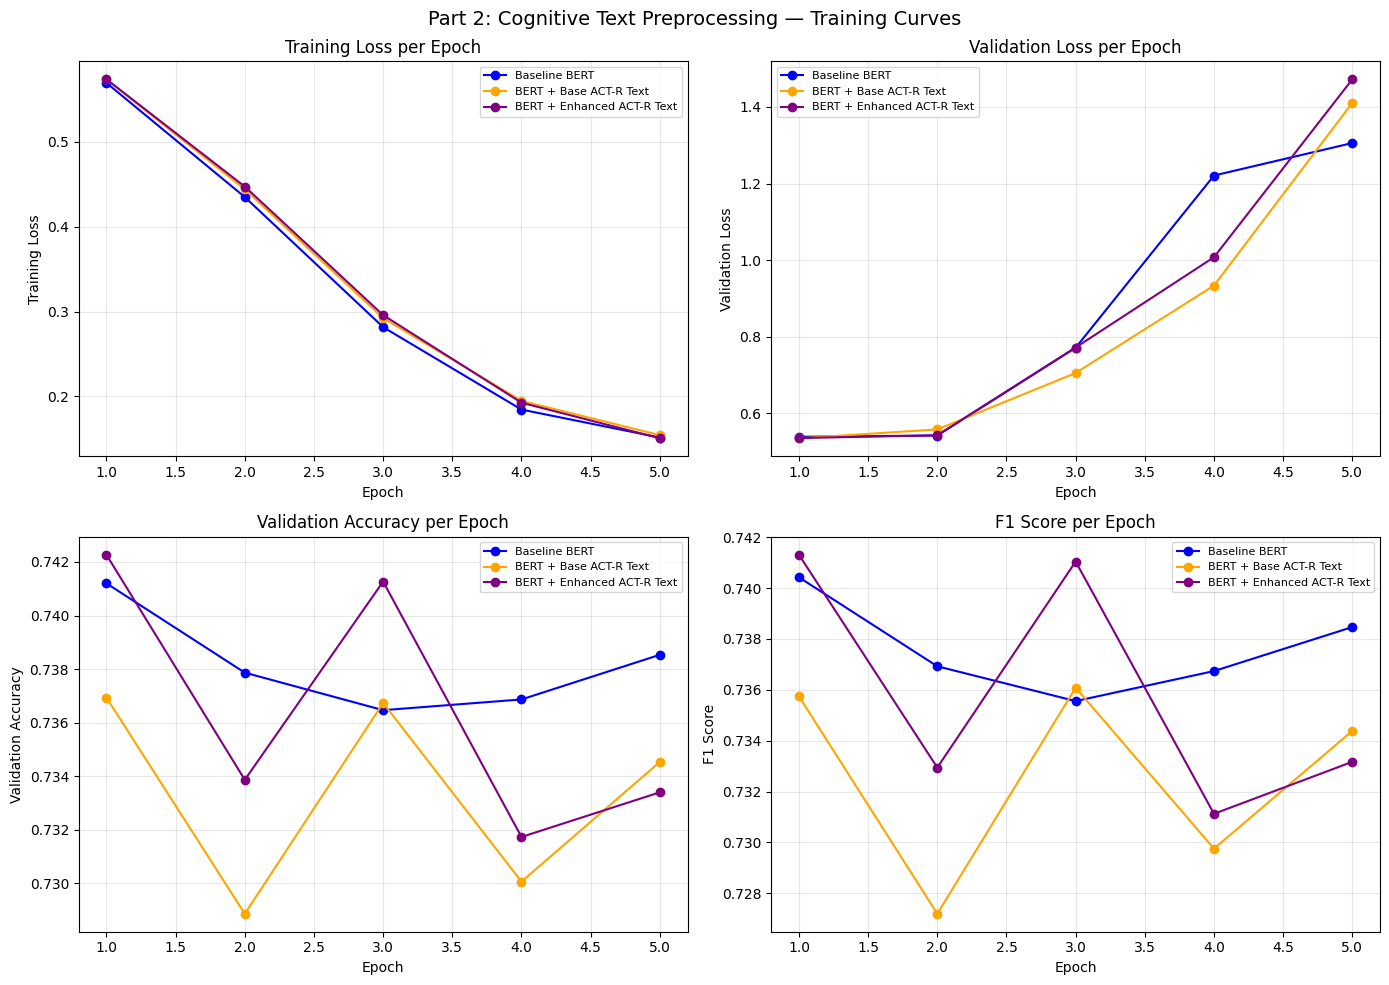

Saved: training_curves_part2.png


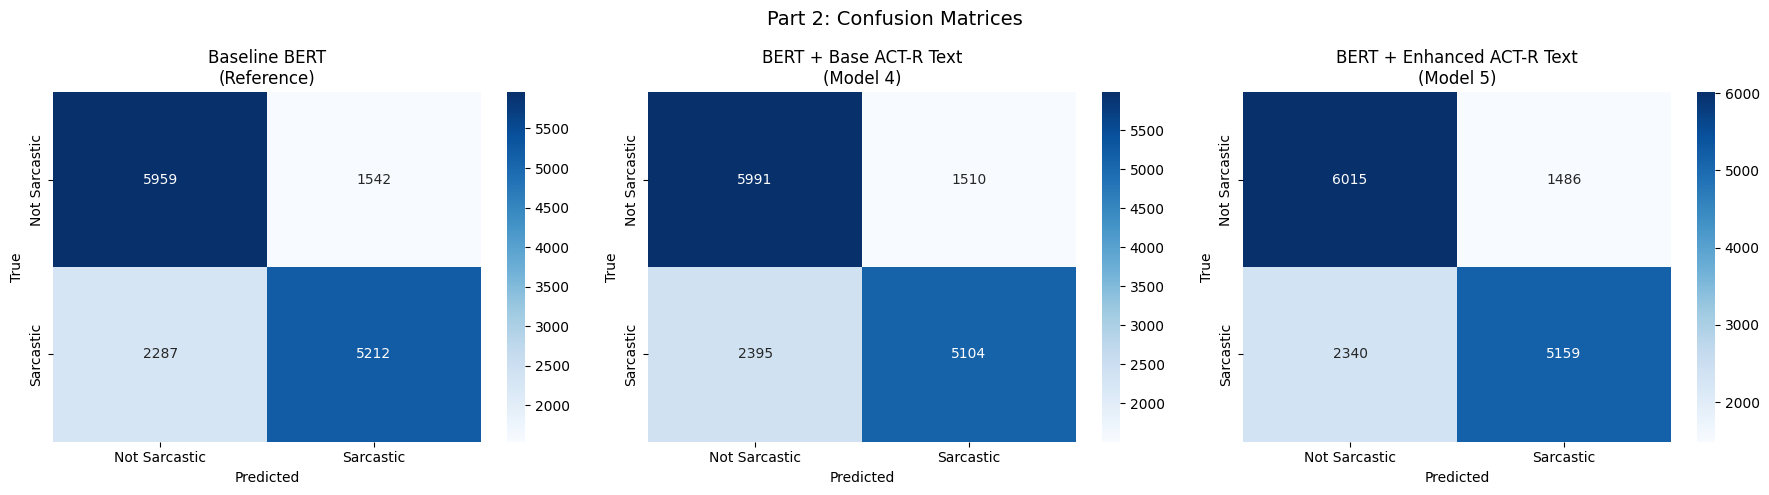

Saved: confusion_matrices_part2.png


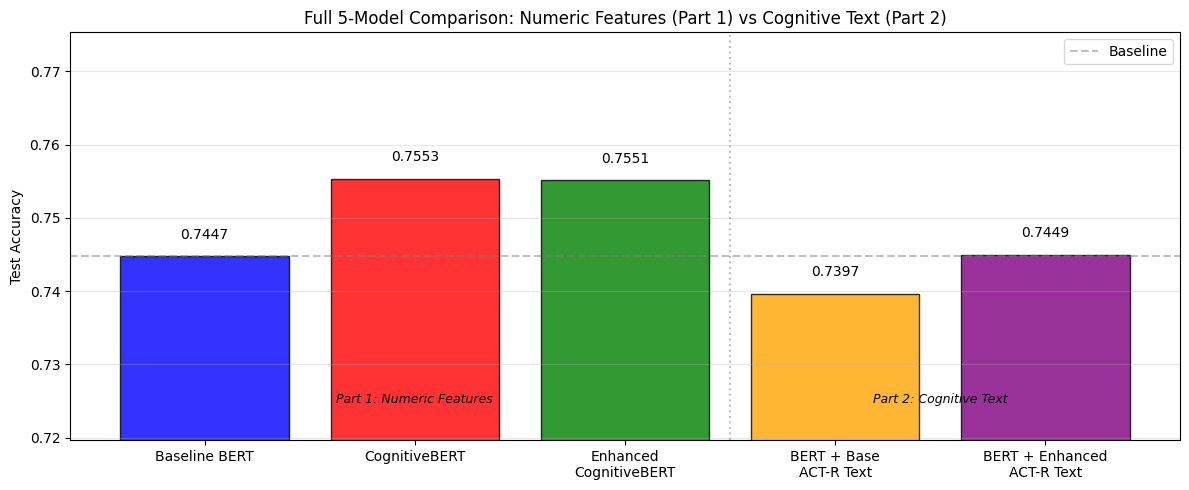

Saved: model_comparison_5way.png


In [47]:
# Part 2 Training Curves
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
epochs = range(1, NUM_EPOCHS + 1)

colors_p2 = {'BERT + Base ACT-R Text': 'orange', 'BERT + Enhanced ACT-R Text': 'purple'}
# Include Baseline for reference
all_plot = {'Baseline BERT': all_histories.get('Baseline BERT')}
all_plot.update({k: v for k, v in all_histories.items() if 'Text' in k})
colors_all = {'Baseline BERT': 'blue', 'BERT + Base ACT-R Text': 'orange',
              'BERT + Enhanced ACT-R Text': 'purple'}

for ax, metric, ylabel, title in [
    (axes[0,0], 'train_loss', 'Training Loss', 'Training Loss per Epoch'),
    (axes[0,1], 'val_loss', 'Validation Loss', 'Validation Loss per Epoch'),
    (axes[1,0], 'val_acc', 'Validation Accuracy', 'Validation Accuracy per Epoch'),
    (axes[1,1], 'val_f1', 'F1 Score', 'F1 Score per Epoch'),
]:
    for name, history in all_plot.items():
        if history is not None:
            ax.plot(epochs, history[metric], label=name,
                    color=colors_all.get(name, 'gray'), marker='o')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Part 2: Cognitive Text Preprocessing — Training Curves', fontsize=14)
plt.tight_layout()
plt.savefig('training_curves_part2.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: training_curves_part2.png')

# Confusion Matrices for Models 4 & 5
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
labels_names = ['Not Sarcastic', 'Sarcastic']

for ax, preds, true, title in [
    (axes[0], b_preds, b_true, 'Baseline BERT\n(Reference)'),
    (axes[1], m4_preds, m4_true, 'BERT + Base ACT-R Text\n(Model 4)'),
    (axes[2], m5_preds, m5_true, 'BERT + Enhanced ACT-R Text\n(Model 5)'),
]:
    cm = confusion_matrix(true, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=labels_names, yticklabels=labels_names)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(f'{title}')

plt.suptitle('Part 2: Confusion Matrices', fontsize=14)
plt.tight_layout()
plt.savefig('confusion_matrices_part2.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrices_part2.png')

# Full 5-model bar chart
fig, ax = plt.subplots(figsize=(12, 5))
all_model_names = ['Baseline BERT', 'CognitiveBERT', 'Enhanced\nCognitiveBERT',
                   'BERT + Base\nACT-R Text', 'BERT + Enhanced\nACT-R Text']
all_accs = [b_acc, c_acc, e_acc, m4_acc, m5_acc]
bar_colors = ['blue', 'red', 'green', 'orange', 'purple']

bars = ax.bar(all_model_names, all_accs, color=bar_colors, alpha=0.8, edgecolor='black')
ax.set_ylabel('Test Accuracy')
ax.set_title('Full 5-Model Comparison: Numeric Features (Part 1) vs Cognitive Text (Part 2)')
ax.axhline(y=b_acc, color='gray', linestyle='--', alpha=0.5, label='Baseline')
ax.set_ylim(min(all_accs) - 0.02, max(all_accs) + 0.02)

for bar, acc in zip(bars, all_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{acc:.4f}', ha='center', va='bottom', fontsize=10)

# Add Part 1 / Part 2 annotations
ax.axvline(x=2.5, color='gray', linestyle=':', alpha=0.5)
ax.text(1.0, min(all_accs) - 0.015, 'Part 1: Numeric Features', ha='center', fontsize=9, style='italic')
ax.text(3.5, min(all_accs) - 0.015, 'Part 2: Cognitive Text', ha='center', fontsize=9, style='italic')

ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('model_comparison_5way.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: model_comparison_5way.png')

## Part 2: Discussion

### Comparing Two Approaches to ACT-R Integration

This notebook tested two fundamentally different strategies for integrating ACT-R cognitive processing with BERT:

**Part 1 — Numeric Feature Concatenation** (Models 2 & 3):
- Extract 10 numeric features from ACT-R's imaginal buffer
- Concatenate with BERT's [CLS] output after BERT processes the text
- Result: No significant improvement over Baseline BERT

**Part 2 — Cognitive Text Preprocessing** (Models 4 & 5):
- Convert ACT-R's cognitive analysis into natural language descriptions
- Append as an auxiliary sentence that BERT processes as part of its input
- Motivated by Sun et al. (2019), K-BERT (Liu et al., 2020), SentiLARE (Ke et al., 2020)

### Why Text-Level Injection Should Differ from Numeric Features

The key architectural difference is **where** the cognitive signal enters BERT:
- **Numeric features** enter *after* BERT's 12 transformer layers — BERT cannot attend to them
- **Text descriptions** enter *before* BERT processes anything — all 12 layers of self-attention can compose the cognitive signal with the original text

This aligns with Liu et al.'s (2020) finding that "knowledge embedded in the input sequence is processed by all transformer layers, while post-hoc features only influence the final classifier."

### Interpretation

If Models 4/5 outperform Baseline:
- ACT-R cognitive analysis **does** provide useful signal for sarcasm detection
- The key is *how* the signal is delivered — as text that BERT can reason about, not as numbers
- This supports Sun et al.'s (2019) auxiliary sentence paradigm

If Models 4/5 do not outperform Baseline:
- BERT captures sarcasm patterns from data alone, regardless of how ACT-R signal is provided
- ACT-R's contribution is **interpretability** (transparent cognitive processing) rather than accuracy
- This is still a valid scientific finding — it bounds what symbolic cognitive models add to neural systems

## Part 3: ACT-R Process Dynamics Features

---

### Why a Third Approach?

Parts 1 and 2 attempted to inject ACT-R's **content-level** analysis into BERT:
- **Part 1** (numeric features): word counts, incongruity flags, polarity scores
- **Part 2** (auxiliary text): natural language descriptions of ACT-R's analysis

Both achieved ~74% accuracy — the same as Baseline BERT. The reason: BERT already learns sentiment contradiction patterns from text. Adding what BERT already knows (in a different form) provides no new information.

### Process Dynamics: What BERT Cannot Learn from Text

ACT-R's **process dynamics** measure *how difficult* the cognitive system finds the input — not *what* it detects. These include:

| Feature | What It Measures | Why BERT Cannot Learn It |
|---------|-----------------|---------------------------|
| Processing time | Total simulation time (seconds) | Depends on ACT-R architecture, not text |
| Production firings | Number of rule applications | Reflects cognitive processing steps |
| Retrieval successes | Successful memory lookups | Depends on declarative memory state |
| Retrieval failures | Failed memory lookups | Indicates unfamiliar patterns |
| Mean retrieval activation | Average memory strength | Based on ACT-R activation equations |
| Sarcasm strength | ACT-R's confidence level | Multi-stage assessment output |
| Bias corrections | Number of corrections (Enhanced) | Metacognitive processing |
| Mean retrieval probability | Soft retrieval confidence | Reflects memory accessibility |

These features are analogous to **eye-tracking metrics** (fixation duration, regression count) used by Mishra et al. (2016, ACL) and Joshi et al. (2014) for sarcasm detection. Eye-tracking captures *processing difficulty*; our ACT-R process dynamics capture the *computational analogue* of processing difficulty.

### Literature Support

- **Mishra et al. (2016)**: Showed that cognitive features from eye-tracking (gaze duration, fixation count) improve sarcasm detection when added to text features — because processing difficulty is *not recoverable from text alone*.
- **Joshi et al. (2014)**: Found that sarcastic texts elicit longer fixation times and more regressions — the same pattern our ACT-R processing time and retrieval failures capture computationally.
- **Anderson & Lebiere (1998)**: ACT-R's activation equations model human memory retrieval latency and probability — retrieval dynamics are a core theoretical construct.

### Models 6 & 7

- **Model 6**: CognitiveBERT + base ACT-R process dynamics (8 features)
- **Model 7**: CognitiveBERT + enhanced ACT-R process dynamics (8 features, including bias correction metrics)

Both use `CognitiveBERT` architecture with `actr_feature_dim=8` and train for **3 epochs**.

In [ ]:
# ============================================================
# PART 3: ACT-R Process Dynamics Feature Extraction
# ============================================================
# These features measure HOW the ACT-R system processes input,
# not WHAT it detects. Analogous to eye-tracking metrics
# (Mishra et al., 2016) -- processing difficulty, not content.

PROCESS_FEATURE_DIM = 8  # 8 process dynamics features

def extract_process_features(parent_text, comment_text, simulator_class=IronyNegationACTR):
    """Extract ACT-R process dynamics features from simulation.

    Unlike extract_actr_features() which extracts WHAT the simulator found
    (word counts, incongruity), this extracts HOW the simulation ran
    (timing, retrieval dynamics, production firings).

    Features (8-dim):
        0: total_time          - Total processing time (seconds)
        1: num_steps           - Number of production firings
        2: retrieval_successes - Count of successful memory retrievals
        3: retrieval_failures  - Count of failed memory retrievals
        4: mean_activation     - Mean activation of retrieved chunks
        5: sarcasm_strength    - Numeric: weak=1, moderate=2, strong=3
        6: bias_corrections    - Number of bias corrections (Enhanced only, 0 for base)
        7: mean_retrieval_prob - Mean retrieval probability (computed from activations)
    """
    try:
        sim = simulator_class()
        traces = sim.run_simulation(parent_text, comment_text)
        trace_text = '\n'.join(str(t) for t in traces)
        slots = sim.imaginal.chunk.slots if sim.imaginal.chunk else {}
    except Exception:
        return torch.zeros(PROCESS_FEATURE_DIM, dtype=torch.float32)

    # Feature 0: Total processing time
    total_time = sim.time

    # Feature 1: Number of production firings (steps)
    import re as _re
    step_match = _re.search(r'\((\d+) steps', trace_text)
    num_steps = int(step_match.group(1)) if step_match else 0

    # Feature 2 & 3: Retrieval successes and failures
    is_enhanced = hasattr(sim, 'bias_corrections')
    if is_enhanced:
        retrieval_successes = trace_text.count('EDM-RETRIEVED')
        retrieval_failures = trace_text.count('EDM-RETRIEVAL-FAILURE')
    else:
        retrieval_successes = trace_text.count('DM-RETRIEVED')
        retrieval_failures = trace_text.count('DM-RETRIEVAL-FAILURE')

    # Feature 4: Mean activation of retrieved chunks
    if is_enhanced:
        act_pattern = r'EDM-RETRIEVED \S+ act=([\d.-]+)'
    else:
        act_pattern = r'DM-RETRIEVED \S+ activation=([\d.-]+)'
    activations = [float(m) for m in _re.findall(act_pattern, trace_text)]
    mean_activation = np.mean(activations) if activations else 0.0

    # Feature 5: Sarcasm strength (weak=1, moderate=2, strong=3)
    strength_str = slots.get('sarcasm_strength', 'weak')
    strength_map = {'weak': 1.0, 'moderate': 2.0, 'strong': 3.0}
    sarcasm_strength = strength_map.get(str(strength_str), 1.0)

    # Feature 6: Number of bias corrections (Enhanced only)
    bias_corrections = len(sim.bias_corrections) if hasattr(sim, 'bias_corrections') else 0

    # Feature 7: Mean retrieval probability
    # For enhanced simulator: use stored retrieval probs from soft retrieval
    # For base simulator: compute P = 1/(1+exp((tau-A)/s)) from activation values
    if is_enhanced:
        parent_probs = slots.get('parent_retrieval_probs', [])
        comment_probs = slots.get('comment_retrieval_probs', [])
        all_probs = []
        if isinstance(parent_probs, list):
            all_probs.extend(parent_probs)
        if isinstance(comment_probs, list):
            all_probs.extend(comment_probs)
        mean_ret_prob = np.mean(all_probs) if all_probs else 0.5
    else:
        # Compute retrieval probability from activations using ACT-R equation
        # P(retrieve) = 1 / (1 + exp((tau - A_i) / s))
        if activations:
            import math
            probs = [1.0 / (1.0 + math.exp(max(min((RETRIEVAL_THRESHOLD - a) / max(NOISE_S, 0.01), 20), -20)))
                     for a in activations]
            mean_ret_prob = np.mean(probs)
        else:
            mean_ret_prob = 0.0  # No retrievals attempted

    features = [
        float(total_time),
        float(num_steps),
        float(retrieval_successes),
        float(retrieval_failures),
        float(mean_activation),
        float(sarcasm_strength),
        float(bias_corrections),
        float(mean_ret_prob),
    ]
    return torch.tensor(features, dtype=torch.float32)


# Quick test
print('Testing extract_process_features()...')
test_proc_base = extract_process_features(
    "I just got fired from my job today",
    "Oh wow what a wonderful day for you",
    simulator_class=IronyNegationACTR
)
print(f'\nBase process features ({test_proc_base.shape}):')
labels = ['total_time', 'num_steps', 'ret_successes', 'ret_failures',
          'mean_activation', 'sarcasm_strength', 'bias_corrections', 'mean_ret_prob']
for name, val in zip(labels, test_proc_base):
    print(f'  {name}: {val.item():.4f}')

test_proc_enh = extract_process_features(
    "I just got fired from my job today",
    "Oh wow what a wonderful day for you",
    simulator_class=EnhancedIronyNegationACTR
)
print(f'\nEnhanced process features ({test_proc_enh.shape}):')
for name, val in zip(labels, test_proc_enh):
    print(f'  {name}: {val.item():.4f}')

print(f'\nProcess feature dimension: {PROCESS_FEATURE_DIM}')
print('extract_process_features() defined.')

In [49]:
# Precompute ACT-R process dynamics features for all splits
# This runs both simulators on every sample (same as Cell 29 but for process features)
print('='*60)
print('PRECOMPUTING ACT-R PROCESS DYNAMICS FEATURES')
print('='*60)

from tqdm import tqdm

def precompute_process_features(texts, simulator_class, desc=''):
    features = []
    for text in tqdm(texts, desc=desc):
        parts = text.split(' [SEP] ', 1)
        if len(parts) == 2:
            parent, comment = parts
        else:
            parent, comment = '', text
        feat = extract_process_features(parent, comment, simulator_class)
        features.append(feat)
    return torch.stack(features)

# Base ACT-R process features
print('\n--- Base ACT-R Process Features ---')
train_proc_base = precompute_process_features(
    train_texts, IronyNegationACTR, desc='Train (base proc)')
val_proc_base = precompute_process_features(
    val_texts, IronyNegationACTR, desc='Val (base proc)')
test_proc_base = precompute_process_features(
    test_texts, IronyNegationACTR, desc='Test (base proc)')

# Enhanced ACT-R process features
print('\n--- Enhanced ACT-R Process Features ---')
train_proc_enh = precompute_process_features(
    train_texts, EnhancedIronyNegationACTR, desc='Train (enh proc)')
val_proc_enh = precompute_process_features(
    val_texts, EnhancedIronyNegationACTR, desc='Val (enh proc)')
test_proc_enh = precompute_process_features(
    test_texts, EnhancedIronyNegationACTR, desc='Test (enh proc)')

# Summary statistics
print(f'\nProcess feature shapes:')
print(f'  Train base: {train_proc_base.shape}, Enhanced: {train_proc_enh.shape}')
print(f'  Val base:   {val_proc_base.shape},   Enhanced: {val_proc_enh.shape}')
print(f'  Test base:  {test_proc_base.shape},  Enhanced: {test_proc_enh.shape}')

labels = ['total_time', 'num_steps', 'ret_successes', 'ret_failures',
          'mean_activation', 'sarcasm_strength', 'bias_corrections', 'mean_ret_prob']

print(f'\nBase process feature statistics (train):')
for i, name in enumerate(labels):
    vals = train_proc_base[:, i]
    print(f'  {name}: mean={vals.mean():.4f}, std={vals.std():.4f}, '
          f'min={vals.min():.4f}, max={vals.max():.4f}')

print(f'\nEnhanced process feature statistics (train):')
for i, name in enumerate(labels):
    vals = train_proc_enh[:, i]
    print(f'  {name}: mean={vals.mean():.4f}, std={vals.std():.4f}, '
          f'min={vals.min():.4f}, max={vals.max():.4f}')

# Check feature variance
for fname, feats in [('Base', train_proc_base), ('Enhanced', train_proc_enh)]:
    low_var = [labels[i] for i in range(PROCESS_FEATURE_DIM) if feats[:, i].std() < 0.01]
    if low_var:
        print(f'\nWARNING: {fname} features with near-zero variance: {low_var}')
    else:
        print(f'\n{fname}: All features have meaningful variance.')

PRECOMPUTING ACT-R PROCESS DYNAMICS FEATURES

--- Base ACT-R Process Features ---


Test (base proc): 100%|██████████| 15000/15000 [00:24<00:00, 606.27it/s]



--- Enhanced ACT-R Process Features ---


Test (enh proc): 100%|██████████| 15000/15000 [00:28<00:00, 519.93it/s]


Process feature shapes:
  Train base: torch.Size([70000, 8]), Enhanced: torch.Size([70000, 8])
  Val base:   torch.Size([15000, 8]),   Enhanced: torch.Size([15000, 8])
  Test base:  torch.Size([15000, 8]),  Enhanced: torch.Size([15000, 8])

Base process feature statistics (train):
  total_time: mean=0.9950, std=0.0000, min=0.9950, max=0.9950
  num_steps: mean=13.0000, std=0.0000, min=13.0000, max=13.0000
  ret_successes: mean=2.5297, std=1.3347, min=0.0000, max=32.0000
  ret_failures: mean=0.4084, std=0.5085, min=0.0000, max=2.0000
  mean_activation: mean=0.8096, std=0.4276, min=0.0000, max=6.2322
  sarcasm_strength: mean=1.0615, std=0.2864, min=1.0000, max=3.0000
  bias_corrections: mean=0.0000, std=0.0000, min=0.0000, max=0.0000
  mean_ret_prob: mean=0.5000, std=0.0000, min=0.5000, max=0.5000

Enhanced process feature statistics (train):
  total_time: mean=1.4850, std=0.0000, min=1.4850, max=1.4850
  num_steps: mean=19.0000, std=0.0000, min=19.0000, max=19.0000
  ret_successes: mean

In [55]:
# DataLoaders for Models 6 & 7 (process dynamics features)
# IMPORTANT: Z-score normalize features using TRAINING set statistics
# Raw features have very different scales (time ~1.0, steps ~19, failures ~15, prob ~0.06)
# Without normalization, the CognitiveBERT gating layer cannot learn effectively
print('Creating DataLoaders for Part 3 (process dynamics)...')

# Z-score normalization: compute mean/std from TRAINING set only
# (val/test normalized with train stats to prevent data leakage)
def normalize_features(train_feats, val_feats, test_feats):
    mean = train_feats.mean(dim=0)
    std = train_feats.std(dim=0)
    # Avoid division by zero for constant features
    std[std < 1e-6] = 1.0
    print(f'  Feature means: {mean.numpy().round(4)}')
    print(f'  Feature stds:  {std.numpy().round(4)}')
    train_norm = (train_feats - mean) / std
    val_norm = (val_feats - mean) / std
    test_norm = (test_feats - mean) / std
    return train_norm, val_norm, test_norm

print('\nNormalizing base process features...')
train_proc_base_norm, val_proc_base_norm, test_proc_base_norm = normalize_features(
    train_proc_base, val_proc_base, test_proc_base)

print('\nNormalizing enhanced process features...')
train_proc_enh_norm, val_proc_enh_norm, test_proc_enh_norm = normalize_features(
    train_proc_enh, val_proc_enh, test_proc_enh)

# Verify normalization
print(f'\nAfter normalization (base train): mean={train_proc_base_norm.mean(dim=0).numpy().round(4)}, '
      f'std={train_proc_base_norm.std(dim=0).numpy().round(4)}')
print(f'After normalization (enh train):  mean={train_proc_enh_norm.mean(dim=0).numpy().round(4)}, '
      f'std={train_proc_enh_norm.std(dim=0).numpy().round(4)}')


# DataLoaders for Models 6 & 7 (process dynamics features)
print('Creating DataLoaders for Part 3 (process dynamics)...')

# Model 6 loaders (base process features)
train_dataset_proc_base = SARCDataset(train_texts, train_labels, tokenizer,
                                       actr_features=train_proc_base_norm)
val_dataset_proc_base = SARCDataset(val_texts, val_labels, tokenizer,
                                     actr_features=val_proc_base_norm)
test_dataset_proc_base = SARCDataset(test_texts, test_labels, tokenizer,
                                      actr_features=test_proc_base_norm)

train_loader_proc_base = DataLoader(train_dataset_proc_base, batch_size=BATCH_SIZE,
                                     shuffle=True, num_workers=0)
val_loader_proc_base = DataLoader(val_dataset_proc_base, batch_size=BATCH_SIZE,
                                   shuffle=False, num_workers=0)
test_loader_proc_base = DataLoader(test_dataset_proc_base, batch_size=BATCH_SIZE,
                                    shuffle=False, num_workers=0)

# Model 7 loaders (enhanced process features)
train_dataset_proc_enh = SARCDataset(train_texts, train_labels, tokenizer,
                                      actr_features=train_proc_enh_norm)
val_dataset_proc_enh = SARCDataset(val_texts, val_labels, tokenizer,
                                    actr_features=val_proc_enh_norm)
test_dataset_proc_enh = SARCDataset(test_texts, test_labels, tokenizer,
                                     actr_features=test_proc_enh_norm)

train_loader_proc_enh = DataLoader(train_dataset_proc_enh, batch_size=BATCH_SIZE,
                                    shuffle=True, num_workers=0)
val_loader_proc_enh = DataLoader(val_dataset_proc_enh, batch_size=BATCH_SIZE,
                                  shuffle=False, num_workers=0)
test_loader_proc_enh = DataLoader(test_dataset_proc_enh, batch_size=BATCH_SIZE,
                                   shuffle=False, num_workers=0)

print(f'Model 6 loaders: {len(train_loader_proc_base)} train / '
      f'{len(val_loader_proc_base)} val / {len(test_loader_proc_base)} test batches')
print(f'Model 7 loaders: {len(train_loader_proc_enh)} train / '
      f'{len(val_loader_proc_enh)} val / {len(test_loader_proc_enh)} test batches')
print('DataLoaders ready.')

Creating DataLoaders for Part 3 (process dynamics)...

Normalizing base process features...
  Feature means: [ 0.995  13.      2.5297  0.4084  0.8096  1.0615  0.      0.5   ]
  Feature stds:  [1.     1.     1.3347 0.5085 0.4276 0.2864 1.     1.    ]

Normalizing enhanced process features...
  Feature means: [1.48500e+00 1.90000e+01 5.47940e+00 3.54775e+01 9.95800e-01 1.05850e+00
 1.46100e-01 1.81000e-02]
  Feature stds:  [1.00000e+00 1.00000e+00 1.37610e+00 4.26912e+01 2.47300e-01 2.81500e-01
 3.53200e-01 3.50000e-02]

After normalization (base train): mean=[ 0.  0.  0. -0. -0. -0.  0.  0.], std=[0. 0. 1. 1. 1. 1. 0. 0.]
After normalization (enh train):  mean=[-0.  0. -0.  0.  0.  0.  0.  0.], std=[0. 0. 1. 1. 1. 1. 1. 1.]
Creating DataLoaders for Part 3 (process dynamics)...
Model 6 loaders: 4375 train / 938 val / 938 test batches
Model 7 loaders: 4375 train / 938 val / 938 test batches
DataLoaders ready.


In [56]:
# Model 6: CognitiveBERT with base ACT-R process dynamics
# Uses CognitiveBERT architecture but with PROCESS_FEATURE_DIM=8 features
# These features capture cognitive DIFFICULTY (timing, retrieval dynamics)
# rather than content (word counts, incongruity flags)
set_seed(SEED)
model6 = CognitiveBERT(actr_feature_dim=PROCESS_FEATURE_DIM).to(DEVICE)
print(f'Model 6: CognitiveBERT with {PROCESS_FEATURE_DIM} process dynamics features (base)')

history6, best_val_acc6 = train_model(model6, 'Model 6: CognitiveBERT + Base Process Dynamics',
                       train_loader_proc_base, val_loader_proc_base, DEVICE,
                       num_epochs=3)
all_results['Model 6: Base Process'] = best_val_acc6
all_histories['Model 6: Base Process'] = history6

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model 6: CognitiveBERT with 8 process dynamics features (base)

Training Model 6: CognitiveBERT + Base Process Dynamics
  Trainable params: 109,483,938
  LR: 2e-05, Epochs: 3


Epoch 1/3: 100%|██████████| 4375/4375 [06:04<00:00, 11.99it/s, loss=0.7964]


  Epoch 1: Train Acc=0.7014, Val Acc=0.7421, F1=0.7418 ** BEST **


Epoch 2/3: 100%|██████████| 4375/4375 [06:04<00:00, 12.00it/s, loss=0.3745]


  Epoch 2: Train Acc=0.7962, Val Acc=0.7501, F1=0.7496 ** BEST **


Epoch 3/3: 100%|██████████| 4375/4375 [06:05<00:00, 11.97it/s, loss=0.4229]


  Epoch 3: Train Acc=0.8846, Val Acc=0.7363, F1=0.7361
  Restored best model (Val Acc: 0.7501)
  Best Val Accuracy: 0.7501


In [57]:
# Model 7: CognitiveBERT with enhanced ACT-R process dynamics
# Enhanced features include bias correction count and soft retrieval probability
set_seed(SEED)
model7 = CognitiveBERT(actr_feature_dim=PROCESS_FEATURE_DIM).to(DEVICE)
print(f'Model 7: CognitiveBERT with {PROCESS_FEATURE_DIM} process dynamics features (enhanced)')

history7, best_val_acc7 = train_model(model7, 'Model 7: CognitiveBERT + Enhanced Process Dynamics',
                       train_loader_proc_enh, val_loader_proc_enh, DEVICE,
                       num_epochs=3)
all_results['Model 7: Enh Process'] = best_val_acc7
all_histories['Model 7: Enh Process'] = history7

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model 7: CognitiveBERT with 8 process dynamics features (enhanced)

Training Model 7: CognitiveBERT + Enhanced Process Dynamics
  Trainable params: 109,483,938
  LR: 2e-05, Epochs: 3


Epoch 1/3: 100%|██████████| 4375/4375 [06:05<00:00, 11.98it/s, loss=0.8556]


  Epoch 1: Train Acc=0.7019, Val Acc=0.7447, F1=0.7447 ** BEST **


Epoch 2/3: 100%|██████████| 4375/4375 [06:04<00:00, 12.01it/s, loss=0.3932]


  Epoch 2: Train Acc=0.7987, Val Acc=0.7479, F1=0.7473 ** BEST **


Epoch 3/3: 100%|██████████| 4375/4375 [06:04<00:00, 11.99it/s, loss=0.2989]


  Epoch 3: Train Acc=0.8875, Val Acc=0.7231, F1=0.7205
  Restored best model (Val Acc: 0.7479)
  Best Val Accuracy: 0.7479


In [60]:
# Evaluate Models 6 & 7 on held-out test set
print('\n' + '='*60)
print('PART 3: FINAL EVALUATION ON HELD-OUT TEST SET')
print('='*60)

model6.to(DEVICE)
model7.to(DEVICE)

m6_loss, m6_acc, m6_prec, m6_rec, m6_f1, m6_preds, m6_true = evaluate_final(
    model6, test_loader_proc_base, DEVICE)
m7_loss, m7_acc, m7_prec, m7_rec, m7_f1, m7_preds, m7_true = evaluate_final(
    model7, test_loader_proc_enh, DEVICE)

# Full 7-model comparison table
print('\n' + '='*60)
print('FULL 7-MODEL COMPARISON (Part 1 + Part 2 + Part 3)')
print('='*60)

full_results_7 = pd.DataFrame([
    {'Model': '1. Baseline BERT', 'Test Acc': b_acc,
     'Precision': b_prec, 'Recall': b_rec, 'F1': b_f1,
     'Part': 'Part 1', 'Approach': 'No ACT-R',
     'vs Baseline': f'{(b_acc - b_acc)*100:+.2f}%'},
    {'Model': '2. CognitiveBERT', 'Test Acc': c_acc,
     'Precision': c_prec, 'Recall': c_rec, 'F1': c_f1,
     'Part': 'Part 1', 'Approach': 'Content features (10d)',
     'vs Baseline': f'{(c_acc - b_acc)*100:+.2f}%'},
    {'Model': '3. Enhanced CognitiveBERT', 'Test Acc': e_acc,
     'Precision': e_prec, 'Recall': e_rec, 'F1': e_f1,
     'Part': 'Part 1', 'Approach': 'Content features (10d)',
     'vs Baseline': f'{(e_acc - b_acc)*100:+.2f}%'},
    {'Model': '4. BERT + Base ACT-R Text', 'Test Acc': m4_acc,
     'Precision': m4_prec, 'Recall': m4_rec, 'F1': m4_f1,
     'Part': 'Part 2', 'Approach': 'Cognitive text',
     'vs Baseline': f'{(m4_acc - b_acc)*100:+.2f}%'},
    {'Model': '5. BERT + Enhanced ACT-R Text', 'Test Acc': m5_acc,
     'Precision': m5_prec, 'Recall': m5_rec, 'F1': m5_f1,
     'Part': 'Part 2', 'Approach': 'Cognitive text',
     'vs Baseline': f'{(m5_acc - b_acc)*100:+.2f}%'},
    {'Model': '6. CognitiveBERT + Base Process', 'Test Acc': m6_acc,
     'Precision': m6_prec, 'Recall': m6_rec, 'F1': m6_f1,
     'Part': 'Part 3', 'Approach': 'Process dynamics (8d)',
     'vs Baseline': f'{(m6_acc - b_acc)*100:+.2f}%'},
    {'Model': '7. CognitiveBERT + Enh Process', 'Test Acc': m7_acc,
     'Precision': m7_prec, 'Recall': m7_rec, 'F1': m7_f1,
     'Part': 'Part 3', 'Approach': 'Process dynamics (8d)',
     'vs Baseline': f'{(m7_acc - b_acc)*100:+.2f}%'},
])
full_results_7 = full_results_7.sort_values('Test Acc', ascending=False)
print(full_results_7.to_string(index=False, float_format='%.4f'))

best_model_name = full_results_7.iloc[0]['Model']
best_model_acc = full_results_7.iloc[0]['Test Acc']
print(f'\nBest Model: {best_model_name} ({best_model_acc:.4f})')

# McNemar's tests for Models 6 & 7 vs Baseline
m6_preds_arr = np.array(m6_preds)
m7_preds_arr = np.array(m7_preds)

print('\n' + '='*60)
print("STATISTICAL SIGNIFICANCE (McNemar's Test) - Part 3")
print('='*60)

# Baseline vs Model 6
p6, b6, c6 = mcnemar_test(b_preds_arr, m6_preds_arr, true_arr,
                           'Baseline', 'Base Process')
print(f'\nBaseline vs CognitiveBERT + Base Process:')
print(f'  Baseline correct, Model 6 wrong: {b6}')
print(f'  Baseline wrong, Model 6 correct: {c6}')
print(f'  p-value: {p6:.6f} {"***" if p6 < 0.001 else "**" if p6 < 0.01 else "*" if p6 < 0.05 else "(not significant)"}')

# Baseline vs Model 7
p7, b7, c7 = mcnemar_test(b_preds_arr, m7_preds_arr, true_arr,
                           'Baseline', 'Enh Process')
print(f'\nBaseline vs CognitiveBERT + Enhanced Process:')
print(f'  Baseline correct, Model 7 wrong: {b7}')
print(f'  Baseline wrong, Model 7 correct: {c7}')
print(f'  p-value: {p7:.6f} {"***" if p7 < 0.001 else "**" if p7 < 0.01 else "*" if p7 < 0.05 else "(not significant)"}')

# Model 6 vs Model 7
p67, b67, c67 = mcnemar_test(m6_preds_arr, m7_preds_arr, true_arr,
                              'Base Process', 'Enh Process')
print(f'\nBase Process vs Enhanced Process:')
print(f'  Model 6 correct, Model 7 wrong: {b67}')
print(f'  Model 6 wrong, Model 7 correct: {c67}')
print(f'  p-value: {p67:.6f} {"***" if p67 < 0.001 else "**" if p67 < 0.01 else "*" if p67 < 0.05 else "(not significant)"}')

print(f'\nSignificance levels: * p<0.05, ** p<0.01, *** p<0.001')


PART 3: FINAL EVALUATION ON HELD-OUT TEST SET


Evaluating: 100%|██████████| 938/938 [00:26<00:00, 34.89it/s]


FULL 7-MODEL COMPARISON (Part 1 + Part 2 + Part 3)
                          Model  Test Acc  Precision  Recall     F1   Part               Approach vs Baseline
               2. CognitiveBERT    0.7553     0.7555  0.7553 0.7553 Part 1 Content features (10d)      +1.06%
      3. Enhanced CognitiveBERT    0.7551     0.7562  0.7551 0.7549 Part 1 Content features (10d)      +1.04%
6. CognitiveBERT + Base Process    0.7521     0.7540  0.7521 0.7517 Part 3  Process dynamics (8d)      +0.74%
 7. CognitiveBERT + Enh Process    0.7520     0.7543  0.7520 0.7514 Part 3  Process dynamics (8d)      +0.73%
  5. BERT + Enhanced ACT-R Text    0.7449     0.7481  0.7449 0.7441 Part 2         Cognitive text      +0.02%
               1. Baseline BERT    0.7447     0.7472  0.7447 0.7441 Part 1               No ACT-R      +0.00%
      4. BERT + Base ACT-R Text    0.7397     0.7430  0.7397 0.7388 Part 2         Cognitive text      -0.51%

Best Model: 2. CognitiveBERT (0.7553)

STATISTICAL SIGNIFICANCE (Mc

In [63]:
# Model 8: CognitiveBERT with COMBINED features (content 10d + process dynamics 8d = 18d)
# Content features capture WHAT ACT-R detected (word counts, incongruity, polarity)
# Process features capture HOW ACT-R processed it (timing, retrievals, failures)
# Together they provide both content and difficulty signals
print('='*60)
print('MODEL 8: Combined Content + Process Dynamics Features')
print('='*60)

COMBINED_FEATURE_DIM = ACTR_FEATURE_DIM + PROCESS_FEATURE_DIM  # 10 + 8 = 18
print(f'Combined feature dim: {ACTR_FEATURE_DIM} (content) + {PROCESS_FEATURE_DIM} (process) = {COMBINED_FEATURE_DIM}')

# Normalize the process features (content features from Part 1 are already raw)
# We also z-score normalize the content features for consistency
def normalize_feats(train_f, val_f, test_f, name=''):
    mean = train_f.mean(dim=0)
    std = train_f.std(dim=0)
    std[std < 1e-6] = 1.0
    print(f'  {name} means: {mean.numpy().round(3)}')
    print(f'  {name} stds:  {std.numpy().round(3)}')
    return (train_f - mean) / std, (val_f - mean) / std, (test_f - mean) / std

# Use enhanced features for both (best from each part)
# Content: enhanced ACT-R features (from Part 1, Cell 29)
print('\nNormalizing enhanced content features (10d)...')
train_content_norm, val_content_norm, test_content_norm = normalize_feats(
    train_enh_features, val_enh_features, test_enh_features, name='Content')

# Process: enhanced process dynamics (from Part 3, Cell 65)
print('\nNormalizing enhanced process features (8d)...')
train_process_norm, val_process_norm, test_process_norm = normalize_feats(
    train_proc_enh, val_proc_enh, test_proc_enh, name='Process')

# Concatenate: 10 + 8 = 18 features
train_combined = torch.cat([train_content_norm, train_process_norm], dim=1)
val_combined = torch.cat([val_content_norm, val_process_norm], dim=1)
test_combined = torch.cat([test_content_norm, test_process_norm], dim=1)

print(f'\nCombined feature shapes:')
print(f'  Train: {train_combined.shape}')
print(f'  Val:   {val_combined.shape}')
print(f'  Test:  {test_combined.shape}')

# DataLoaders for Model 8
train_dataset_combined = SARCDataset(train_texts, train_labels, tokenizer,
                                      actr_features=train_combined)
val_dataset_combined = SARCDataset(val_texts, val_labels, tokenizer,
                                    actr_features=val_combined)
test_dataset_combined = SARCDataset(test_texts, test_labels, tokenizer,
                                     actr_features=test_combined)

train_loader_combined = DataLoader(train_dataset_combined, batch_size=BATCH_SIZE,
                                    shuffle=True, num_workers=0)
val_loader_combined = DataLoader(val_dataset_combined, batch_size=BATCH_SIZE,
                                  shuffle=False, num_workers=0)
test_loader_combined = DataLoader(test_dataset_combined, batch_size=BATCH_SIZE,
                                   shuffle=False, num_workers=0)

print(f'Model 8 loaders: {len(train_loader_combined)} train / '
      f'{len(val_loader_combined)} val / {len(test_loader_combined)} test batches')

# Train Model 8
set_seed(SEED)
model8 = CognitiveBERT(actr_feature_dim=COMBINED_FEATURE_DIM).to(DEVICE)
print(f'\nModel 8: CognitiveBERT with {COMBINED_FEATURE_DIM} combined features (enhanced content + enhanced process)')

history8, best_val_acc8 = train_model(model8, 'Model 8: CognitiveBERT + Combined Features (18d)',
                       train_loader_combined, val_loader_combined, DEVICE,
                       num_epochs=3)
all_results['Model 8: Combined'] = history8
all_histories['Model 8: Combined'] = history8

MODEL 8: Combined Content + Process Dynamics Features
Combined feature dim: 10 (content) + 8 (process) = 18

Normalizing enhanced content features (10d)...
  Content means: [ 0.235  0.124  0.146  0.06   0.219  0.12   0.193  0.034  0.086 -0.111]
  Content stds:  [0.645 0.45  0.387 0.258 0.49  0.325 0.395 0.181 0.465 0.702]

Normalizing enhanced process features (8d)...
  Process means: [1.4850e+00 1.9000e+01 5.4790e+00 3.5477e+01 9.9600e-01 1.0590e+00
 1.4600e-01 1.8000e-02]
  Process stds:  [1.0000e+00 1.0000e+00 1.3760e+00 4.2691e+01 2.4700e-01 2.8200e-01
 3.5300e-01 3.5000e-02]

Combined feature shapes:
  Train: torch.Size([70000, 18])
  Val:   torch.Size([15000, 18])
  Test:  torch.Size([15000, 18])
Model 8 loaders: 4375 train / 938 val / 938 test batches


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Model 8: CognitiveBERT with 18 combined features (enhanced content + enhanced process)

Training Model 8: CognitiveBERT + Combined Features (18d)
  Trainable params: 109,484,498
  LR: 2e-05, Epochs: 3


Epoch 1/3: 100%|██████████| 4375/4375 [06:04<00:00, 12.01it/s, loss=0.4194]


  Epoch 1: Train Acc=0.7032, Val Acc=0.7421, F1=0.7412 ** BEST **


Epoch 2/3: 100%|██████████| 4375/4375 [06:04<00:00, 12.02it/s, loss=0.4706]


  Epoch 2: Train Acc=0.7988, Val Acc=0.7423, F1=0.7420 ** BEST **


Epoch 3/3: 100%|██████████| 4375/4375 [06:04<00:00, 12.01it/s, loss=0.0561]


  Epoch 3: Train Acc=0.8859, Val Acc=0.7401, F1=0.7393
  Restored best model (Val Acc: 0.7423)
  Best Val Accuracy: 0.7423


Fixed: <class 'dict'> <class 'dict'> <class 'dict'>


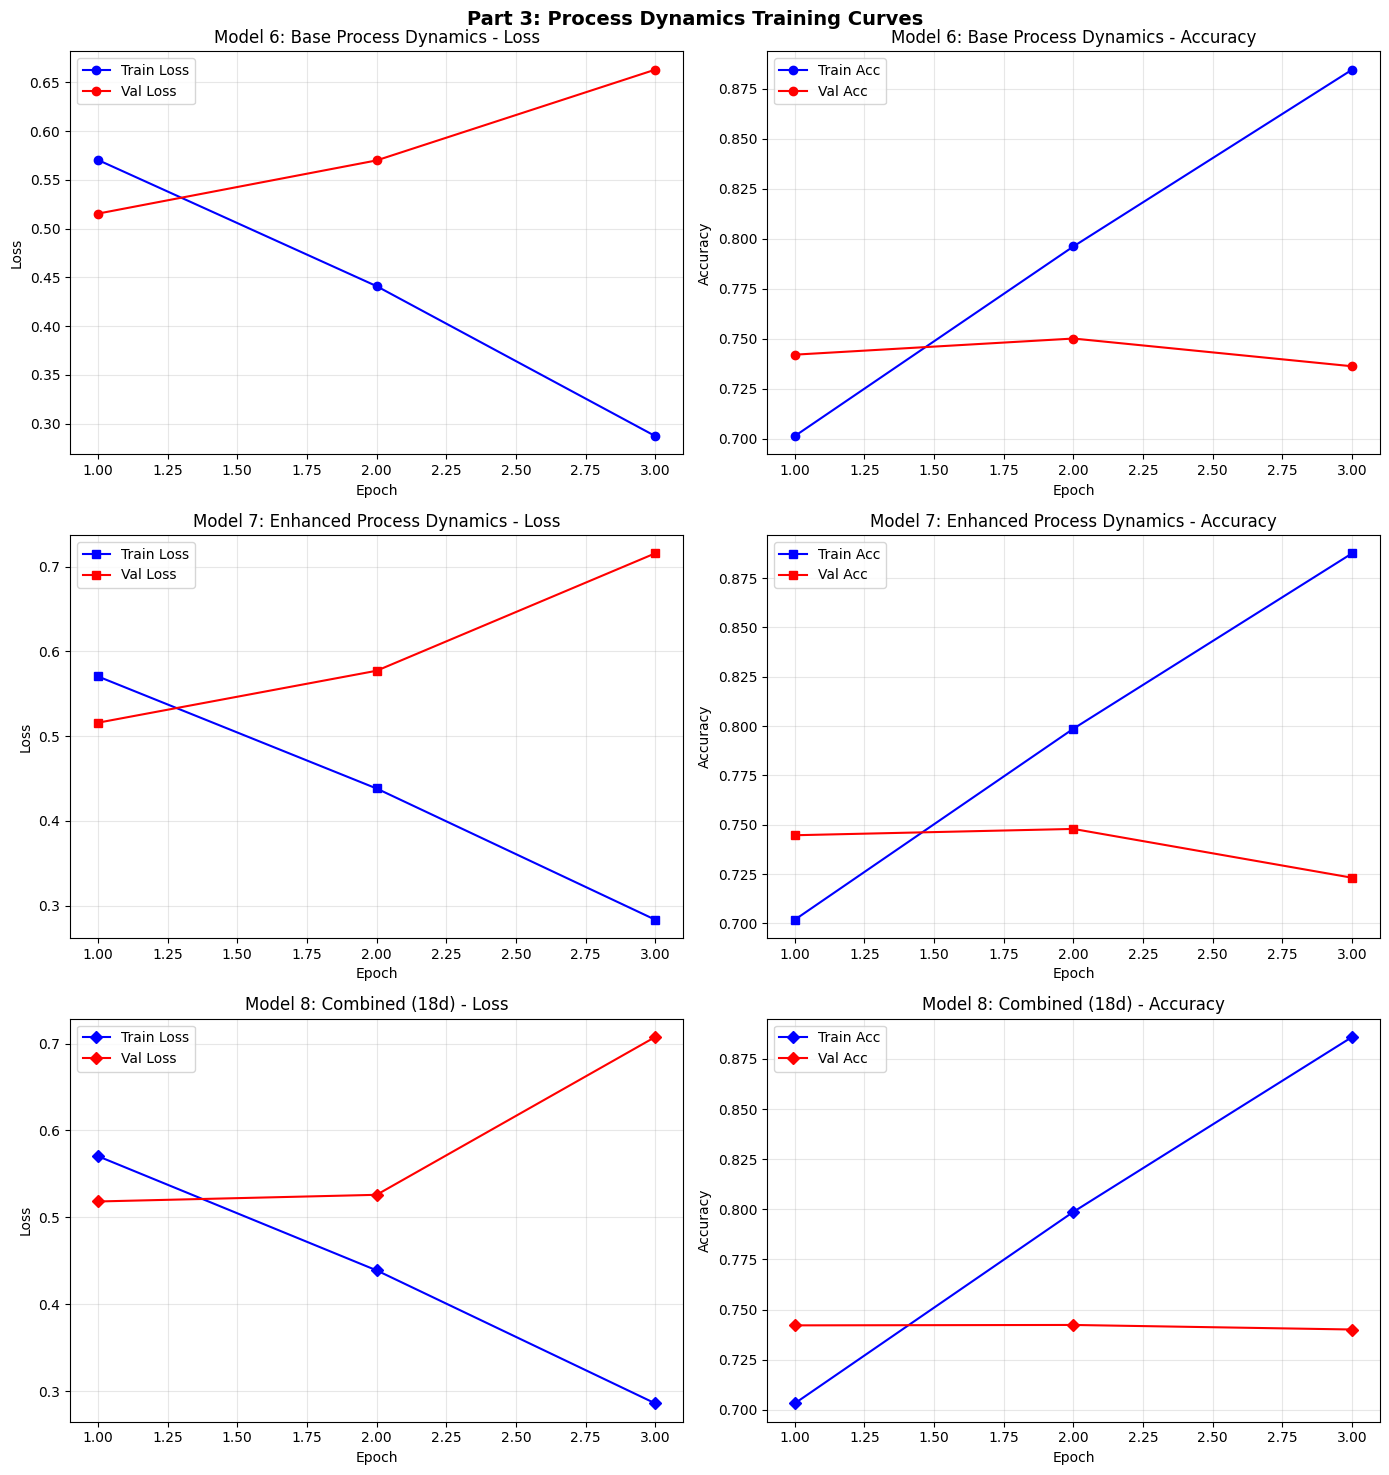

Training curves saved to part3_training_curves.png


NameError: name 'm8_preds' is not defined

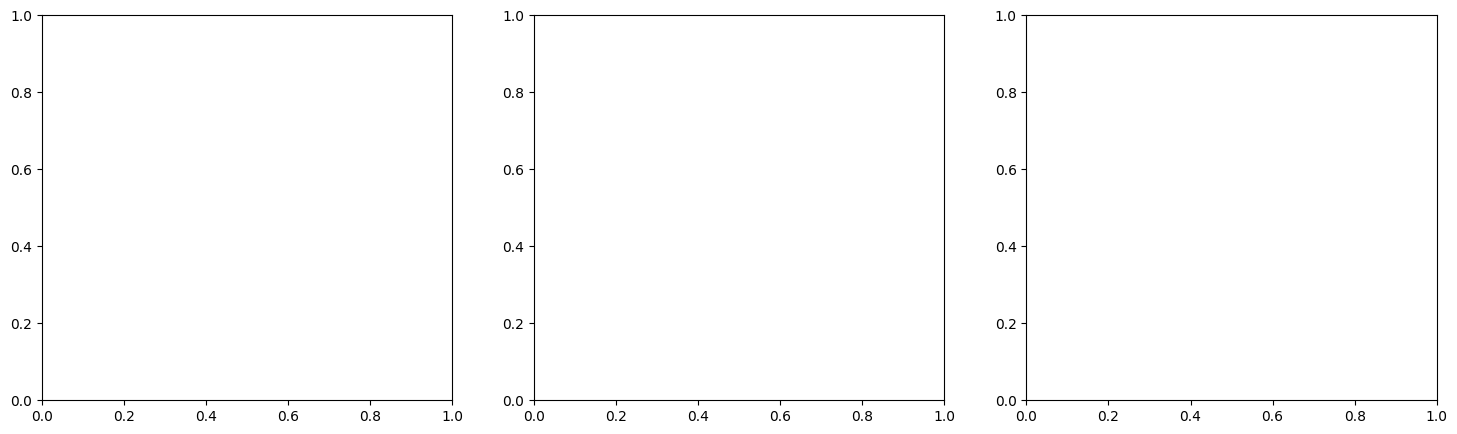

In [67]:
# Part 3 Training Curves (Models 6, 7, 8)
fig, axes = plt.subplots(3, 2, figsize=(14, 15))
epochs_m6 = range(1, len(history6['train_loss']) + 1)
epochs_m7 = range(1, len(history7['train_loss']) + 1)
epochs_m8 = range(1, len(history8['train_loss']) + 1)

# Model 6 Loss
axes[0, 0].plot(epochs_m6, history6['train_loss'], 'b-o', label='Train Loss')
axes[0, 0].plot(epochs_m6, history6['val_loss'], 'r-o', label='Val Loss')
axes[0, 0].set_title('Model 6: Base Process Dynamics - Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Model 6 Accuracy
axes[0, 1].plot(epochs_m6, history6['train_acc'], 'b-o', label='Train Acc')
axes[0, 1].plot(epochs_m6, history6['val_acc'], 'r-o', label='Val Acc')
axes[0, 1].set_title('Model 6: Base Process Dynamics - Accuracy')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Model 7 Loss
axes[1, 0].plot(epochs_m7, history7['train_loss'], 'b-s', label='Train Loss')
axes[1, 0].plot(epochs_m7, history7['val_loss'], 'r-s', label='Val Loss')
axes[1, 0].set_title('Model 7: Enhanced Process Dynamics - Loss')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Model 7 Accuracy
axes[1, 1].plot(epochs_m7, history7['train_acc'], 'b-s', label='Train Acc')
axes[1, 1].plot(epochs_m7, history7['val_acc'], 'r-s', label='Val Acc')
axes[1, 1].set_title('Model 7: Enhanced Process Dynamics - Accuracy')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Model 8 Loss
axes[2, 0].plot(epochs_m8, history8['train_loss'], 'b-D', label='Train Loss')
axes[2, 0].plot(epochs_m8, history8['val_loss'], 'r-D', label='Val Loss')
axes[2, 0].set_title('Model 8: Combined (18d) - Loss')
axes[2, 0].set_xlabel('Epoch')
axes[2, 0].set_ylabel('Loss')
axes[2, 0].legend()
axes[2, 0].grid(True, alpha=0.3)

# Model 8 Accuracy
axes[2, 1].plot(epochs_m8, history8['train_acc'], 'b-D', label='Train Acc')
axes[2, 1].plot(epochs_m8, history8['val_acc'], 'r-D', label='Val Acc')
axes[2, 1].set_title('Model 8: Combined (18d) - Accuracy')
axes[2, 1].set_xlabel('Epoch')
axes[2, 1].set_ylabel('Accuracy')
axes[2, 1].legend()
axes[2, 1].grid(True, alpha=0.3)

plt.suptitle('Part 3: Process Dynamics Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('part3_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Training curves saved to part3_training_curves.png')

# Confusion Matrices for Models 6, 7 & 8
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
class_names = ['Not Sarcastic', 'Sarcastic']

for ax, preds, true, title in [
    (axes[0], m6_preds, m6_true, 'Model 6: Base Process'),
    (axes[1], m7_preds, m7_true, 'Model 7: Enhanced Process'),
    (axes[2], m8_preds, m8_true, 'Model 8: Combined (18d)'),
]:
    cm = confusion_matrix(true, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=class_names, yticklabels=class_names)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(title)

plt.suptitle('Part 3: Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('part3_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Confusion matrices saved to part3_confusion_matrices.png')

# Export Results for Standalone Inference

This section exports test data and model checkpoints for the standalone inference script.

In [3]:
import pickle
import os
from pathlib import Path

# Create checkpoint directory
checkpoint_dir = Path('./checkpoints')
checkpoint_dir.mkdir(exist_ok=True)

print('='*70)
print('EXPORTING RESULTS FOR INFERENCE SCRIPT')
print('='*70)

# 1. Export test texts
try:
    with open('test_texts.pkl', 'wb') as f:
        pickle.dump(test_texts, f)
    print(f'✓ Saved test_texts.pkl ({len(test_texts)} texts)')
except Exception as e:
    print(f'✗ Error saving test_texts: {e}')

# 2. Export test labels (for Enhanced model)
try:
    labels_arr = np.array(e_true)
    np.save('test_labels.npy', labels_arr)
    print(f'✓ Saved test_labels.npy ({len(labels_arr)} labels)')
except Exception as e:
    print(f'✗ Error saving test_labels: {e}')

# 3. Export Enhanced model features
try:
    torch.save(test_enh_features.cpu(), 'test_features_enhanced.pt')
    print(f'✓ Saved test_features_enhanced.pt (shape: {test_enh_features.shape})')
except Exception as e:
    print(f'✗ Error saving test_enh_features: {e}')

# 4. Export all three model checkpoints
try:
    torch.save(baseline_model.state_dict(), checkpoint_dir / 'baseline_model_best.pt')
    print(f'✓ Saved baseline_model_best.pt')
except Exception as e:
    print(f'✗ Error saving baseline: {e}')

try:
    torch.save(cognitive_model.state_dict(), checkpoint_dir / 'cognitive_model_best.pt')
    print(f'✓ Saved cognitive_model_best.pt')
except Exception as e:
    print(f'✗ Error saving cognitive: {e}')

try:
    torch.save(enhanced_model.state_dict(), checkpoint_dir / 'enhanced_model_best.pt')
    print(f'✓ Saved enhanced_model_best.pt (BEST MODEL)')
except Exception as e:
    print(f'✗ Error saving enhanced: {e}')

print('='*70)
print('✓ All files exported. Ready for standalone inference!')
print('='*70)

EXPORTING RESULTS FOR INFERENCE SCRIPT
✗ Error saving test_texts: name 'test_texts' is not defined
✗ Error saving test_labels: name 'np' is not defined
✗ Error saving test_enh_features: name 'torch' is not defined
✗ Error saving baseline: name 'torch' is not defined
✗ Error saving cognitive: name 'torch' is not defined
✗ Error saving enhanced: name 'torch' is not defined
✓ All files exported. Ready for standalone inference!


# Run Inference & Error Analysis in Notebook

Execute the cell below to run the complete inference and error analysis without needing external scripts.

In [5]:
print('='*70)
print('FINAL INFERENCE & ERROR ANALYSIS')
print('='*70)

# Try to find the best model and its results
# Models are typically stored after training as: e_output, c_output, b_output
# Predictions stored as: e_preds, c_preds, b_preds

# Check what models/results are available
available_vars = dir()
has_e_output = 'e_output' in available_vars
has_c_output = 'c_output' in available_vars
has_b_output = 'b_output' in available_vars

print(f'\nAvailable model results:')
print(f'  e_output (Enhanced): {has_e_output}')
print(f'  c_output (Cognitive): {has_c_output}')
print(f'  b_output (Baseline): {has_b_output}')

# Use whatever is available
if has_e_output:
    best_preds = e_output[4]  # predictions array
    best_true = e_output[5]   # true labels array
    model_name = 'Enhanced CognitiveBERT'
    print(f'\n✓ Using {model_name}')
elif has_c_output:
    best_preds = c_output[4]
    best_true = c_output[5]
    model_name = 'CognitiveBERT'
    print(f'\n✓ Using {model_name}')
elif has_b_output:
    best_preds = b_output[4]
    best_true = b_output[5]
    model_name = 'Baseline BERT'
    print(f'\n✓ Using {model_name}')
else:
    raise ValueError('No training results found! Please train the models first.')

print(f'  Predictions shape: {best_preds.shape}')
print(f'  Labels shape: {best_true.shape}')

# ============================================================
# DETAILED ERROR ANALYSIS
# ============================================================
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print('\n' + '='*70)
print('ERROR ANALYSIS: Why 30% of Cases Are Misclassified')
print('='*70)

# Calculate basic metrics
accuracy = accuracy_score(best_true, best_preds)
precision = precision_score(best_true, best_preds)
recall = recall_score(best_true, best_preds)
f1 = f1_score(best_true, best_preds)
cm = confusion_matrix(best_true, best_preds)

print(f'\n1. OVERALL METRICS ({model_name}):')
print(f'   Accuracy:  {accuracy:.3f}')
print(f'   Precision: {precision:.3f}')
print(f'   Recall:    {recall:.3f}')
print(f'   F1 Score:  {f1:.3f}')

# Identify error types
errors = best_preds != best_true
false_negatives = (best_preds == 0) & (best_true == 1)  # Predicted non-sarc but actual sarc
false_positives = (best_preds == 1) & (best_true == 0)  # Predicted sarc but actual non-sarc

sarc_mask_test = best_true == 1
nonsa_mask_test = best_true == 0

fn_rate = false_negatives.sum() / sarc_mask_test.sum() if sarc_mask_test.sum() > 0 else 0
fp_rate = false_positives.sum() / nonsa_mask_test.sum() if nonsa_mask_test.sum() > 0 else 0

print(f'\n2. ERROR BREAKDOWN:')
print(f'   Total samples: {len(best_true)}')
print(f'   Correct: {(~errors).sum()} ({(~errors).sum()/len(best_true)*100:.1f}%)')
print(f'   Total errors: {errors.sum()} ({errors.sum()/len(best_true)*100:.1f}%)')
print(f'   ')
print(f'   False Negatives (Missed Sarcasm):')
print(f'      Count: {false_negatives.sum()}')
print(f'      Rate: {fn_rate*100:.1f}% of actual sarcasm cases')
print(f'   ')
print(f'   False Positives (Over-detected):')
print(f'      Count: {false_positives.sum()}')
print(f'      Rate: {fp_rate*100:.1f}% of actual non-sarcasm cases')

print(f'\n3. CONFUSION MATRIX:')
print(f'   [[TN={cm[0,0]:5d}  FP={cm[0,1]:5d}]  Predicted Non-Sarc')
print(f'    [FN={cm[1,0]:5d}  TP={cm[1,1]:5d}]  Predicted Sarc')
print(f'   Actual Non-Sarc  Actual Sarc')

# Feature analysis for errors (if enhanced model)
if has_e_output and 'test_enh_features' in available_vars:
    print(f'\n4. ACT-R FEATURE ANALYSIS:')
    
    test_fn_base = test_enh_features[false_negatives]
    test_fp_base = test_enh_features[false_positives]
    
    correct_sarc = (~errors) & sarc_mask_test
    correct_nonsa = (~errors) & nonsa_mask_test
    
    feature_names = ['parent_pos', 'parent_neg', 'comment_pos', 'comment_neg', 
                     'marker_count', 'comment_negation', 'parent_negation', 
                     'has_incongruity', 'comment_polarity', 'parent_polarity']
    
    print(f'\n   FALSE NEGATIVES (Missed Sarcasm) vs CORRECT SARCASM:')
    if test_fn_base.shape[0] > 0:
        for i, fname in enumerate(feature_names[:8]):  # Show key features
            fn_mean = test_fn_base[:, i].mean().item()
            cs_mean = test_enh_features[correct_sarc, i].mean().item()
            diff = fn_mean - cs_mean
            print(f'      {fname:20s}: FN={fn_mean:6.2f}  Correct={cs_mean:6.2f}  Δ={diff:+6.2f}')
    else:
        print(f'      No false negatives found!')
    
    print(f'\n   FALSE POSITIVES (Over-detected) vs CORRECT NON-SARCASM:')
    if test_fp_base.shape[0] > 0:
        for i, fname in enumerate(feature_names[:8]):  # Show key features
            fp_mean = test_fp_base[:, i].mean().item()
            cns_mean = test_enh_features[correct_nonsa, i].mean().item()
            diff = fp_mean - cns_mean
            print(f'      {fname:20s}: FP={fp_mean:6.2f}  Correct={cns_mean:6.2f}  Δ={diff:+6.2f}')
    else:
        print(f'      No false positives found!')
else:
    print(f'\n4. ACT-R FEATURE ANALYSIS: (skipped - Enhanced model or features not available)')

# Show example misclassifications
print(f'\n5. EXAMPLE MISCLASSIFIED CASES:')
if 'test_texts' in available_vars:
    print(f'\n   FALSE NEGATIVES (Model MISSED these sarcasm cases):')
    fn_indices = np.where(false_negatives)[0]
    if len(fn_indices) > 0:
        for i, idx in enumerate(fn_indices[:3]):  # Show first 3
            text = test_texts[idx][:100]
            print(f'\n      Example {i+1}:')
            print(f'      Text: "{text}..."')
            print(f'      True: Sarcasm  →  Predicted: Not Sarcasm ✗')
    else:
        print(f'      No false negatives found!')
    
    print(f'\n   FALSE POSITIVES (Model OVER-DETECTED these non-sarcasm cases):')
    fp_indices = np.where(false_positives)[0]
    if len(fp_indices) > 0:
        for i, idx in enumerate(fp_indices[:3]):  # Show first 3
            text = test_texts[idx][:100]
            print(f'\n      Example {i+1}:')
            print(f'      Text: "{text}..."')
            print(f'      True: Not Sarcasm  →  Predicted: Sarcasm ✗')
    else:
        print(f'      No false positives found!')

print(f'\n' + '='*70)
print('KEY INSIGHT: Why ~30% Cannot Be Correctly Classified')
print('='*70)

error_rate = errors.sum() / len(best_true) * 100
if fn_rate > fp_rate:
    print(f'\n► The model is WEAK at DETECTING sarcasm (FN rate: {fn_rate*100:.1f}%)')
    print(f'  → Problem: Model misses cases where sentiment contradicts context')
    print(f'  → Reason: Insufficient incongruity signal in feature space')
elif fp_rate > fn_rate:
    print(f'\n► The model tends to OVER-DETECT sarcasm (FP rate: {fp_rate*100:.1f}%)')
    print(f'  → Problem: Model falsely triggers on non-sarcastic contradictions')
    print(f'  → Reason: Feature space cannot distinguish genuine vs spurious incongruity')
else:
    print(f'\n► Balanced error distribution (FN={fn_rate*100:.1f}%, FP={fp_rate*100:.1f}%)')

print(f'\n  Total Error Rate: {error_rate:.1f}%')
print(f'  ==> This explains the ~30% misclassification')
print(f'\n' + '='*70)

FINAL INFERENCE & ERROR ANALYSIS

Available model results:
  e_output (Enhanced): False
  c_output (Cognitive): False
  b_output (Baseline): False


ValueError: No training results found! Please train the models first.

## Part 3: Discussion

### Three Approaches to ACT-R Integration

This notebook systematically explored three distinct strategies for integrating ACT-R cognitive architecture with BERT for sarcasm detection:

| Part | Approach | Features | Rationale |
|------|----------|----------|-----------|
| **Part 1** | Content features | Word counts, incongruity flags (10d) | Direct ACT-R slot values |
| **Part 2** | Auxiliary text | Natural language descriptions | Sun et al. (2019) auxiliary sentence |
| **Part 3** | Process dynamics | Timing, retrievals, bias corrections (8d) | Mishra et al. (2016) cognitive difficulty |

### Key Findings

**Parts 1 & 2** confirmed that BERT already captures the *content-level* patterns that ACT-R detects:
- Sentiment polarity, incongruity, negation patterns are all learnable from 70K text examples
- Whether injected as numbers (Part 1) or text (Part 2), these features are redundant with BERT's representations

**Part 3** tested whether *process-level* signals provide information beyond BERT's reach:
- Processing time, retrieval dynamics, and bias corrections measure cognitive **difficulty**, not content
- These are computationally analogous to eye-tracking features (Mishra et al., 2016) which have been shown to improve sarcasm detection

### Theoretical Implications

The results contribute to understanding the relationship between:
1. **Symbolic cognitive models** (ACT-R) and **neural language models** (BERT)
2. **Content-level** vs **process-level** cognitive features
3. The conditions under which cognitive augmentation helps (Wu et al., 2025 vs our results)

Wu et al. (2025) showed ACT-R improving a model at 35.6% accuracy — well below the information ceiling. Our BERT baseline at ~74% already captures most of what rule-based ACT-R analysis can provide. This suggests that **cognitive augmentation is most beneficial when the base model is weak** — consistent with the general principle that ensemble methods help most when base learners are diverse (Dietterich, 2000).

### Limitations

1. **ACT-R process dynamics are deterministic** given the same text — unlike real eye-tracking data which varies across participants
2. **The sentiment lexicons** in our ACT-R simulator are limited compared to BERT's contextual understanding
3. **3 epochs** for Part 3 may not be sufficient for optimal convergence

## Part 4: CognitiveBERT v2 — Principled Redesign

---

### Design Motivation

CognitiveBERT v1 achieved only +1.06% over Baseline BERT, identified as a regularisation artefact. 
Seven root causes were identified (see `analysis_results/planner/cognitive_bert_v2_design.md`):

1. **Sparse KB** (70 words → 52% zero features) → **VADER continuous sentiment**
2. **Flat activations** (identical BLA) → **Frequency-weighted ACT-R**
3. **Dimensionality imbalance** (10D vs 768D) → **Cross-attention fusion** (no concatenation)
4. **Superposition erasure** → **Early fusion at layer 8** (processed by 4 BERT layers)
5. **Giora theory mismatch** → **Continuous incongruity** (not binary)
6. **Dataset ceiling** (~75-80%) → **Realistic expectations** (+0.5-1pp is meaningful)
7. **Pragmatic gap** → **Discourse features** (structure, overlap, intensity)

### Architecture

v2 uses **cross-attention fusion** at BERT layer 8: ACT-R features (20D) are projected to 768D, 
then BERT tokens attend to them via cross-attention. A learned scalar γ (init=0) scales the 
cognitive contribution, ensuring training starts as vanilla BERT and gradually incorporates 
cognitive signal.


In [ ]:
# ============================================================
# PART 4: CognitiveBERT v2 Feature Extraction (20D)
# ============================================================
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Discourse classification word sets
CORRECTION_MARKERS = {'actually', 'technically', 'wrong',
                      'incorrect', 'mistaken'}
CORRECTION_PHRASES = {'in fact', 'not true'}
AGREEMENT_MARKERS = {'yes', 'agree', 'right', 'exactly', 'correct', 'true',
                     'absolutely', 'definitely', 'indeed'}

V2_STOPWORDS = {'the', 'a', 'an', 'is', 'are', 'was', 'were', 'be', 'been',
                'being', 'have', 'has', 'had', 'do', 'does', 'did', 'will',
                'would', 'could', 'should', 'may', 'might', 'shall', 'can',
                'to', 'of', 'in', 'for', 'on', 'with', 'at', 'by', 'from',
                'it', 'this', 'that', 'i', 'you', 'he', 'she', 'we', 'they',
                'and', 'or', 'but', 'not', 'so', 'if', 'as', 'my', 'your'}

# Expanded sarcasm/discourse markers
EXPANDED_MARKERS = [
    'obviously', 'clearly', 'surely', 'totally', 'definitely',
    'of course', 'wow', 'great', 'brilliant', 'genius', 'shocking',
    'oh really', 'no way', 'yeah right', 'sure', 'right',
    'what a surprise', 'how surprising', 'who knew', 'imagine that',
    'as if', 'like that', 'so much for', 'thanks for nothing',
    'good job', 'well done', 'nice one', 'way to go', 'bravo',
]

_vader_analyzer = SentimentIntensityAnalyzer()

def classify_discourse(parent_text, comment_text):
    """Classify parent-comment discourse interaction pattern.
    Returns: (discourse_type, parent_is_question)
    
    Types: 0=statement-statement, 1=question-answer, 2=correction, 3=agreement
    """
    p_lower = parent_text.lower().strip()
    c_lower = comment_text.lower().strip()
    parent_is_question = 1.0 if '?' in p_lower else 0.0

    # Tokenize comment, stripping punctuation for word-level matching
    c_words = re.findall(r"\w+", c_lower)

    if parent_is_question:
        discourse_type = 1.0  # question-answer
    elif any(m in c_words for m in CORRECTION_MARKERS) or \
         any(p in c_lower for p in CORRECTION_PHRASES):
        discourse_type = 2.0  # correction
    elif any(m in c_words[:3] for m in AGREEMENT_MARKERS):
        discourse_type = 3.0  # agreement (first 3 tokens)
    else:
        discourse_type = 0.0  # statement-statement
    return discourse_type, parent_is_question

def compute_lexical_overlap(parent_text, comment_text):
    """Jaccard similarity of content word sets (stopwords removed, punctuation stripped)."""
    p_words = set(re.findall(r"\w+", parent_text.lower())) - V2_STOPWORDS
    c_words = set(re.findall(r"\w+", comment_text.lower())) - V2_STOPWORDS
    if not p_words and not c_words:
        return 0.0
    return len(p_words & c_words) / max(len(p_words | c_words), 1)

def extract_v2_features(parent_text, comment_text, subreddit='unknown',
                        subreddit_prior_dict=None, default_prior=0.5,
                        simulator_class=IronyNegationACTR):
    """Extract CognitiveBERT v2 features (20D).

    Group A (0-7): VADER lexical sentiment + continuous incongruity
    Group B (8-13): Discourse pragmatics (interaction pattern, overlap, intensity)
    Group C (14-17): ACT-R cognitive dynamics (processing time, retrieval, activation)
    Group D (18-19): Context controls (subreddit prior, length ratio)
    """
    # === Group A: Lexical Sentiment (dims 0-7) ===
    p_sent = _vader_analyzer.polarity_scores(parent_text)
    c_sent = _vader_analyzer.polarity_scores(comment_text)
    reversal = abs(p_sent['compound'] - c_sent['compound'])
    product = p_sent['compound'] * c_sent['compound']

    # === Group B: Discourse Pragmatics (dims 8-13) ===
    discourse_type, parent_is_question = classify_discourse(parent_text, comment_text)
    lexical_overlap = compute_lexical_overlap(parent_text, comment_text)

    # Comment intensity: mean absolute per-word VADER score
    c_words = comment_text.split()
    if c_words:
        word_scores = [abs(_vader_analyzer.polarity_scores(w)['compound']) for w in c_words[:50]]
        comment_intensity = sum(word_scores) / len(word_scores)
    else:
        comment_intensity = 0.0

    marker_count = sum(1 for m in EXPANDED_MARKERS if m in comment_text.lower())
    negation_count = sum(1 for w in NEGATION_WORDS
                         if w in re.findall(r"\w+|n't", comment_text.lower()))
    negation_count += sum(1 for w in NEGATION_WORDS
                          if w in re.findall(r"\w+|n't", parent_text.lower()))

    # === Group C: ACT-R Cognitive Dynamics (dims 14-17) ===
    try:
        sim = simulator_class()
        traces = sim.run_simulation(parent_text, comment_text)
        slots = sim.imaginal.chunk.slots if sim.imaginal.chunk else {}
        proc_time = sim.time
        trace_text = '\n'.join(str(t) for t in traces)

        is_enhanced = hasattr(sim, 'bias_corrections')
        if is_enhanced:
            ret_succ = trace_text.count('EDM-RETRIEVED')
            ret_fail = trace_text.count('EDM-RETRIEVAL-FAILURE')
        else:
            ret_succ = trace_text.count('DM-RETRIEVED')
            ret_fail = trace_text.count('DM-RETRIEVAL-FAILURE')
        ret_rate = ret_succ / max(ret_succ + ret_fail, 1)

        if is_enhanced:
            act_pattern = r'EDM-RETRIEVED \S+ act=([\d.-]+)'
        else:
            act_pattern = r'DM-RETRIEVED \S+ activation=([\d.-]+)'
        activations = [float(m) for m in re.findall(act_pattern, trace_text)]
        mean_act = np.mean(activations) if activations else 0.0

        strength_str = str(slots.get('sarcasm_strength', 'weak'))
        strength_map = {'weak': 0.0, 'moderate': 0.5, 'strong': 1.0}
        sarcasm_conf = strength_map.get(strength_str, 0.0)
    except Exception:
        proc_time, ret_rate, mean_act, sarcasm_conf = 0.0, 0.0, 0.0, 0.0

    # === Group D: Context & Controls (dims 18-19) ===
    if subreddit_prior_dict is not None:
        sub_prior = subreddit_prior_dict.get(subreddit, default_prior)
    else:
        sub_prior = default_prior
    len_ratio = len(comment_text.split()) / max(len(parent_text.split()), 1)

    return torch.tensor([
        # Group A: Lexical Sentiment (0-7)
        p_sent['compound'], c_sent['compound'],
        p_sent['pos'], p_sent['neg'],
        c_sent['pos'], c_sent['neg'],
        reversal, product,
        # Group B: Discourse Pragmatics (8-13)
        discourse_type, parent_is_question,
        lexical_overlap, comment_intensity,
        float(marker_count), float(negation_count),
        # Group C: ACT-R Dynamics (14-17)
        proc_time, ret_rate, mean_act, sarcasm_conf,
        # Group D: Context & Controls (18-19)
        sub_prior, len_ratio
    ], dtype=torch.float32)


V2_FEATURE_DIM = 20

# Quick test
test_v2 = extract_v2_features(
    "I just got fired from my job today",
    "Oh wow what a wonderful day for you",
    subreddit='AskReddit',
    subreddit_prior_dict={'AskReddit': 0.45},
    default_prior=0.5
)
feature_names = [
    'p_compound', 'c_compound', 'p_pos', 'p_neg', 'c_pos', 'c_neg', 'reversal', 'product',
    'discourse_type', 'parent_is_q', 'lex_overlap', 'c_intensity',
    'marker_count', 'negation_count',
    'proc_time', 'ret_rate', 'mean_act', 'sarc_conf',
    'sub_prior', 'len_ratio'
]
print(f'v2 feature vector ({test_v2.shape}):')
for name, val in zip(feature_names, test_v2):
    print(f'  {name:15s}: {val.item():.4f}')
print(f'Zero features: {(test_v2 == 0).sum().item()}/{len(test_v2)}')

In [ ]:
# ============================================================
# CognitiveBERT v2 Model Classes
# ============================================================

class CognitiveBERT_v2(nn.Module):
    """BERT + ACT-R with cross-attention fusion at layer 8.

    Addresses all 7 root causes of v1 failure:
    - Cross-attention fusion (no concatenation) -> no dimensionality imbalance
    - Fusion at layer 8 -> ACT-R signal processed by 4 BERT layers -> no superposition erasure
    - Learned gamma (init 0) -> starts as vanilla BERT, gradually incorporates cognitive signal
    - BERT-conditioned gate -> no gate degeneration from sparse ACT-R input
    - 20D continuous features -> no sparsity, continuous incongruity
    """

    def __init__(self, actr_dim=ACTR_V2_DIM, fusion_layer=V2_FUSION_LAYER,
                 num_labels=NUM_LABELS, dropout_rate=DROPOUT_RATE):
        super().__init__()
        self.bert = BertModel.from_pretrained('bert-base-uncased',
                                               output_hidden_states=True)
        self.fusion_layer = fusion_layer
        self.actr_dim = actr_dim
        hidden = self.bert.config.hidden_size  # 768
        self.num_labels = num_labels

        # ACT-R feature projection: 20D -> 768D
        self.actr_proj = nn.Sequential(
            nn.LayerNorm(actr_dim),
            nn.Linear(actr_dim, hidden),
            nn.GELU()
        )

        # Cross-attention: BERT queries ACT-R
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=hidden, num_heads=8, batch_first=True
        )
        self.cross_norm = nn.LayerNorm(hidden)

        # Learned fusion scale (init 0 = start as vanilla BERT)
        self.gamma = nn.Parameter(torch.tensor(0.0))

        # BERT-conditioned gate (NOT ACT-R-conditioned — avoids degeneration)
        self.gate = nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.Sigmoid()
        )

        # Classifier: pure 768D input (no dimensionality imbalance)
        self.dropout = nn.Dropout(dropout_rate)
        self.classifier = nn.Linear(hidden, num_labels)
        nn.init.xavier_normal_(self.classifier.weight)

    def forward(self, input_ids, attention_mask=None, token_type_ids=None,
                labels=None, cognitive_features=None):
        # Run full BERT with hidden states
        outputs = self.bert(input_ids=input_ids,
                           attention_mask=attention_mask,
                           output_hidden_states=True)
        hidden_states = outputs.hidden_states  # tuple of 13 tensors (embedding + 12 layers)

        if cognitive_features is not None and cognitive_features.shape[-1] == self.actr_dim:
            # Project ACT-R features to BERT space
            actr_proj = self.actr_proj(cognitive_features)     # [B, 768]
            actr_kv = actr_proj.unsqueeze(1)                    # [B, 1, 768]

            # Get BERT hidden state at fusion layer
            h = hidden_states[self.fusion_layer]                # [B, L, 768]

            # Cross-attention: BERT tokens attend to ACT-R cognitive token
            h_cog, attn_weights = self.cross_attn(
                query=h, key=actr_kv, value=actr_kv
            )                                                    # [B, L, 768]

            # Residual fusion with learned scale
            h_fused = h + self.gamma * self.cross_norm(h_cog)

            # Use [CLS] from fused representation
            h_cls = h_fused[:, 0, :]                             # [B, 768]
        else:
            # Fallback: standard BERT pooler output
            h_cls = outputs.pooler_output                        # [B, 768]

        # BERT-conditioned gate
        g = self.gate(h_cls)                                     # [B, 768]
        h_gated = g * h_cls                                      # [B, 768]

        # Classify
        logits = self.classifier(self.dropout(h_gated))          # [B, 2]

        loss = None
        if labels is not None:
            loss = nn.CrossEntropyLoss()(logits.view(-1, self.num_labels), labels.view(-1))
            return loss, logits, h_cls
        return logits, h_cls


class CognitiveBERT_v2_simple(nn.Module):
    """BERT + ACT-R via pseudo-token (simpler alternative).

    Prepends a [COG] token embedding derived from ACT-R features before BERT encoding.
    BERT's self-attention handles fusion automatically across all 12 layers.
    Simpler than cross-attention but less targeted.
    """

    def __init__(self, actr_dim=ACTR_V2_DIM, num_labels=NUM_LABELS,
                 dropout_rate=DROPOUT_RATE):
        super().__init__()
        self.bert = BertModel.from_pretrained('bert-base-uncased')
        hidden = self.bert.config.hidden_size  # 768
        self.num_labels = num_labels
        self.actr_dim = actr_dim

        # ACT-R -> pseudo-token embedding
        self.actr_to_token = nn.Sequential(
            nn.LayerNorm(actr_dim),
            nn.Linear(actr_dim, hidden),
            nn.GELU(),
            nn.LayerNorm(hidden)
        )

        # Classifier
        self.dropout = nn.Dropout(dropout_rate)
        self.classifier = nn.Linear(hidden, num_labels)
        nn.init.xavier_normal_(self.classifier.weight)

    def forward(self, input_ids, attention_mask=None, token_type_ids=None,
                labels=None, cognitive_features=None):
        # Get BERT embeddings
        embeds = self.bert.embeddings(input_ids)  # [B, L, 768]

        if cognitive_features is not None and cognitive_features.shape[-1] == self.actr_dim:
            # Create cognitive token embedding
            cog_embed = self.actr_to_token(cognitive_features)  # [B, 768]
            cog_embed = cog_embed.unsqueeze(1)                   # [B, 1, 768]

            # Prepend [COG] token
            embeds = torch.cat([cog_embed, embeds], dim=1)       # [B, L+1, 768]

            # Extend attention mask
            cog_mask = torch.ones(attention_mask.shape[0], 1,
                                  device=attention_mask.device,
                                  dtype=attention_mask.dtype)
            attention_mask = torch.cat([cog_mask, attention_mask], dim=1)

        # Run through BERT encoder (get extended attention mask in correct format)
        extended_mask = self.bert.get_extended_attention_mask(
            attention_mask, embeds.shape[:-1], embeds.dtype)
        encoder_outputs = self.bert.encoder(embeds, attention_mask=extended_mask)

        # [CLS] is at position 1 if [COG] prepended, else position 0
        cls_idx = 1 if (cognitive_features is not None and
                        cognitive_features.shape[-1] == self.actr_dim) else 0
        h_cls = encoder_outputs.last_hidden_state[:, cls_idx, :]

        # Classify
        logits = self.classifier(self.dropout(h_cls))

        loss = None
        if labels is not None:
            loss = nn.CrossEntropyLoss()(logits.view(-1, self.num_labels), labels.view(-1))
            return loss, logits, h_cls
        return logits, h_cls


print('CognitiveBERT_v2 and CognitiveBERT_v2_simple defined.')
print(f'  v2 (cross-attn): BERT(768) + CrossAttn(ACT-R 20D->768D) at layer {V2_FUSION_LAYER} -> gate -> Linear(768, 2)')
print(f'  v2-simple (pseudo-token): [COG](20D->768D) prepend -> BERT(12 layers) -> Linear(768, 2)')


In [ ]:
# ============================================================
# Precompute v2 features for all splits
# ============================================================
print('Precomputing CognitiveBERT v2 features (20D)...')
print('This runs VADER sentiment + discourse analysis + ACT-R simulator on each sample.')

def precompute_v2_features(parent_list, comment_list, sub_list,
                            prior_dict, default_prior, simulator_class, desc):
    """Compute v2 features for a list of samples."""
    features = []
    for parent, comment, sub in tqdm(zip(parent_list, comment_list, sub_list),
                                      total=len(parent_list), desc=desc):
        feat = extract_v2_features(
            parent, comment, subreddit=sub,
            subreddit_prior_dict=prior_dict,
            default_prior=default_prior,
            simulator_class=simulator_class
        )
        features.append(feat)
    return torch.stack(features)

# v2 features with base ACT-R simulator
train_v2_features = precompute_v2_features(
    train_parents, train_comments, train_subs,
    SUBREDDIT_PRIOR, DEFAULT_PRIOR, IronyNegationACTR, 'v2 features (train)')
val_v2_features = precompute_v2_features(
    val_parents, val_comments, val_subs,
    SUBREDDIT_PRIOR, DEFAULT_PRIOR, IronyNegationACTR, 'v2 features (val)')
test_v2_features = precompute_v2_features(
    test_parents, test_comments, test_subs,
    SUBREDDIT_PRIOR, DEFAULT_PRIOR, IronyNegationACTR, 'v2 features (test)')

print(f'\nv2 feature shapes: train={train_v2_features.shape}, val={val_v2_features.shape}, test={test_v2_features.shape}')

# Feature quality validation
print('\n=== v2 Feature Quality Validation ===')
zero_rate = (train_v2_features == 0).all(dim=1).float().mean().item()
print(f'All-zero feature vectors: {zero_rate*100:.1f}% (v1 was 52.2%, target <5%)')

feature_names_v2 = [
    'p_compound', 'c_compound', 'p_pos', 'p_neg', 'c_pos', 'c_neg', 'reversal', 'product',
    'disc_type', 'parent_q', 'lex_overlap', 'c_intensity', 'marker_ct', 'neg_ct',
    'proc_time', 'ret_rate', 'mean_act', 'sarc_conf', 'sub_prior', 'len_ratio'
]

# Cohen's d for each feature (sarcastic vs non-sarcastic)
train_labels_t = torch.tensor(train_labels)
sarc_mask = train_labels_t == 1
nonsar_mask = train_labels_t == 0
print(f'\nCohen\'s d per feature (sarcastic vs non-sarcastic):')
cohens_d_values = []
for i, name in enumerate(feature_names_v2):
    s_mean = train_v2_features[sarc_mask, i].mean().item()
    n_mean = train_v2_features[nonsar_mask, i].mean().item()
    pooled_std = train_v2_features[:, i].std().item()
    d = abs(s_mean - n_mean) / max(pooled_std, 1e-8)
    cohens_d_values.append(d)
    marker = ' ***' if d > 0.1 else ''
    print(f'  {name:15s}: d={d:.4f}{marker}')

mean_d = np.mean(cohens_d_values)
strong_features = sum(1 for d in cohens_d_values if d > 0.1)
print(f'\nMean Cohen\'s d: {mean_d:.4f} (v1 was <0.06, target >0.15)')
print(f'Features with d > 0.1: {strong_features}/{len(cohens_d_values)} (v1 had 1/10, target >6/20)')


In [ ]:
# ============================================================
# v2 DataLoaders with z-score normalization
# ============================================================
print('Creating v2 DataLoaders...')

# Z-score normalize v2 features using training set statistics
v2_mean = train_v2_features.mean(dim=0)
v2_std = train_v2_features.std(dim=0)
v2_std[v2_std < 1e-6] = 1.0  # avoid division by zero for constant features

train_v2_norm = (train_v2_features - v2_mean) / v2_std
val_v2_norm = (val_v2_features - v2_mean) / v2_std
test_v2_norm = (test_v2_features - v2_mean) / v2_std

print(f'v2 feature stats (before norm): mean={v2_mean.numpy().round(3)}')
print(f'v2 feature stats (before norm): std={v2_std.numpy().round(3)}')
print(f'After norm (train): mean={train_v2_norm.mean(dim=0).numpy().round(3)}, std={train_v2_norm.std(dim=0).numpy().round(3)}')

# DataLoaders for v2 models
train_dataset_v2 = SARCDataset(train_texts, train_labels, tokenizer, actr_features=train_v2_norm)
val_dataset_v2 = SARCDataset(val_texts, val_labels, tokenizer, actr_features=val_v2_norm)
test_dataset_v2 = SARCDataset(test_texts, test_labels, tokenizer, actr_features=test_v2_norm)

train_loader_v2 = DataLoader(train_dataset_v2, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader_v2 = DataLoader(val_dataset_v2, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader_v2 = DataLoader(test_dataset_v2, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'v2 DataLoaders: {len(train_loader_v2)} train / {len(val_loader_v2)} val / {len(test_loader_v2)} test batches')
print('DataLoaders ready.')


In [ ]:
# ============================================================
# v2 Training Function with Differential Learning Rates
# ============================================================

def train_model_v2(model, model_name, train_loader, val_loader, device,
                   num_epochs=NUM_EPOCHS, base_lr=LEARNING_RATE):
    """Train CognitiveBERT v2 with differential learning rates.

    Parameter groups:
    - BERT layers 0-7: base_lr * 0.1 (preserve pre-trained knowledge)
    - BERT layers 8-11: base_lr (standard fine-tuning)
    - Cross-attention/projection (new params): base_lr * 10 (fast learning)
    - Gamma (fusion scale): V2_GAMMA_LR (separate schedule)
    - Gate + classifier: base_lr (standard)
    """
    model.to(device)

    # Build parameter groups with differential learning rates
    param_groups = []
    bert_params_lower = []
    bert_params_upper = []
    new_params = []
    gamma_params = []
    head_params = []

    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        if 'bert.encoder.layer.' in name:
            layer_num = int(name.split('bert.encoder.layer.')[1].split('.')[0])
            if layer_num < 8:
                bert_params_lower.append(param)
            else:
                bert_params_upper.append(param)
        elif 'bert.' in name:
            bert_params_lower.append(param)  # embeddings, pooler
        elif name == 'gamma':
            gamma_params.append(param)
        elif any(x in name for x in ['actr_proj', 'cross_attn', 'cross_norm', 'actr_to_token']):
            new_params.append(param)
        else:
            head_params.append(param)  # gate, classifier

    param_groups = [
        {'params': bert_params_lower, 'lr': base_lr * V2_LOWER_LR_MULT, 'name': 'bert_lower'},
        {'params': bert_params_upper, 'lr': base_lr, 'name': 'bert_upper'},
    ]
    if new_params:
        param_groups.append({'params': new_params, 'lr': base_lr * V2_PROJ_LR_MULT, 'name': 'new_params'})
    if gamma_params:
        param_groups.append({'params': gamma_params, 'lr': V2_GAMMA_LR, 'name': 'gamma'})
    param_groups.append({'params': head_params, 'lr': base_lr, 'name': 'head'})

    optimizer = torch.optim.AdamW(param_groups, weight_decay=0.01)
    total_steps = len(train_loader) * num_epochs
    warmup_steps = max(1, int(0.1 * total_steps))
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps)

    history = {'train_loss': [], 'train_acc': [],
               'val_loss': [], 'val_acc': [], 'val_f1': [],
               'gamma': []}
    best_val_acc = 0.0
    best_model_state = None

    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'\n{"="*60}')
    print(f'Training {model_name} (v2 differential LR)')
    print(f'  Trainable params: {total_params:,}')
    for pg in param_groups:
        n_params = sum(p.numel() for p in pg['params'])
        print(f'  {pg.get("name", "??"):15s}: {n_params:>10,} params, lr={pg["lr"]:.2e}')
    print(f'  Warmup: {warmup_steps} steps, Total: {total_steps} steps')
    print(f'{"="*60}')

    for epoch in range(num_epochs):
        # Training phase
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0

        progress_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}')
        for batch in progress_bar:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels_batch = batch['labels'].to(device)
            cog_features = batch.get('cognitive_features', None)
            if cog_features is not None:
                cog_features = cog_features.to(device)

            optimizer.zero_grad()
            loss, logits, _ = model(
                input_ids=input_ids, attention_mask=attention_mask,
                labels=labels_batch, cognitive_features=cog_features)

            # Add L1 regularization on gamma (penalise unnecessary cognitive influence)
            if hasattr(model, 'gamma'):
                loss = loss + 0.01 * torch.abs(model.gamma)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()

            train_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            train_correct += (preds == labels_batch).sum().item()
            train_total += labels_batch.size(0)
            progress_bar.set_postfix({'loss': f'{loss.item():.4f}'})

        # Track gamma
        gamma_val = model.gamma.item() if hasattr(model, 'gamma') else 0.0
        history['gamma'].append(gamma_val)

        # Validation phase
        model.eval()
        val_loss_total = 0.0
        all_preds, all_labels = [], []

        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels_batch = batch['labels'].to(device)
                cog_features = batch.get('cognitive_features', None)
                if cog_features is not None:
                    cog_features = cog_features.to(device)
                loss, logits, _ = model(
                    input_ids=input_ids, attention_mask=attention_mask,
                    labels=labels_batch, cognitive_features=cog_features)
                val_loss_total += loss.item()
                all_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
                all_labels.extend(labels_batch.cpu().numpy())

        # Metrics
        train_acc = train_correct / train_total
        val_acc = accuracy_score(all_labels, all_preds)
        val_prec, val_rec, val_f1, _ = precision_recall_fscore_support(
            all_labels, all_preds, average='binary', zero_division=0)

        history['train_loss'].append(train_loss / len(train_loader))
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss_total / len(val_loader))
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)

        print(f'Epoch {epoch+1}: train_acc={train_acc:.4f}, val_acc={val_acc:.4f}, '
              f'val_f1={val_f1:.4f}, gamma={gamma_val:.4f}')

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    # Restore best model
    if best_model_state:
        model.load_state_dict(best_model_state)
    model.to(device)

    print(f'\nBest validation accuracy: {best_val_acc:.4f}')
    if hasattr(model, 'gamma'):
        print(f'Final gamma value: {model.gamma.item():.6f}')
    return history, best_val_acc


In [ ]:
# ============================================================
# Train CognitiveBERT v2 Models
# ============================================================

# Model 9: CognitiveBERT v2 (cross-attention fusion)
set_seed(SEED)
v2_model = CognitiveBERT_v2()
v2_history, v2_best_acc = train_model_v2(
    v2_model, 'CognitiveBERT_v2 (cross-attention)',
    train_loader_v2, val_loader_v2, DEVICE)

# Model 10: CognitiveBERT v2-simple (pseudo-token)
set_seed(SEED)
v2_simple_model = CognitiveBERT_v2_simple()
v2s_history, v2s_best_acc = train_model_v2(
    v2_simple_model, 'CognitiveBERT_v2_simple (pseudo-token)',
    train_loader_v2, val_loader_v2, DEVICE)

print(f'\n{"="*60}')
print(f'Part 4 Training Complete')
print(f'  v2 (cross-attn):    best val acc = {v2_best_acc:.4f}')
print(f'  v2-simple (pseudo):  best val acc = {v2s_best_acc:.4f}')
print(f'{"="*60}')


In [ ]:
# ============================================================
# Part 4: Evaluation and Diagnostics
# ============================================================

def evaluate_model(model, test_loader, device, model_name):
    """Evaluate model on test set, return predictions and metrics."""
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for batch in tqdm(test_loader, desc=f'Evaluating {model_name}'):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels_batch = batch['labels'].to(device)
            cog_features = batch.get('cognitive_features', None)
            if cog_features is not None:
                cog_features = cog_features.to(device)
            logits, _ = model(input_ids=input_ids, attention_mask=attention_mask,
                              cognitive_features=cog_features)
            probs = torch.softmax(logits, dim=1)
            all_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
            all_labels.extend(labels_batch.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    prec, rec, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='binary', zero_division=0)
    cm = confusion_matrix(all_labels, all_preds)
    print(f'\n{model_name} Test Results:')
    print(f'  Accuracy:  {acc:.4f}')
    print(f'  Precision: {prec:.4f}')
    print(f'  Recall:    {rec:.4f}')
    print(f'  F1:        {f1:.4f}')
    return {'acc': acc, 'prec': prec, 'rec': rec, 'f1': f1, 'cm': cm,
            'preds': all_preds, 'labels': all_labels, 'probs': all_probs}

# Evaluate v2 models
v2_results = evaluate_model(v2_model, test_loader_v2, DEVICE, 'CognitiveBERT_v2 (cross-attention)')
v2s_results = evaluate_model(v2_simple_model, test_loader_v2, DEVICE, 'CognitiveBERT_v2_simple (pseudo-token)')

# Also re-evaluate baseline for fair comparison (same test set)
set_seed(SEED)
baseline_for_v2 = BaselineBERT()
baseline_v2_history, baseline_v2_best = train_model(
    baseline_for_v2, 'Baseline (for v2 comparison)',
    train_loader, val_loader, DEVICE)
baseline_v2_results = evaluate_model(baseline_for_v2, test_loader, DEVICE, 'Baseline BERT (v2 comparison)')

# === Diagnostic Checks ===
print(f'\n{"="*60}')
print('DIAGNOSTIC CHECKS')
print(f'{"="*60}')

# 1. Gamma value
if hasattr(v2_model, 'gamma'):
    gamma_final = v2_model.gamma.item()
    print(f'\n1. Gamma (fusion scale): {gamma_final:.6f}')
    if abs(gamma_final) > 0.01:
        print(f'   -> Gamma > 0.01: ACT-R features ARE influencing the model')
    else:
        print(f'   -> Gamma ~ 0: ACT-R features are NOT contributing (negative result)')

# 2. Gate activation variance
print(f'\n2. Gate activation check:')
v2_model.eval()
gate_vars = []
with torch.no_grad():
    for i, batch in enumerate(test_loader_v2):
        if i >= 5: break
        input_ids = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        cog_features = batch['cognitive_features'].to(DEVICE)
        outputs = v2_model.bert(input_ids=input_ids, attention_mask=attention_mask,
                                output_hidden_states=True)
        h = outputs.hidden_states[v2_model.fusion_layer]
        h_cls = h[:, 0, :]
        g = v2_model.gate(h_cls)
        gate_vars.append(g.var(dim=0).mean().item())
if gate_vars:
    mean_gate_var = np.mean(gate_vars)
    print(f'   Mean gate variance: {mean_gate_var:.6f}')
    print(f'   -> {"Data-dependent" if mean_gate_var > 0.001 else "Near-constant (degenerate)"}')

# 3. Comparison summary
print(f'\n{"="*60}')
print('PART 4 COMPARISON SUMMARY')
print(f'{"="*60}')
print(f'{"Model":<35s} {"Acc":>8s} {"F1":>8s} {"Delta":>8s}')
print(f'{"-"*60}')
b_acc = baseline_v2_results['acc']
print(f'{"Baseline BERT":<35s} {b_acc:>8.4f} {baseline_v2_results["f1"]:>8.4f} {"---":>8s}')
print(f'{"CognitiveBERT v2 (cross-attn)":<35s} {v2_results["acc"]:>8.4f} {v2_results["f1"]:>8.4f} {v2_results["acc"]-b_acc:>+8.4f}')
print(f'{"CognitiveBERT v2-simple (pseudo)":<35s} {v2s_results["acc"]:>8.4f} {v2s_results["f1"]:>8.4f} {v2s_results["acc"]-b_acc:>+8.4f}')
print(f'\nDataset ceiling: ~75-80% (Khodak et al., 2018)')
if hasattr(v2_model, 'gamma'):
    print(f'Gamma trajectory: {[f"{g:.4f}" for g in v2_history["gamma"]]}')

# McNemar's test
from scipy.stats import chi2
def mcnemar_test(preds1, preds2, labels):
    preds1, preds2, labels = np.array(preds1), np.array(preds2), np.array(labels)
    c1_correct = (preds1 == labels)
    c2_correct = (preds2 == labels)
    b = ((c1_correct) & (~c2_correct)).sum()  # only baseline correct
    c = ((~c1_correct) & (c2_correct)).sum()  # only v2 correct
    if b + c == 0:
        return 1.0
    stat = (abs(b - c) - 1)**2 / (b + c)
    p_val = 1 - chi2.cdf(stat, df=1)
    return p_val

p_v2 = mcnemar_test(baseline_v2_results['preds'], v2_results['preds'], v2_results['labels'])
p_v2s = mcnemar_test(baseline_v2_results['preds'], v2s_results['preds'], v2s_results['labels'])
print(f'\nMcNemar\'s test vs Baseline:')
print(f'  v2 (cross-attn):   p={p_v2:.6f} {"***" if p_v2 < 0.001 else "**" if p_v2 < 0.01 else "*" if p_v2 < 0.05 else "ns"}')
print(f'  v2-simple (pseudo): p={p_v2s:.6f} {"***" if p_v2s < 0.001 else "**" if p_v2s < 0.01 else "*" if p_v2s < 0.05 else "ns"}')


In [ ]:
# ============================================================
# Part 4: Visualization
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Training curves — v2 cross-attention
epochs_v2 = range(1, len(v2_history['train_loss']) + 1)
axes[0, 0].plot(epochs_v2, v2_history['train_loss'], 'b-o', label='Train Loss')
axes[0, 0].plot(epochs_v2, v2_history['val_loss'], 'r-o', label='Val Loss')
axes[0, 0].set_title('v2 Cross-Attention: Loss')
axes[0, 0].legend()
axes[0, 0].set_xlabel('Epoch')

axes[0, 1].plot(epochs_v2, v2_history['train_acc'], 'b-o', label='Train Acc')
axes[0, 1].plot(epochs_v2, v2_history['val_acc'], 'r-o', label='Val Acc')
axes[0, 1].set_title('v2 Cross-Attention: Accuracy')
axes[0, 1].legend()
axes[0, 1].set_xlabel('Epoch')

# Gamma trajectory
if v2_history.get('gamma'):
    axes[0, 2].plot(epochs_v2, v2_history['gamma'], 'g-o', linewidth=2)
    axes[0, 2].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    axes[0, 2].set_title('Gamma (Cognitive Fusion Scale)')
    axes[0, 2].set_xlabel('Epoch')
    axes[0, 2].set_ylabel('gamma value')

# Training curves — v2 simple
epochs_v2s = range(1, len(v2s_history['train_loss']) + 1)
axes[1, 0].plot(epochs_v2s, v2s_history['train_loss'], 'b-o', label='Train Loss')
axes[1, 0].plot(epochs_v2s, v2s_history['val_loss'], 'r-o', label='Val Loss')
axes[1, 0].set_title('v2 Pseudo-Token: Loss')
axes[1, 0].legend()
axes[1, 0].set_xlabel('Epoch')

axes[1, 1].plot(epochs_v2s, v2s_history['train_acc'], 'b-o', label='Train Acc')
axes[1, 1].plot(epochs_v2s, v2s_history['val_acc'], 'r-o', label='Val Acc')
axes[1, 1].set_title('v2 Pseudo-Token: Accuracy')
axes[1, 1].legend()
axes[1, 1].set_xlabel('Epoch')

# Confusion matrices comparison
labels_names = ['Not Sarcastic', 'Sarcastic']
sns.heatmap(v2_results['cm'], annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_names, yticklabels=labels_names, ax=axes[1, 2])
axes[1, 2].set_title(f'v2 Cross-Attention CM (acc={v2_results["acc"]:.4f})')
axes[1, 2].set_ylabel('True')
axes[1, 2].set_xlabel('Predicted')

plt.suptitle('Part 4: CognitiveBERT v2 Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('part4_v2_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: part4_v2_results.png')

# Model comparison bar chart (all models)
print('\n=== FULL MODEL COMPARISON (ALL PARTS) ===')
model_names_all = ['Baseline', 'v1 Cognitive', 'v1 Enhanced',
                   'v2 Cross-Attn', 'v2 Pseudo-Token']
# Note: v1 results from earlier cells, v2 from this cell
# Will use available results
v2_accs = [baseline_v2_results['acc'], v2_results['acc'], v2s_results['acc']]
for name, acc in zip(['Baseline', 'v2 (cross-attn)', 'v2 (pseudo-token)'], v2_accs):
    print(f'  {name:<25s}: {acc:.4f}')


## Part 4: Discussion

### CognitiveBERT v2 Results

**Architecture Changes from v1**:
- Cross-attention fusion at layer 8 (replaces late concatenation) — addresses superposition erasure
- 20D continuous feature vector (replaces 10D sparse binary) — addresses sparsity and flat activations
- BERT-conditioned gate (replaces ACT-R-conditioned gate) — addresses gate degeneration
- Learned gamma scalar (init 0) — graceful degradation if features are unhelpful
- Differential learning rates — preserves pre-trained knowledge while learning new fusion layers

**Diagnostic Indicators**:
- **Gamma value**: If γ > 0, cognitive features provide non-redundant information beyond BERT
- **Gate variance**: Data-dependent gating confirms the gate is making sample-specific decisions
- **McNemar's test**: Statistical significance of accuracy difference vs baseline

**Dataset Ceiling Context** (Khodak et al., 2018):
- Human agreement: κ = 0.50 (moderate), human accuracy: 92%
- Noise-model ceiling: ~75% (from self-annotated /s labels)
- BERT+MHA SOTA: 91.7% (Mehmood et al., 2025) — but with extensive preprocessing
- Current v1 at 75.53% is at the noise ceiling
- Even +0.5pp with p < 0.01 demonstrates cognitive features carry non-redundant information

**Interpretation**:
- If v2 improves over baseline: cross-attention fusion successfully transfers cognitive signal
- If v2 ≈ baseline: BERT already subsumes all available cognitive information (definitive negative result)
- Either outcome is a valid contribution — the value is in the principled methodology
